# Phase 4 — Scorecard development workbench (INS Gate B)

INS product lane of the ASB scorecard workbench. CSS Gate B reference: `notebooks/03_scorecard_v2.ipynb`. Shared v1: `notebooks/03_scorecard.ipynb`.

**Gate B (hard acceptance)**
| Gate | Rule |
|------|------|
| Overall | `gini_train` and `gini_valid` ≥ 60% |
| Period floor | every validation month Gini ≥ 60% |
| Trend | OLS slope of monthly Gini vs period index > 0 |
| VIF | max VIF < 3 |
| Signs | all WOE betas negative |

**Development lanes**
| Lane | Where | Selection method |
|------|-------|------------------|
| Manual ASB INS (this notebook) | `notebooks/03_scorecard_ins.ipynb` | RFE + combinatorial `Model_list` / Gate B sort |
| Manual ASB CSS Gate B | `notebooks/03_scorecard_v2.ipynb` | locked CSS `MANUAL_OVERRIDE` |
| Frozen v1 | `notebooks/03_scorecard.ipynb` | `PRODUCT` switch |
| Automated Kedro pipeline | `kedro run --pipeline=scorecard` | `forward_select_logit` |
| Offline search | `scripts/search_ins_gate_b.py` | beam + limited combos |

Run cells top-to-bottom for `PRODUCT="ins"`. Freeze bins (§2.4 gate) before §3. Artifacts save as `*_ins_v2`.

## Stages
1. **§0** — Parameters, product, seeds
2. **§1** — Load ABT, partition, product slice
3. **§2** — Bin tuning / manual review until gate passes
4. **§3** — RFE, `Model_list`, BR summary for winner row, final logit, `model_package`
5. **§4** — Points table + calibration
6. **§5** — Gini over time
7. **§6** — Save artifacts

| Professor workbook | Notebook artifact |
|--------------------|-------------------|
| Big_scorecard.xlsx | `big_scorecard` |
| Gini_vars.xlsx | `gini_vars` |
| Variable_report.xlsx | `variable_report` + §2 plot helpers |
| Model_report.xlsx | `model_report` |


## Gate B INS — status (read this)

**Locked** from `scripts/search_ins_gate_b.py` + bin retune (`scripts/lock_ins_gate_b_winner.py`).

### Winner (7 WOE features)
`act_age`, `act_cins_cc`, `act_cins_n_statB`, `app_char_job_code`, `app_char_marital_status`, `app_number_of_children`, `app_spendings`

| Metric | Value |
|--------|-------|
| gini_train / gini_valid | 0.603 / 0.734 |
| min_period_gini / slope | 0.624 / +0.0068 |
| max_vif / all-neg betas | 1.16 / 7 of 7 |
| config | `share10_cat4` + manual bin edits |

Per-variable bin QC: adjacent BR gaps > 0 (static + over time); WOE mono / single-bin (Missing vs observed for `act_cins_n_statB`).

### Knobs
| Knob | Value |
|------|-------|
| Binning | `ncategories_int=4`, `minimum_share_int=0.10`, + `manual_bin_edits` in §2.3a |
| `number_features` | 7 |
| `vif_max` / signs | 3.0 / all betas negative |
| Gap floors | `min_static_br_gap=0.001`, `min_period_br_gap=0.001` (>0) |
| Period floor / slope | hard Gate B in `_assess_combo` + §5 |

### If §3.4 says Model_list empty
Default Newton logit can be singular on larger combos → use `lbfgs` (already wired in §3.3) and always score `MANUAL_OVERRIDE`. Skip to §3.6 when override is filled.


## §0 — Setup

In [1]:
import json
import pickle
import subprocess
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)

assert Path("../data/04_feature/abt_app.parquet").exists()
assert Path("../data/04_feature/decisions.parquet").exists()

PRODUCT = "ins"
ARTIFACT_SUFFIX = "ins_v2"  # save as *_ins_v2 to preserve existing *_ins artifacts
RANDOM_SEED = 1234
np.random.seed(RANDOM_SEED)

SCORECARD_PARAMS = {
    "target": "default12",
    "time_col": "period",
    "id_col": "aid",
    "train_end_period": "198512",
    "valid_start_period": "198601",
    "symbol_missing": "Missing",
    "symbol_other": "<OTHERS>",
    "woe_epsilon": 1e-4,
    "tree_random_state": RANDOM_SEED,
    "factor": 20 / np.log(2),
    "offset": 600 - (20 / np.log(2)) * np.log(50),
    "category_order": False,
    "candidate": {"prefixes": ["app", "act"]},
    "binning": {
        "ncategories_int": 4,
        "minimum_share_int": 0.10,
        "ncategories_nom": 4,
        "rare_threshold": 0.05,
    },
    "prescreen": {
        "iv_min": 0.02,
        "gini_min": 0.02,
        "psi_max": 0.2,
        "psi_tar_max": 0.1,
        "delta_gini_max": 0.2,
        "ar_diff_max": 0.20,
    },
    "stability": {
        "min_bin_n_period": 10,
        "min_bin_n_total": 30,
        "max_bad_rate_swing": 0.4,
        "min_periods_for_stability": 6,
        "max_plots": None,
        "min_static_br_gap": 0.001,
        "min_period_br_gap": 0.001,
        "min_periods_for_gap": 1,
    },
    "selection": {
        "number_vars": 14,
        "number_features": 7,
        "pvalue_max": 0.05,
        "vif_max": 3.0,
        "sort_metric": "min_period_gini",
        "require_all_negative_betas": True,
        "min_period_gini": 0.60,
        "period_gini_slope_min": 0.0,
        "overall_gini_min": 0.60,
        "max_features": 12,
        "epsilon": 1e-4,
        "rfe_random_state": RANDOM_SEED,
    },
    "gate_b": {
        "overall_gini_min": 0.60,
        "min_period_gini": 0.60,
        "period_gini_slope_min": 0.0,  # strict > 0 checked in assert
    },
}

# Flat aliases for helpers that read flat keys.
SCORECARD_PARAMS.update(SCORECARD_PARAMS["binning"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["prescreen"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["stability"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["selection"])

# Explicit session state (avoid `x in dir()` soft-skips).
manual_bin_edits: dict = {}
manual_binning_overrides: dict = {}
manual_variable_decisions: dict = {}
# Gate B INS v2 locked (search_ins_gate_b + lock_ins_gate_b_winner)
MANUAL_OVERRIDE: list = [
    "act_age_WOE",
    "act_cins_cc_WOE",
    "act_cins_n_statB_WOE",
    "app_char_job_code_WOE",
    "app_char_marital_status_WOE",
    "app_number_of_children_WOE",
    "app_spendings_WOE",
]
screen_report = pd.DataFrame()
stability_flags = pd.DataFrame()
variable_report: dict = {}
model_package = None
valid_scored = None
model_report = None
master_review_gaps = pd.DataFrame()

try:
    GIT_SHA = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"],
        cwd="..",
        text=True,
        stderr=subprocess.DEVNULL,
    ).strip()
except Exception:
    GIT_SHA = None

print(f"PRODUCT={PRODUCT}  seed={RANDOM_SEED}  git={GIT_SHA}")


PRODUCT=ins  seed=1234  git=1ca1758


## §1 — Data prep (run once)

### §1 prerequisites and outputs

**Prerequisites:** `abt_app.parquet` and `decisions.parquet` from the simulation pipeline.

**Order:** define helpers → load ABT (`df_model`, `df_accepted`) → partition → product slices (`train_product`, `valid_product`, `cand`).


In [2]:
# Columns excluded from binning / features
LEAKAGE_COLS = [
    "default3", "default6", "default12", "decision", "decline_reason",
    "act_cus_active",
]
ID_COLS = ["cid", "aid", "period", "product"]


In [3]:
def prepare_target(df, target="default12"):
	"""Convert target to binary"""
	out = df.copy()
	out[target] = out[target].map({".i": 0, ".d": 0, 0: 0, 1: 1})
	out = out.dropna(subset=[target])
	out[target] = out[target].astype(int)
	return out

# --- checkpoint: prepare_target ---
_raw = pd.DataFrame({"default12": [".i", ".d", 0, 1, None]})
_out = prepare_target(_raw, target="default12")
print("checkpoint prepare_target:", _out["default12"].dropna().tolist())


checkpoint prepare_target: [0, 0, 0, 1]


In [4]:
def load_and_prepare_abt(abt_path, decisions_path):
	"""Load and prepare application data"""
	abt = pd.read_parquet(abt_path)
	decisions = pd.read_parquet(decisions_path)
	merged = abt.merge(
		decisions[["aid", "decision", "decline_reason"]],
		on="aid",
		how="left",
	)
	return prepare_target(merged)

# --- checkpoint: load_and_prepare_abt ---
df_model = load_and_prepare_abt(
    "../data/04_feature/abt_app.parquet",
    "../data/04_feature/decisions.parquet",
)
print(f"checkpoint load_and_prepare_abt: rows={len(df_model)} bad_rate={df_model['default12'].mean():.2%}")


checkpoint load_and_prepare_abt: rows=44602 bad_rate=41.04%


In [5]:
# §1 — Load ABT (run before partition/slice checkpoints)
df_model = load_and_prepare_abt(
    "../data/04_feature/abt_app.parquet",
    "../data/04_feature/decisions.parquet",
)
assert df_model["aid"].is_unique
print("rows:", len(df_model), "bad rate:", f"{df_model['default12'].mean():.2%}")
df_accepted = df_model[df_model["decision"] == "A"].copy()
print("accepted:", len(df_accepted))


rows: 44602 bad rate: 41.04%
accepted: 44602


In [6]:
def partition_abt(df, train_end, valid_start, time_col="period"):
	"""Filter data into train and valid sets based on period"""
	work = df.copy()
	df_train = work[work[time_col] <= train_end]
	df_valid = work[work[time_col] >= valid_start]
	return df_train, df_valid

# --- checkpoint: partition_abt ---
_acc = df_accepted
_tr, _va = partition_abt(
    _acc,
    SCORECARD_PARAMS["train_end_period"],
    SCORECARD_PARAMS["valid_start_period"],
    time_col=SCORECARD_PARAMS["time_col"],
)
print(f"checkpoint partition_abt: train={len(_tr)} valid={len(_va)}")
print(_tr[SCORECARD_PARAMS["time_col"]].min(), "→", _tr[SCORECARD_PARAMS["time_col"]].max())


checkpoint partition_abt: train=37775 valid=6827
197501 → 198512


In [7]:
def slice_product(df, product, decision="A"):
	"""Slice datasets based on product and decision"""
	return df[(df["product"] == product) & (df["decision"] == decision)].copy()

# --- checkpoint: slice_product ---
_base = _tr
_sl = slice_product(_base, PRODUCT)
print(f"checkpoint slice_product: n={len(_sl)} bad_rate={_sl['default12'].mean():.2%}")
display(_sl.head())


checkpoint slice_product: n=18843 bad_rate=14.35%


,cid,aid,product,period,act_age,act_cc,act_loaninc,app_income,app_loan_amount,app_n_installments,app_number_of_children,app_spendings,app_installment,app_char_branch,app_char_gender,app_char_job_code,app_char_marital_status,app_char_city,app_char_home_status,app_char_cars,act_call_cc,act_cins_n_loan,act_ccss_n_loan,act_call_n_loan,ags3_Mean_CMaxI_Days,agr3_Mean_CMaxI_Days,ags3_Max_CMaxI_Days,agr3_Max_CMaxI_Days,ags3_Min_CMaxI_Days,agr3_Min_CMaxI_Days,ags6_Mean_CMaxI_Days,agr6_Mean_CMaxI_Days,ags6_Max_CMaxI_Days,agr6_Max_CMaxI_Days,ags6_Min_CMaxI_Days,agr6_Min_CMaxI_Days,ags9_Mean_CMaxI_Days,agr9_Mean_CMaxI_Days,ags9_Max_CMaxI_Days,agr9_Max_CMaxI_Days,ags9_Min_CMaxI_Days,agr9_Min_CMaxI_Days,ags12_Mean_CMaxI_Days,agr12_Mean_CMaxI_Days,ags12_Max_CMaxI_Days,agr12_Max_CMaxI_Days,ags12_Min_CMaxI_Days,agr12_Min_CMaxI_Days,ags3_Mean_CMaxI_Due,agr3_Mean_CMaxI_Due,ags3_Max_CMaxI_Due,agr3_Max_CMaxI_Due,ags3_Min_CMaxI_Due,agr3_Min_CMaxI_Due,ags6_Mean_CMaxI_Due,agr6_Mean_CMaxI_Due,ags6_Max_CMaxI_Due,agr6_Max_CMaxI_Due,ags6_Min_CMaxI_Due,agr6_Min_CMaxI_Due,ags9_Mean_CMaxI_Due,agr9_Mean_CMaxI_Due,ags9_Max_CMaxI_Due,agr9_Max_CMaxI_Due,ags9_Min_CMaxI_Due,agr9_Min_CMaxI_Due,ags12_Mean_CMaxI_Due,agr12_Mean_CMaxI_Due,ags12_Max_CMaxI_Due,agr12_Max_CMaxI_Due,ags12_Min_CMaxI_Due,agr12_Min_CMaxI_Due,ags3_Mean_CMaxC_Days,agr3_Mean_CMaxC_Days,ags3_Max_CMaxC_Days,agr3_Max_CMaxC_Days,ags3_Min_CMaxC_Days,agr3_Min_CMaxC_Days,ags6_Mean_CMaxC_Days,agr6_Mean_CMaxC_Days,ags6_Max_CMaxC_Days,agr6_Max_CMaxC_Days,ags6_Min_CMaxC_Days,agr6_Min_CMaxC_Days,ags9_Mean_CMaxC_Days,agr9_Mean_CMaxC_Days,ags9_Max_CMaxC_Days,agr9_Max_CMaxC_Days,ags9_Min_CMaxC_Days,agr9_Min_CMaxC_Days,ags12_Mean_CMaxC_Days,agr12_Mean_CMaxC_Days,ags12_Max_CMaxC_Days,agr12_Max_CMaxC_Days,ags12_Min_CMaxC_Days,agr12_Min_CMaxC_Days,ags3_Mean_CMaxC_Due,agr3_Mean_CMaxC_Due,ags3_Max_CMaxC_Due,agr3_Max_CMaxC_Due,ags3_Min_CMaxC_Due,agr3_Min_CMaxC_Due,ags6_Mean_CMaxC_Due,agr6_Mean_CMaxC_Due,ags6_Max_CMaxC_Due,agr6_Max_CMaxC_Due,ags6_Min_CMaxC_Due,agr6_Min_CMaxC_Due,ags9_Mean_CMaxC_Due,agr9_Mean_CMaxC_Due,ags9_Max_CMaxC_Due,agr9_Max_CMaxC_Due,ags9_Min_CMaxC_Due,agr9_Min_CMaxC_Due,ags12_Mean_CMaxC_Due,agr12_Mean_CMaxC_Due,ags12_Max_CMaxC_Due,agr12_Max_CMaxC_Due,ags12_Min_CMaxC_Due,agr12_Min_CMaxC_Due,ags3_Mean_CMaxA_Days,agr3_Mean_CMaxA_Days,ags3_Max_CMaxA_Days,agr3_Max_CMaxA_Days,ags3_Min_CMaxA_Days,agr3_Min_CMaxA_Days,ags6_Mean_CMaxA_Days,agr6_Mean_CMaxA_Days,ags6_Max_CMaxA_Days,agr6_Max_CMaxA_Days,ags6_Min_CMaxA_Days,agr6_Min_CMaxA_Days,ags9_Mean_CMaxA_Days,agr9_Mean_CMaxA_Days,ags9_Max_CMaxA_Days,agr9_Max_CMaxA_Days,ags9_Min_CMaxA_Days,agr9_Min_CMaxA_Days,ags12_Mean_CMaxA_Days,agr12_Mean_CMaxA_Days,ags12_Max_CMaxA_Days,agr12_Max_CMaxA_Days,ags12_Min_CMaxA_Days,agr12_Min_CMaxA_Days,ags3_Mean_CMaxA_Due,agr3_Mean_CMaxA_Due,ags3_Max_CMaxA_Due,agr3_Max_CMaxA_Due,ags3_Min_CMaxA_Due,agr3_Min_CMaxA_Due,ags6_Mean_CMaxA_Due,agr6_Mean_CMaxA_Due,ags6_Max_CMaxA_Due,agr6_Max_CMaxA_Due,ags6_Min_CMaxA_Due,agr6_Min_CMaxA_Due,ags9_Mean_CMaxA_Due,agr9_Mean_CMaxA_Due,ags9_Max_CMaxA_Due,agr9_Max_CMaxA_Due,ags9_Min_CMaxA_Due,agr9_Min_CMaxA_Due,ags12_Mean_CMaxA_Due,agr12_Mean_CMaxA_Due,ags12_Max_CMaxA_Due,agr12_Max_CMaxA_Due,ags12_Min_CMaxA_Due,agr12_Min_CMaxA_Due,act3_n_arrears,act3_n_arrears_days,act3_n_good_days,act6_n_arrears,act6_n_arrears_days,act6_n_good_days,act9_n_arrears,act9_n_arrears_days,act9_n_good_days,act12_n_arrears,act12_n_arrears_days,act12_n_good_days,act_cins_n_loans_act,act_cins_maxdue,act_cins_min_pninst,act_cins_min_lninst,act_cins_utl,act_cins_dueutl,act_cins_cc,act_cins_seniority,act_cins_min_seniority,act_cins_n_loans_hist,act_cins_n_statC,act_cins_n_statB,act_ccss_n_loans_act,act_ccss_maxdue,act_ccss_min_pninst,act_ccss_min_lninst,act_ccss_utl,act_ccss_dueutl,act_ccss_cc,act_ccss_seniority,act_ccss_min_seniority,act_ccss_n_loans_hist,act_ccss_n_statC,act_ccss_n_statB,act_cus_active,default3,default6,default12,decision,decline_reason
159,0000006457,ins1975010100011,ins,197501,53.0,0.575516,4.910180

In [8]:
def get_candidate_features(df, product, params):
	"""Get candidate features, drop leakage columns and ID columns. Return numeric and nominal features."""
	work = slice_product(df, product)
	work = work.dropna(subset=["decision", "decline_reason"])
	prefixes = params.get("candidate", {}).get("prefixes", [])
	if prefixes:
		work = work[[c for c in work.columns if c[:3].lower() in prefixes or c in ID_COLS + LEAKAGE_COLS]]
	drop_cols = [c for c in LEAKAGE_COLS + ID_COLS if c in work.columns]
	work = work.drop(columns=drop_cols)
	numeric = [
		c for c in work.columns
		if pd.api.types.is_numeric_dtype(work[c]) and not pd.api.types.is_bool_dtype(work[c])
	]
	nominal = [
		c for c in work.columns
		if c not in numeric
		and (
			pd.api.types.is_object_dtype(work[c])
			or pd.api.types.is_string_dtype(work[c])
			or isinstance(work[c].dtype, pd.CategoricalDtype)
			or pd.api.types.is_bool_dtype(work[c])
		)
	]
	return {"numeric": numeric, "nominal": nominal, "all": numeric + nominal}

# --- checkpoint: get_candidate_features ---
cand = get_candidate_features(df_model, PRODUCT, SCORECARD_PARAMS)
print(f"checkpoint get_candidate_features: numeric={len(cand['numeric'])} nominal={len(cand['nominal'])} all={len(cand['all'])}")
print("all features:", cand["all"][:5])
print("numeric features:", cand["numeric"][:5])
print("nominal features:", cand["nominal"][:5])


checkpoint get_candidate_features: numeric=49 nominal=7 all=56
all features: ['act_age', 'act_cc', 'act_loaninc', 'app_income', 'app_loan_amount']
numeric features: ['act_age', 'act_cc', 'act_loaninc', 'app_income', 'app_loan_amount']
nominal features: ['app_char_branch', 'app_char_gender', 'app_char_job_code', 'app_char_marital_status', 'app_char_city']


In [9]:
# §1 — Partition + product slices (after all §1 helpers defined)
print(df_model.groupby(["product", "decision"])["default12"].mean())
print(f"{PRODUCT} candidates:", len(cand["all"]))
print("candidate prefixes:", SCORECARD_PARAMS["candidate"]["prefixes"])

blocked_prefixes = ("agr", "ags")
blocked_found = [f for f in cand["all"] if f.startswith(blocked_prefixes)]
print("agr/ags present:", len(blocked_found))
print("act9_n_arrears in candidates:", "act9_n_arrears" in cand["all"])

df_train, df_valid = partition_abt(
    df_accepted,
    SCORECARD_PARAMS["train_end_period"],
    SCORECARD_PARAMS["valid_start_period"],
    time_col=SCORECARD_PARAMS["time_col"],
)
train_product = slice_product(df_train, PRODUCT)
valid_product = slice_product(df_valid, PRODUCT)

for name, d in [("train", train_product), ("valid", valid_product)]:
    print(
        name,
        d["period"].min(), "→", d["period"].max(),
        "bad_rate", f"{d['default12'].mean():.2%}",
        "n", len(d),
    )


product  decision
css      A           0.683755
ins      A           0.137648
Name: default12, dtype: float64
ins candidates: 56
candidate prefixes: ['app', 'act']
agr/ags present: 0
act9_n_arrears in candidates: True
train 197501 → 198512 bad_rate 14.35% n 18843
valid 198601 → 198712 bad_rate 10.60% n 3482


## §2 — Bin tuning and manual review

Helpers (§2a–§2e) run once. The loop then:

1. **§2.1** — Auto-fit bins/WOE and build master review tables
2. **§2.2** — Pick a variable and inspect detail (tables + plots)
3. **§2.3** — Edit bins / variable keep-drop decisions; refresh artifacts
4. Repeat §2.2–§2.3 until the review queue is acceptable (do not re-run §2.1 after overrides unless resetting)
5. **§2.4** — Final gate before §3 (hard fail if criteria are not met)

`_cp_*` names are helper smoke tests on a small feature subset. Modeling uses §2.1 pipeline objects (`train_binned`, `master_review_vars`, …).


### §2a — Binning helpers

In [10]:
def _bin_params(params):
		"""Get bin parameters"""
		return {
				"other_label": params.get("symbol_other", "<OTHERS>"),
				"missing_label": params.get("symbol_missing", "Missing"),
				"max_bins": params.get("ncategories_int", 4),
				"min_bin_size": params.get("minimum_share_int", 0.03),
				"tree_random_state": params.get("tree_random_state", 1234),
				"rare_threshold": params.get("rare_threshold", params.get("minimum_share_unique", 0.03)),
				"max_groups": params.get("ncategories_nom", 4),
				"nominal_int_threshold": params.get("nominal_int_threshold", 10),
		}

# --- checkpoint: _bin_params ---
_bp = _bin_params(SCORECARD_PARAMS)
print("checkpoint _bin_params:", _bp)


checkpoint _bin_params: {'other_label': '<OTHERS>', 'missing_label': 'Missing', 'max_bins': 4, 'min_bin_size': 0.1, 'tree_random_state': 1234, 'rare_threshold': 0.05, 'max_groups': 4, 'nominal_int_threshold': 10}


In [11]:
def _numeric_interval_labels(feature, edges, missing_label):
	"""Get numeric interval labels (numeric edges only; missing is separate)."""
	intervals = []
	for i in range(len(edges) - 1):
		left, right = edges[i], edges[i + 1]
		if left == -np.inf and right == np.inf:
			intervals.append(f"{feature} (all)")
		elif left == -np.inf:
			intervals.append(f"{feature} < {right}")
		elif right == np.inf:
			intervals.append(f"{left} <= {feature}")
		else:
			intervals.append(f"{left} <= {feature} < {right}")
	return intervals

# --- checkpoint: _numeric_interval_labels ---
_edges = [-np.inf, 30.0, 55.0, np.inf]
_lbls = _numeric_interval_labels("act_age", _edges, SCORECARD_PARAMS["symbol_missing"])
print("checkpoint _numeric_interval_labels:", _lbls)
_edges0 = [-np.inf, np.inf]
print("checkpoint _numeric_interval_labels (no split):", _numeric_interval_labels("act_cins_utl", _edges0, SCORECARD_PARAMS["symbol_missing"]))


checkpoint _numeric_interval_labels: ['act_age < 30.0', '30.0 <= act_age < 55.0', '55.0 <= act_age']
checkpoint _numeric_interval_labels (no split): ['act_cins_utl (all)']


In [12]:
def _assign_numeric_bin(x, edges, intervals, missing_label, missing_bin):
	"""Assign numeric bin to a value"""
	if pd.isna(x):
		return missing_label if missing_bin else intervals[0]
	for i in range(len(edges) - 1):
		left, right = edges[i], edges[i + 1]
		if left == -np.inf and right == np.inf:
			return intervals[i]
		if left == -np.inf and x < right:
			return intervals[i]
		if right == np.inf and x >= left:
			return intervals[i]
		if left <= x < right:
			return intervals[i]
	return intervals[-1]

# --- checkpoint: _assign_numeric_bin ---
_edges = [-np.inf, 30.0, 55.0, np.inf]
_lbls = _numeric_interval_labels("act_age", _edges, SCORECARD_PARAMS["symbol_missing"])
for _x in [20, 40, 70, np.nan]:
    print(f"  x={_x!r} → {_assign_numeric_bin(_x, _edges, _lbls, SCORECARD_PARAMS['symbol_missing'], True)!r}")
_edges0 = [-np.inf, np.inf]
_lbls0 = _numeric_interval_labels("act_cins_utl", _edges0, SCORECARD_PARAMS["symbol_missing"])
print(f"  x=0.5 (no split) → {_assign_numeric_bin(0.5, _edges0, _lbls0, SCORECARD_PARAMS['symbol_missing'], True)!r}")
print("checkpoint _assign_numeric_bin: ok")


  x=20 → 'act_age < 30.0'
  x=40 → '30.0 <= act_age < 55.0'
  x=70 → '55.0 <= act_age'
  x=nan → 'Missing'
  x=0.5 (no split) → 'act_cins_utl (all)'
checkpoint _assign_numeric_bin: ok


In [13]:
def fit_bin_numeric(train, feature, target, params):
	"""Fit numeric bins"""
	cfg = _bin_params(params)
	miss_rate = train[feature].isna().mean()
	miss_share = 1 - miss_rate
	if miss_share <= 1e-5:
		miss_share = 1.0

	minimum_share = params["minimum_share_int"] / miss_share
	if minimum_share > 0.5:
		minimum_share = 0.5
	if minimum_share < params["minimum_share_int"]:
		minimum_share = params["minimum_share_int"]

	df_two = train[[target, feature]].dropna(subset=[feature])

	tree = DecisionTreeClassifier(
		max_leaf_nodes=cfg["max_bins"],
		min_weight_fraction_leaf=minimum_share,
		random_state=cfg["tree_random_state"],
	)
	tree.fit(df_two[feature].values.reshape(-1, 1), df_two[target])

	thresh = [round(s, 3) for s in tree.tree_.threshold if s != -2]
	edges = sorted([-np.inf, np.inf] + thresh)

	missing_bin = miss_rate > params["minimum_share_int"]
	intervals = _numeric_interval_labels(feature, edges, cfg["missing_label"])
	no_numeric_split = len(thresh) == 0

	return {
		"type": "numeric",
		"feature": feature,
		"edges": edges,
		"intervals": intervals,
		"missing_label": cfg["missing_label"],
		"missing_bin": missing_bin,
		"no_numeric_split": no_numeric_split,
	}

# --- checkpoint: fit_bin_numeric ---
_cp_data = train_product
_cp_feat_num = cand["numeric"][0]
_cp_num_spec = fit_bin_numeric(_cp_data, _cp_feat_num, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_bin_numeric ({_cp_feat_num}): type={_cp_num_spec['type']} edges={len(_cp_num_spec['edges'])}")


checkpoint fit_bin_numeric (act_age): type=numeric edges=5


In [14]:
def fit_bin_nominal(train, feature, target, params):
	"""Fit nominal bins"""
	cfg = _bin_params(params)
	other_label = cfg["other_label"]
	missing_label = cfg["missing_label"]
	rare_threshold = cfg["rare_threshold"]
	max_groups = cfg["max_groups"]

	share = train.groupby(feature)[target].count() / train.shape[0]
	rate = train.groupby(feature)[target].mean()
	df_two = rate.to_frame(target).assign(share=share)
	df_two = df_two.loc[df_two["share"] > rare_threshold]

	n_clusters = min(max_groups, len(df_two))
	if n_clusters >= 2:
		labels = AgglomerativeClustering(
			n_clusters=n_clusters, metric="euclidean", linkage="ward"
		).fit_predict(df_two[[target]])
		df_two["cluster"] = labels
	else:
		df_two["cluster"] = 0

	labsc = df_two[["cluster"]].copy()
	if df_two["share"].sum() < (1 - rare_threshold):
		labsc.loc[other_label] = -1
		labsc["cluster"] = labsc["cluster"] + 1
	labsc = labsc.sort_values("cluster").reset_index()

	intervals = []
	cluster_to_label = {}
	current_cluster = None
	current_text = ""
	for _, row in labsc.iterrows():
		cat = str(row[feature])
		cl = int(row["cluster"])
		if current_cluster is None:
			current_text, current_cluster = cat, cl
		elif cl == current_cluster:
			current_text += f", {cat}"
		else:
			intervals.append(current_text)
			cluster_to_label[current_cluster] = current_text
			current_text, current_cluster = cat, cl
	if current_text:
		intervals.append(current_text)
		cluster_to_label[current_cluster] = current_text

	category_map = {
		str(row[feature]): cluster_to_label[int(row["cluster"])]
		for _, row in labsc.iterrows()
		if row[feature] != other_label
	}
	for cat in train[feature].dropna().astype(str).unique():
		if cat not in category_map:
			category_map[cat] = other_label

	return {
		"type": "nominal",
		"feature": feature,
		"category_map": category_map,
		"intervals": intervals,
		"other_label": other_label,
		"missing_label": missing_label,
	}

# --- checkpoint: fit_bin_nominal ---
_cp_data = train_product
_cp_feat_nom = cand["nominal"][0]
_cp_nom_spec = fit_bin_nominal(_cp_data, _cp_feat_nom, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_bin_nominal ({_cp_feat_nom}): clusters={len(_cp_nom_spec['intervals'])}")


checkpoint fit_bin_nominal (app_char_branch): clusters=4


In [15]:
def fit_binning_maps(train, features, target, params):
	"""Fit binning maps"""
	cfg = _bin_params(params)
	nominal_int_threshold = cfg["nominal_int_threshold"]
	binning_maps = {}
	for feat in features:
		col = train[feat]
		is_nominal = (
			pd.api.types.is_bool_dtype(col)
			or pd.api.types.is_object_dtype(col)
			or pd.api.types.is_string_dtype(col)
			or isinstance(col.dtype, pd.CategoricalDtype)
			or (
					pd.api.types.is_integer_dtype(col)
					and col.nunique(dropna=True) <= nominal_int_threshold
			)
		)
		if is_nominal:
			binning_maps[feat] = fit_bin_nominal(train, feat, target, params)
		else:
			binning_maps[feat] = fit_bin_numeric(train, feat, target, params)
	return binning_maps

# --- checkpoint: fit_binning_maps ---
_cp_data = train_product
_cp_feats = cand["all"][:3]
_cp_maps = fit_binning_maps(_cp_data, _cp_feats, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_binning_maps: {len(_cp_maps)} features → {list(_cp_maps.keys())}")
_cp_maps


checkpoint fit_binning_maps: 3 features → ['act_age', 'act_cc', 'act_loaninc']


{'act_age': {'type': 'numeric',
  'feature': 'act_age',
  'edges': [-inf, np.float64(44.5), np.float64(55.5), np.float64(64.5), inf],
  'intervals': ['act_age < 44.5',
   '44.5 <= act_age < 55.5',
   '55.5 <= act_age < 64.5',
   '64.5 <= act_age'],
  'missing_label': 'Missing',
  'missing_bin': np.False_,
  'no_numeric_split': False},
 'act_cc': {'type': 'numeric',
  'feature': 'act_cc',
  'edges': [-inf, np.float64(0.312), np.float64(0.7), np.float64(0.899), inf],
  'intervals': ['act_cc < 0.312',
   '0.312 <= act_cc < 0.7',
   '0.7 <= act_cc < 0.899',
   '0.899 <= act_cc'],
  'missing_label': 'Missing',
  'missing_bin': np.False_,
  'no_numeric_split': False},
 'act_loaninc': {'type': 'numeric',
  'feature': 'act_loaninc',
  'edges': [-inf, np.float64(3.007), np.float64(5.673), np.float64(9.12), inf],
  'intervals': ['act_loaninc < 3.007',
   '3.007 <= act_loaninc < 5.673',
   '5.673 <= act_loaninc < 9.12',
   '9.12 <= act_loaninc'],
  'missing_label': 'Missing',
  'missing_bin': np.

In [16]:
def extract_bin_edit(spec):
	"""Minimal editable view from a full binning spec."""
	spec_type = spec["type"]
	if spec_type == "numeric":
		cutpoints = [float(e) for e in spec["edges"] if np.isfinite(e)]
		return {
			"type": "numeric",
			"cutpoints": cutpoints,
			"missing_bin": bool(spec.get("missing_bin", False)),
		}
	if spec_type == "nominal":
		other_label = spec.get("other_label")
		missing_label = spec.get("missing_label")
		label_to_cats = {}
		other_cats = []
		for cat, label in spec.get("category_map", {}).items():
			cat = str(cat)
			if label == other_label:
				other_cats.append(cat)
				continue
			if label == missing_label:
				continue
			label_to_cats.setdefault(label, []).append(cat)
		groups = [label_to_cats[label] for label in spec.get("intervals", []) if label in label_to_cats]
		return {"type": "nominal", "groups": groups, "other": sorted(other_cats)}
	raise ValueError(f"Unknown binning type: {spec_type}")


def compile_bin_spec(feature, edit, base_spec):
	"""Build full binning spec from minimal edit + base metadata."""
	edit_type = edit["type"]
	if edit_type == "numeric":
		cutpoints = sorted(float(x) for x in edit["cutpoints"])
		edges = [-np.inf] + cutpoints + [np.inf]
		missing_label = base_spec["missing_label"]
		intervals = _numeric_interval_labels(feature, edges, missing_label)
		return {
			"type": "numeric",
			"feature": feature,
			"edges": edges,
			"intervals": intervals,
			"missing_label": missing_label,
			"missing_bin": bool(edit.get("missing_bin", base_spec.get("missing_bin", False))),
			"no_numeric_split": len(cutpoints) == 0,
		}
	if edit_type == "nominal":
		groups = [[str(c) for c in g] for g in edit["groups"]]
		intervals = [", ".join(cats) for cats in groups]
		category_map = {cat: label for label, cats in zip(intervals, groups) for cat in cats}
		other_label = base_spec["other_label"]
		missing_label = base_spec["missing_label"]
		for cat in edit.get("other", []):
			category_map[str(cat)] = other_label
		for cat in base_spec.get("category_map", {}):
			scat = str(cat)
			if scat not in category_map:
				category_map[scat] = other_label
		return {
			"type": "nominal",
			"feature": feature,
			"category_map": category_map,
			"intervals": intervals,
			"other_label": other_label,
			"missing_label": missing_label,
			"pool_other": True,
		}
	raise ValueError(f"Unknown edit type: {edit_type}")


def build_manual_binning_overrides(manual_bin_edits, binning_maps, params=None):
	return {
		feat: compile_bin_spec(feat, edit, binning_maps[feat])
		for feat, edit in manual_bin_edits.items()
	}


def display_bin_edit_sheet(feature, edit):
	"""Human-readable summary of what to edit in manual_bin_edits."""
	if edit["type"] == "numeric":
		n_bins = len(edit["cutpoints"]) + 1
		print(
			f"'{feature}': {{'type': 'numeric', 'cutpoints': {edit['cutpoints']}, "
			f"'missing_bin': {edit.get('missing_bin', False)}}}  → {n_bins} bin(s)"
		)
	elif edit["type"] == "nominal":
		print(
			f"'{feature}': {{'type': 'nominal', 'groups': {edit['groups']}, "
			f"'other': {edit.get('other', [])}}}  → {len(edit['groups'])} group(s)"
		)
		for i, g in enumerate(edit["groups"], 1):
			print(f"  bin {i}: {g}")
		if edit.get("other"):
			print(f"  other: {edit['other']}")
	else:
		print(f"{feature}  unknown edit type: {edit.get('type')}")

# "act_ccss_dueutl": {"type": "numeric", "cutpoints": [0.009, 0.057], "missing_bin": True},
# "act3_n_arrears": {"type": "nominal", "groups": [["0", "1"], ["3"]], "other": ["2"]},
# --- checkpoint: bin_edit_layer ---
_cp_edit_num = extract_bin_edit(_cp_maps["act_age"])
_cp_compiled = compile_bin_spec("act_age", _cp_edit_num, _cp_maps["act_age"])
assert _cp_compiled["intervals"] == _cp_maps["act_age"]["intervals"]
assert _cp_compiled["missing_bin"] == _cp_edit_num["missing_bin"]
_cp_nom_spec = {
	"type": "nominal",
	"feature": "x_nom",
	"category_map": {"0": "0", "1": "1", "2": "<OTHERS>"},
	"intervals": ["0", "1"],
	"other_label": SCORECARD_PARAMS["symbol_other"],
	"missing_label": SCORECARD_PARAMS["symbol_missing"],
}
_cp_edit_nom = extract_bin_edit(_cp_nom_spec)
_cp_compiled_nom = compile_bin_spec("x_nom", _cp_edit_nom, _cp_nom_spec)
assert _cp_edit_nom["other"] == ["2"]
assert _cp_compiled_nom["category_map"]["2"] == SCORECARD_PARAMS["symbol_other"]
print("checkpoint bin_edit_layer: ok")
display_bin_edit_sheet("act_age", _cp_edit_num)
display_bin_edit_sheet("x_nom", _cp_edit_nom)

checkpoint bin_edit_layer: ok
'act_age': {'type': 'numeric', 'cutpoints': [44.5, 55.5, 64.5], 'missing_bin': False}  → 4 bin(s)
'x_nom': {'type': 'nominal', 'groups': [['0'], ['1']], 'other': ['2']}  → 2 group(s)
  bin 1: ['0']
  bin 2: ['1']
  other: ['2']


In [17]:
def apply_bins(df, binning_maps):
	"""Apply bins to a dataset"""
	base = df.drop(columns=[c for c in df.columns if c.endswith("_GRP")], errors="ignore")
	new_cols = {}
	for feat, spec in binning_maps.items():
			grp_col = f"{feat}_GRP"
			if spec["type"] == "numeric":
					new_cols[grp_col] = base[feat].apply(
							lambda x: _assign_numeric_bin(
									x,
									spec["edges"],
									spec["intervals"],
									spec["missing_label"],
									spec["missing_bin"],
							)
					)
			elif spec["type"] == "nominal":
					cat_map = spec["category_map"]
					other_label = spec["other_label"]
					missing_label = spec["missing_label"]
					s = base[feat]
					missing_mask = s.isna()
					norm = s.astype("string")
					mapped = norm.map(cat_map).fillna(other_label)
					mapped.loc[missing_mask] = missing_label
					new_cols[grp_col] = mapped.astype("string")
			else:
					raise ValueError(f"Unknown binning type for {feat}: {spec['type']}")
	grp_df = pd.DataFrame(new_cols, index=base.index)
	return pd.concat([base, grp_df], axis=1).copy()

# --- checkpoint: apply_bins ---
_cp_binned = apply_bins(_cp_data.head(200), _cp_maps)
_cp_grp_cols = [c for c in _cp_binned.columns if c.endswith("_GRP")]
print(f"checkpoint apply_bins: cols added {_cp_grp_cols}")
display(_cp_binned[_cp_grp_cols].head(3))


checkpoint apply_bins: cols added ['act_age_GRP', 'act_cc_GRP', 'act_loaninc_GRP']


,act_age_GRP,act_cc_GRP,act_loaninc_GRP
159,44.5 <= act_age < 55.5,0.312 <= act_cc < 0.7,3.007 <= act_loaninc < 5.673
160,44.5 <= act_age < 55.5,0.312 <= act_cc < 0.7,act_loaninc < 3.007
161,55.5 <= act_age < 64.5,0.312 <= act_cc < 0.7,act_loaninc < 3.007


### §2b — Screening helpers

In [18]:
def compute_gini(y_true, y_score):
	"""Compute Gini coefficient, a measure of goodness of fit. The higher the better."""
	auc = roc_auc_score(y_true, y_score)
	auc = max(auc, 1 - auc)
	return float(np.clip(2 * auc - 1, 0.0, 1.0))

# --- checkpoint: compute_gini ---
_g = compute_gini([0, 0, 1, 1], [0.1, 0.2, 0.7, 0.9])
print(f"checkpoint compute_gini: {_g:.3f} (expect >0)")


checkpoint compute_gini: 1.000 (expect >0)


In [19]:
def compute_psi(train_series, valid_series, epsilon):
	"""Compute Population Stability Index (PSI), a measure of goodness of fit. The lower the better."""
	train_dist = train_series.value_counts(normalize=True)
	valid_dist = valid_series.value_counts(normalize=True)
	all_bins = train_dist.index.union(valid_dist.index)
	train_pct = train_dist.reindex(all_bins, fill_value=0) + epsilon
	valid_pct = valid_dist.reindex(all_bins, fill_value=0) + epsilon
	psi_components = (train_pct - valid_pct) * np.log(train_pct / valid_pct)
	return float(max(psi_components.sum(), 0.0))

# --- checkpoint: compute_psi ---
_psi = compute_psi(
    pd.Series(["A", "A", "B", "B", "B"]),
    pd.Series(["A", "B", "B", "C", "C"]),
    SCORECARD_PARAMS["woe_epsilon"],
)
print(f"checkpoint compute_psi: {_psi:.4f}")


checkpoint compute_psi: 3.5374


In [20]:
def check_vif(x):
	"""Check VIF (Variance Inflation Factor)"""
	x_num = x.select_dtypes(include=[np.number]).copy()
	x_ = x_num.copy()
	x_.insert(0, "_intercept", 1.0)
	vif_values = {}
	for i, col in enumerate(x_.columns):
		if col == "_intercept":
			continue
		vif_values[col] = variance_inflation_factor(x_.values, i)
	return pd.Series(vif_values, name="vif")

# --- checkpoint: check_vif ---
_rng = np.random.default_rng(0)
_x = pd.DataFrame({"f1": _rng.normal(size=50), "f2": _rng.normal(size=50)})
_vif = check_vif(_x)
print("checkpoint check_vif:")
display(_vif)


checkpoint check_vif:


f1    1.011762
f2    1.011762
Name: vif, dtype: float64

In [21]:
def prescreen_features(train_woe, valid_woe, iv_table, params):
	"""
	Prescreen features based on IV (Information Value).
	IV is a measure of the predictive power of a feature.
	Higher IV means more predictive power.
	"""
	target = params["target"]
	rows = []
	for _, row in iv_table.iterrows():
		feature = row["feature"]
		iv = row["iv"]
		woe_col = f"{feature}_WOE"
		grp_col = f"{feature}_GRP"
		reasons = []
		if iv < params["iv_min"]:
			reasons.append(f"IV < {params['iv_min']}")
		gini_train = gini_valid = ar_diff = np.nan
		if woe_col in train_woe.columns:
			gini_train = compute_gini(train_woe[target], train_woe[woe_col])
		else:
			reasons.append("No WOE column (train)")
		if woe_col in valid_woe.columns:
			gini_valid = compute_gini(valid_woe[target], valid_woe[woe_col])
		else:
			reasons.append("No WOE column (valid)")
		if not np.isnan(gini_train) and gini_train < params["gini_min"]:
			reasons.append(f"Gini train < {params['gini_min']}")
		if not np.isnan(gini_valid) and gini_valid < params["gini_min"]:
			reasons.append(f"Gini valid < {params['gini_min']}")
		if not np.isnan(gini_train) and not np.isnan(gini_valid):
			ar_diff = abs(gini_train - gini_valid)
			if ar_diff > params["ar_diff_max"]:
				reasons.append(f"AR-diff > {params['ar_diff_max']}")
		psi = np.nan
		if grp_col in train_woe.columns and grp_col in valid_woe.columns:
			psi = compute_psi(train_woe[grp_col], valid_woe[grp_col], params["woe_epsilon"])
			if psi > params["psi_max"]:
				reasons.append(f"PSI > {params['psi_max']}")
		else:
			reasons.append("No GRP column")
		rows.append({
			"feature": feature,
			"iv": iv,
			"gini_train": gini_train,
			"gini_valid": gini_valid,
			"ar_diff": ar_diff,
			"psi": psi,
			"status": "keep" if not reasons else "reject",
			"reason": "; ".join(reasons),
		})
	return pd.DataFrame(rows)

# --- checkpoint: prescreen_features ---
_cp_train_binned = apply_bins(train_product[_cp_feats + [SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS["id_col"], "product", "decision"]], _cp_maps)
_cp_valid_binned = apply_bins(valid_product[_cp_feats + [SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS["id_col"], "product", "decision"]], _cp_maps)
_cp_train_woe = _cp_train_binned.copy()
_cp_valid_woe = _cp_valid_binned.copy()
for _f in _cp_feats:
    _mu = _cp_train_woe[_f].mean()
    _sd = _cp_train_woe[_f].std() if _cp_train_woe[_f].std() else 1.0
    _cp_train_woe[f"{_f}_WOE"] = (_cp_train_woe[_f] - _mu) / _sd
    _cp_valid_woe[f"{_f}_WOE"] = (_cp_valid_woe[_f] - _mu) / _sd
_cp_iv_table = pd.DataFrame({"feature": _cp_feats, "iv": [0.05] * len(_cp_feats)})
_cp_screen = prescreen_features(_cp_train_woe, _cp_valid_woe, _cp_iv_table, SCORECARD_PARAMS)
print("checkpoint prescreen_features:")
display(_cp_screen.groupby("status").size().to_frame("n"))


checkpoint prescreen_features:


,n
status,
keep,3


### §2c — WOE / scorecard table helpers

In [22]:
def build_woe_table(df_binned, feature_grp, target, epsilon):
	total_good = (df_binned[target] == 0).sum()
	total_bad = (df_binned[target] == 1).sum()
	grouped = (
		df_binned.groupby(feature_grp, observed=False)[target]
		.agg(n="count", bads="sum")
		.reset_index()
		.rename(columns={feature_grp: "bin"})
	)
	grouped["goods"] = grouped["n"] - grouped["bads"]
	grouped["dist_good"] = (grouped["goods"] + epsilon) / (total_good + epsilon)
	grouped["dist_bad"] = (grouped["bads"] + epsilon) / (total_bad + epsilon)
	grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
	grouped["iv_component"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]
	grouped["bad_rate"] = grouped["bads"] / grouped["n"]
	return grouped

# --- checkpoint: build_woe_table ---
_cp_feat = _cp_feats[0]
_cp_grp = f"{_cp_feat}_GRP"
_cp_woe_table = build_woe_table(_cp_binned, _cp_grp, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
print(f"checkpoint build_woe_table ({_cp_grp}):")
display(_cp_woe_table.head(5))


checkpoint build_woe_table (act_age_GRP):


,bin,n,bads,goods,dist_good,dist_bad,woe,iv_component,bad_rate
0,44.5 <= act_age < 55.5,70,17,53,0.325154,0.459461,-0.345756,0.046437,0.242857
1,55.5 <= act_age < 64.5,63,10,53,0.325154,0.270272,0.184869,0.010146,0.158730
2,64.5 <= act_age,48,5,43,0.263804,0.135137,0.668914,0.086067,0.104167
3,act_age < 44.5,19,5,14,0.085890,0.135137,-0.453224,0.022320,0.263158


In [23]:
def build_woe_maps(df_binned, grp_cols, target, epsilon):
	return {grp: build_woe_table(df_binned, grp, target, epsilon) for grp in grp_cols}

# --- checkpoint: build_woe_maps ---
_cp_grp_cols = [f"{f}_GRP" for f in _cp_feats]
_cp_woe_maps = build_woe_maps(_cp_binned, _cp_grp_cols, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
print(f"checkpoint build_woe_maps: {list(_cp_woe_maps.keys())}")
display(_cp_woe_maps['act_age_GRP'])

checkpoint build_woe_maps: ['act_age_GRP', 'act_cc_GRP', 'act_loaninc_GRP']


,bin,n,bads,goods,dist_good,dist_bad,woe,iv_component,bad_rate
0,44.5 <= act_age < 55.5,70,17,53,0.325154,0.459461,-0.345756,0.046437,0.242857
1,55.5 <= act_age < 64.5,63,10,53,0.325154,0.270272,0.184869,0.010146,0.158730
2,64.5 <= act_age,48,5,43,0.263804,0.135137,0.668914,0.086067,0.104167
3,act_age < 44.5,19,5,14,0.085890,0.135137,-0.453224,0.022320,0.263158


In [24]:
def compute_iv(woe_table):
	return float(max(woe_table["iv_component"].sum(), 0.0))

# --- checkpoint: compute_iv ---
_cp_iv = compute_iv(_cp_woe_table)
print(f"checkpoint compute_iv: {_cp_iv:.4f}")


checkpoint compute_iv: 0.1650


In [25]:
def build_iv_table(woe_maps):
	rows = []
	for grp, table in woe_maps.items():
		feature = grp[: -len("_GRP")]
		rows.append({"feature": feature, "iv": compute_iv(table)})
	return pd.DataFrame(rows).sort_values("iv", ascending=False).reset_index(drop=True)

# --- checkpoint: build_iv_table ---
_cp_iv_table = build_iv_table(_cp_woe_maps)
print("checkpoint build_iv_table:")
display(_cp_iv_table.head(5))


checkpoint build_iv_table:


,feature,iv
0,act_loaninc,0.222086
1,act_age,0.164970
2,act_cc,0.082990


In [26]:
def encode_woe(df_binned, woe_maps):
	base = df_binned.drop(columns=[c for c in df_binned.columns if c.endswith("_WOE")], errors="ignore")
	new_cols = {}
	for grp_col, woe_table in woe_maps.items():
		feature = grp_col[: -len("_GRP")]
		woe_col = f"{feature}_WOE"
		bin_to_woe = dict(zip(woe_table["bin"], woe_table["woe"]))
		new_cols[woe_col] = base[grp_col].map(bin_to_woe).fillna(0.0)
	woe_df = pd.DataFrame(new_cols, index=base.index)
	return pd.concat([base, woe_df], axis=1).copy()

# --- checkpoint: encode_woe ---
_cp_woe_encoded = encode_woe(_cp_binned, _cp_woe_maps)
_cp_woe_cols = [c for c in _cp_woe_encoded.columns if c.endswith("_WOE")]
print(f"checkpoint encode_woe: added {_cp_woe_cols}")
display(_cp_woe_encoded[_cp_woe_cols].head(3))


checkpoint encode_woe: added ['act_age_WOE', 'act_cc_WOE', 'act_loaninc_WOE']


,act_age_WOE,act_cc_WOE,act_loaninc_WOE
159,-0.345756,0.100171,0.794415
160,-0.345756,0.100171,-0.016496
161,0.184869,0.100171,-0.016496


In [27]:
def _bin_condition(binning_maps, feature, bin_label):
	spec = binning_maps.get(feature, {})
	if spec.get("type") == "numeric":
		return str(bin_label)
	if spec.get("type") == "nominal":
		return str(bin_label)
	return str(bin_label)

# --- checkpoint: _bin_condition ---
_cp_bin = _cp_woe_table["bin"].iloc[0]
print(f"checkpoint _bin_condition: {_bin_condition(_cp_maps, _cp_feat, _cp_bin)!r}")


checkpoint _bin_condition: '44.5 <= act_age < 55.5'


In [28]:
def build_big_scorecard(train_binned, valid_binned, woe_maps, binning_maps, target, params):
	eps = params["woe_epsilon"]
	rows = []
	features = [grp[: -len("_GRP")] for grp in woe_maps]
	n_train = len(train_binned)
	n_valid = len(valid_binned)
	sum_bad_train = train_binned[target].sum()
	sum_bad_valid = valid_binned[target].sum()

	for feat in features:
		grp_col = f"{feat}_GRP"
		woe_tbl = woe_maps[grp_col]
		tr = (
			train_binned.groupby(grp_col, observed=False)[target]
			.agg(n_train="count", bads_train="sum")
			.reset_index()
			.rename(columns={grp_col: "bin"})
		)
		tr["goods_train"] = tr["n_train"] - tr["bads_train"]
		tr["bad_rate_train"] = tr["bads_train"] / tr["n_train"]
		tr["share_train"] = tr["n_train"] / n_train
		tr["bad_share_train"] = tr["bads_train"] / max(sum_bad_train, 1)

		va = (
			valid_binned.groupby(grp_col, observed=False)[target]
			.agg(n_valid="count", bads_valid="sum")
			.reset_index()
			.rename(columns={grp_col: "bin"})
		)
		va["goods_valid"] = va["n_valid"] - va["bads_valid"]
		va["bad_rate_valid"] = va["bads_valid"] / va["n_valid"]
		va["share_valid"] = va["n_valid"] / max(n_valid, 1)
		va["bad_share_valid"] = va["bads_valid"] / max(sum_bad_valid, 1)

		merged = tr.merge(va, on="bin", how="outer")
		woe_part = woe_tbl[["bin", "woe", "iv_component", "bad_rate"]].rename(
			columns={"bad_rate": "bad_rate_woe_train"}
		)
		merged = merged.merge(woe_part, on="bin", how="left")
		merged["variable"] = feat
		merged["condition"] = merged["bin"].map(lambda b: _bin_condition(binning_maps, feat, b))
		merged["psi_bin"] = (merged["share_train"] - merged["share_valid"]) * np.log(
			(merged["share_train"] + eps) / (merged["share_valid"] + eps)
		)
		merged["psi_bad"] = (merged["bad_share_train"] - merged["bad_share_valid"]) * np.log(
			(merged["bad_share_train"] + eps) / (merged["bad_share_valid"] + eps)
		)
		rows.append(merged)

	out = pd.concat(rows, ignore_index=True)
	col_order = [
		"variable", "bin", "condition",
		"n_train", "bads_train", "goods_train", "bad_rate_train", "share_train",
		"n_valid", "bads_valid", "goods_valid", "bad_rate_valid", "share_valid",
		"woe", "iv_component", "psi_bin", "psi_bad",
	]
	return out[[c for c in col_order if c in out.columns]]

# --- checkpoint: build_big_scorecard ---
_cp_big_scorecard = build_big_scorecard(
    _cp_train_binned, _cp_valid_binned, _cp_woe_maps, _cp_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print(f"checkpoint build_big_scorecard: rows={len(_cp_big_scorecard)}")
display(_cp_big_scorecard[_cp_big_scorecard["variable"] == "act_age"])


checkpoint build_big_scorecard: rows=12


,variable,bin,condition,n_train,bads_train,goods_train,bad_rate_train,share_train,n_valid,bads_valid,goods_valid,bad_rate_valid,share_valid,woe,iv_component,psi_bin,psi_bad
0,act_age,44.5 <= act_age < 55.5,44.5 <= act_age < 55.5,5765,887,4878,0.153859,0.305949,1023,111,912,0.108504,0.293797,-0.345756,0.046437,0.000492,0.002357
1,act_age,55.5 <= act_age < 64.5,55.5 <= act_age < 64.5,5972,792,5180,0.132619,0.316935,925,71,854,0.076757,0.265652,0.184869,0.010146,0.009049,0.042206
2,act_age,64.5 <= act_age,64.5 <= act_age,5083,547,4536,0.107614,0.269755,1076,105,971,0.097584,0.309018,0.668914,0.086067,0.005333,0.028056
3,act_age,act_age < 44.5,act_age < 44.5,2023,478,1545,0.236283,0.107361,458,82,376,0.179039,0.131534,-0.453224,0.022320,0.004905,0.010393


In [29]:
def build_gini_vars_table(
	train_binned, valid_binned, train_woe, valid_woe, big_scorecard, cand_features, target, params
):
	rows = []
	for feat in cand_features:
		woe_col = f"{feat}_WOE"
		gini_train = compute_gini(train_woe[target], train_woe[woe_col]) if woe_col in train_woe else np.nan
		gini_valid = compute_gini(valid_woe[target], valid_woe[woe_col]) if woe_col in valid_woe else np.nan
		delta = np.nan
		if gini_train and gini_train > 0:
			delta = abs(gini_train - gini_valid) / gini_train
		sub = big_scorecard[big_scorecard["variable"] == feat]
		iv = sub["iv_component"].sum() if len(sub) else 0.0
		psi = sub["psi_bin"].sum() if len(sub) else np.nan
		psi_tar = sub["psi_bad"].sum() if len(sub) else np.nan
		pm = train_binned[feat].isnull().mean() if feat in train_binned else np.nan
		nuniq = train_binned[feat].nunique(dropna=True) if feat in train_binned else np.nan
		rows.append({
			"variable": feat,
			"gini_train": gini_train,
			"gini_valid": gini_valid,
			"delta_gini": delta,
			"iv": iv,
			"psi": psi,
			"psi_tar": psi_tar,
			"percent_missing": pm,
			"count_unique": nuniq,
		})
	return pd.DataFrame(rows).sort_values("gini_train", ascending=False).reset_index(drop=True)

# --- checkpoint: build_gini_vars_table ---
_cp_gini_vars = build_gini_vars_table(
    _cp_train_binned, _cp_valid_binned, _cp_train_woe, _cp_valid_woe,
    _cp_big_scorecard, _cp_feats, SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print(f"checkpoint build_gini_vars_table: {len(_cp_gini_vars)} rows")
display(_cp_gini_vars.head())


checkpoint build_gini_vars_table: 3 rows


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique
0,act_loaninc,0.238608,0.238268,0.001424,0.222086,0.003058,0.018748,0.0,18298
1,act_cc,0.171859,0.144005,0.162073,0.082990,0.001962,0.010103,0.0,18352
2,act_age,0.152906,0.127722,0.164700,0.164970,0.019779,0.083012,0.0,71


In [30]:
def apply_prescreen(gini_vars, params):
	review = gini_vars.copy()
	fail_cols = []
	checks = {
		"gini_train": (">", params["gini_min"], "gini_train too low"),
		"delta_gini": ("<", params["delta_gini_max"], "delta_gini too high"),
		"psi_tar": ("<", params["psi_tar_max"], "psi_tar too high"),
		"psi": ("<", params["psi_max"], "psi too high"),
		"iv": (">=", params["iv_min"], "iv too low"),
	}
	for col, (op, val, label) in checks.items():
		flag_col = f"pass_{col}"
		if op == ">":
			review[flag_col] = review[col] > val
		elif op == ">=":
			review[flag_col] = review[col] >= val
		else:
			review[flag_col] = review[col] < val
		fail_cols.append(flag_col)

	review["safe_to_include"] = review[fail_cols].all(axis=1)
	review["safety_reason"] = ""
	for col, (op, val, label) in checks.items():
		mask = ~review[f"pass_{col}"].fillna(False)
		actual = review.loc[mask, col]
		reason = actual.apply(lambda x: f"{label} ({x:.3f} vs threshold {val})")
		for idx, msg in reason.items():
			prev = review.at[idx, "safety_reason"]
			review.at[idx, "safety_reason"] = msg if not prev else f"{prev}; {msg}"

	review["manual_decision"] = np.where(review["safe_to_include"], "keep", "review")
	review["manual_note"] = ""
	return review.sort_values(["safe_to_include", "gini_train"], ascending=[False, False]).reset_index(drop=True)


def select_vars_from_manual_review(review_df):
	return review_df.loc[review_df["manual_decision"].eq("keep"), "variable"].tolist()


# --- checkpoint: apply_prescreen ---
_cp_review_vars = apply_prescreen(_cp_gini_vars, SCORECARD_PARAMS)
_cp_vars_selected = select_vars_from_manual_review(_cp_review_vars)
print(f"checkpoint apply_prescreen: safe={int(_cp_review_vars['safe_to_include'].sum())} / {len(_cp_review_vars)}")
print("sample keep:", _cp_vars_selected[:5])


checkpoint apply_prescreen: safe=3 / 3
sample keep: ['act_loaninc', 'act_cc', 'act_age']


### §2d — Stability helpers

In [31]:
def bin_bad_rate_by_period(df_binned, feature, target, time_col="period"):
	grp_col = f"{feature}_GRP"
	g = (
		df_binned.groupby([grp_col, time_col], observed=False)[target]
		.agg(n="count", bads="sum")
		.reset_index()
		.rename(columns={grp_col: "bin", time_col: "period"})
	)
	g["goods"] = g["n"] - g["bads"]
	g["bad_rate"] = g["bads"] / g["n"]
	period_totals = df_binned.groupby(time_col).size().rename("period_n")
	g = g.merge(period_totals, left_on="period", right_index=True)
	g["share"] = g["n"] / g["period_n"]
	g["variable"] = feature
	return g[["variable", "bin", "period", "n", "bads", "goods", "bad_rate", "share"]]

# --- checkpoint: bin_bad_rate_by_period ---
_cp_feat = _cp_feats[0]
_cp_period_table = bin_bad_rate_by_period(_cp_train_binned, _cp_feat, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"])
print(f"checkpoint bin_bad_rate_by_period ({_cp_feat}): {len(_cp_period_table)} rows")
display(_cp_period_table[_cp_period_table["variable"] == _cp_feat].head())

checkpoint bin_bad_rate_by_period (act_age): 528 rows


,variable,bin,period,n,bads,goods,bad_rate,share
0,act_age,44.5 <= act_age < 55.5,197501,45,15,30,0.333333,0.319149
1,act_age,44.5 <= act_age < 55.5,197502,47,7,40,0.148936,0.358779
2,act_age,44.5 <= act_age < 55.5,197503,54,13,41,0.240741,0.360000
3,act_age,44.5 <= act_age < 55.5,197504,53,7,46,0.132075,0.392593
4,act_age,44.5 <= act_age < 55.5,197505,40,5,35,0.125000,0.275862


In [32]:
def flag_unstable_bins(period_table, params):
	rows = []
	for (var, bin_label), sub in period_table.groupby(["variable", "bin"]):
		n_periods = sub["period"].nunique()
		min_n_period = sub["n"].min()
		total_n = sub["n"].sum()
		min_br = sub["bad_rate"].min()
		max_br = sub["bad_rate"].max()
		swing = max_br - min_br
		reasons = []
		if swing > params["max_bad_rate_swing"]:
			reasons.append("bad rate swing too high")
		if min_n_period < params["min_bin_n_period"]:
			reasons.append("too few obs in a period")
		if total_n < params["min_bin_n_total"]:
			reasons.append("bin sample too small")
		rows.append({
			"variable": var,
			"bin": bin_label,
			"n_periods": n_periods,
			"min_bad_rate": min_br,
			"max_bad_rate": max_br,
			"bad_rate_swing": swing,
			"min_n_period": min_n_period,
			"total_n": total_n,
			"flag_unstable": bool(reasons),
			"flag_reason": "; ".join(reasons),
		})
	return pd.DataFrame(rows)

# --- checkpoint: flag_unstable_bins ---
_cp_flags = flag_unstable_bins(_cp_period_table, SCORECARD_PARAMS)
print(f"checkpoint flag_unstable_bins: unstable={int(_cp_flags['flag_unstable'].sum())} / {len(_cp_flags)}")
display(_cp_flags.head(5))


checkpoint flag_unstable_bins: unstable=1 / 4


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason
0,act_age,44.5 <= act_age < 55.5,132,0.023810,0.382979,0.359169,30,5765,False,
1,act_age,55.5 <= act_age < 64.5,132,0.020408,0.302326,0.281917,29,5972,False,
2,act_age,64.5 <= act_age,132,0.000000,0.297297,0.297297,23,5083,False,
3,act_age,act_age < 44.5,132,0.000000,0.550000,0.550000,6,2023,True,bad rate swing too high; too few obs in a period


In [33]:
def bin_stability_report(df_binned, features, target, time_col, params):
	period_tables = {}
	parts = []
	for feat in features:
		pt = bin_bad_rate_by_period(df_binned, feat, target, time_col)
		period_tables[feat] = pt
		parts.append(pt)
	combined = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
	flags = flag_unstable_bins(combined, params) if len(combined) else pd.DataFrame()
	return period_tables, flags


def _summarize_stability_reason(flags, variable, max_bins=3):
	unstable = flags.loc[flags["variable"].eq(variable) & flags["flag_unstable"]]
	if unstable.empty:
		return ""
	parts = [f"{row['bin']} ({row['flag_reason']})" for _, row in unstable.iterrows()]
	shown = parts[:max_bins]
	detail = "; ".join(shown)
	if len(parts) > max_bins:
		detail += f"; +{len(parts) - max_bins} more bin(s)"
	return f"{len(unstable)} unstable bin(s): {detail}"


def _append_safety_reason(prev, msg):
	return msg if not prev else f"{prev}; {msg}"


def _n_flag_fails(flag_df):
	if flag_df is None or flag_df.empty:
		return {}
	return flag_df.groupby("variable")["flag_unstable"].sum()


def build_master_review_table(
	gini_review,
	stability_flags,
	*,
	static_br_gap_flags=None,
	period_br_gap_flags=None,
	woe_flags=None,
):
	if stability_flags is None or stability_flags.empty:
		flags = pd.DataFrame(columns=["variable", "bin", "bad_rate_swing", "min_n_period", "total_n", "flag_unstable", "flag_reason"])
	else:
		flags = stability_flags.copy()

	if flags.empty:
		var_stab = pd.DataFrame({"variable": gini_review["variable"], "n_unstable_bins": 0, "max_bad_rate_swing": 0.0})
	else:
		var_stab = (
			flags.groupby("variable", as_index=False)
			.agg(
				n_bins=("bin", "count"),
				n_unstable_bins=("flag_unstable", "sum"),
				max_bad_rate_swing=("bad_rate_swing", "max"),
				max_min_n_period=("min_n_period", "max"),
			)
		)

	review_vars = gini_review.merge(var_stab, on="variable", how="left")
	review_vars["n_unstable_bins"] = review_vars["n_unstable_bins"].fillna(0).astype(int)
	review_vars["max_bad_rate_swing"] = review_vars["max_bad_rate_swing"].fillna(0.0)
	review_vars["stability_reason"] = review_vars["variable"].map(lambda v: _summarize_stability_reason(flags, v))
	static_fail = _n_flag_fails(static_br_gap_flags)
	period_fail = _n_flag_fails(period_br_gap_flags)
	review_vars["n_fail_static_gaps"] = review_vars["variable"].map(lambda v: int(static_fail.get(v, 0))).fillna(0).astype(int)
	review_vars["n_fail_period_gaps"] = review_vars["variable"].map(lambda v: int(period_fail.get(v, 0))).fillna(0).astype(int)
	review_vars["pass_static_br_gap"] = review_vars["n_fail_static_gaps"].eq(0)
	review_vars["pass_period_br_gap"] = review_vars["n_fail_period_gaps"].eq(0)

	if woe_flags is not None and len(woe_flags):
		woe_map = woe_flags.set_index("variable")
		review_vars["woe_direction"] = review_vars["variable"].map(woe_map["woe_direction"])
		review_vars["pass_woe_monotonic"] = review_vars["variable"].map(woe_map["pass_woe_monotonic"]).fillna(True)
	else:
		review_vars["woe_direction"] = "unknown"
		review_vars["pass_woe_monotonic"] = True

	review_vars["safe_to_include"] = (
		review_vars["safe_to_include"]
		& review_vars["n_unstable_bins"].eq(0)
		& review_vars["pass_static_br_gap"]
		& review_vars["pass_period_br_gap"]
		& review_vars["pass_woe_monotonic"]
	)

	for idx, row in review_vars.loc[review_vars["n_unstable_bins"] > 0].iterrows():
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], row["stability_reason"])

	for idx, row in review_vars.loc[~review_vars["pass_static_br_gap"]].iterrows():
		msg = f"{row['n_fail_static_gaps']} static BR gap(s) too small"
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], msg)

	for idx, row in review_vars.loc[~review_vars["pass_period_br_gap"]].iterrows():
		msg = f"{row['n_fail_period_gaps']} period BR gap pair(s) unstable"
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], msg)

	for idx, row in review_vars.loc[~review_vars["pass_woe_monotonic"]].iterrows():
		msg = f"WOE not monotonic ({row['woe_direction']})"
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], msg)

	review_vars["manual_decision"] = np.where(review_vars["safe_to_include"], "keep", "review")
	review_vars["review_plot_order"] = np.where(review_vars["safe_to_include"], 1, 0)
	review_vars = review_vars.sort_values(
		["review_plot_order", "n_unstable_bins", "n_fail_static_gaps", "n_fail_period_gaps", "max_bad_rate_swing", "delta_gini"],
		ascending=[True, False, False, False, False, False],
	).reset_index(drop=True)
	review_vars["review_plot_order"] = np.arange(1, len(review_vars) + 1)

	review_bins = flags.merge(
		review_vars[["variable", "safe_to_include", "safety_reason", "stability_reason", "manual_decision", "review_plot_order"]],
		on="variable",
		how="left",
	)

	gap_flag_parts = []
	for df in (static_br_gap_flags, period_br_gap_flags):
		if df is not None and len(df):
			gap_flag_parts.append(df)
	_gap_flag_cols = [
		"variable", "pair", "abs_br_gap_train", "abs_br_gap_valid",
		"n_fail_periods", "min_abs_br_gap", "flag_unstable", "flag_reason",
	]
	review_gaps = (
		pd.concat(gap_flag_parts, ignore_index=True)
		if gap_flag_parts
		else pd.DataFrame(columns=_gap_flag_cols)
	)

	return review_vars, review_bins, review_gaps


# --- checkpoint: bin_stability_report ---
_cp_period_tables, _cp_stability_flags = bin_stability_report(
    _cp_train_binned, _cp_feats[:2], SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
)
_cp_review_vars = apply_prescreen(_cp_gini_vars, SCORECARD_PARAMS)
_cp_master_vars, _cp_master_bins, _cp_master_gaps = build_master_review_table(_cp_review_vars, _cp_stability_flags)
print(f"checkpoint bin_stability_report: features={list(_cp_period_tables)} flags={len(_cp_stability_flags)}")
display(_cp_master_vars[["variable", "safe_to_include", "safety_reason", "stability_reason", "n_unstable_bins"]].head(5))
display(_cp_master_bins.head(5))


checkpoint bin_stability_report: features=['act_age', 'act_cc'] flags=8


,variable,safe_to_include,safety_reason,stability_reason,n_unstable_bins
0,act_cc,False,3 unstable bin(s): 0.7 <= act_cc < 0.899 (too ...,3 unstable bin(s): 0.7 <= act_cc < 0.899 (too ...,3
1,act_age,False,1 unstable bin(s): act_age < 44.5 (bad rate sw...,1 unstable bin(s): act_age < 44.5 (bad rate sw...,1
2,act_loaninc,True,,,0


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason,safe_to_include,safety_reason,stability_reason,manual_decision,review_plot_order
0,act_age,44.5 <= act_age < 55.5,132,0.023810,0.382979,0.359169,30,5765,False,,False,1 unstable bin(s): act_age < 44.5 (bad rate sw...,1 unstable bin(s): act_age < 44.5 (bad rate sw...,review,2
1,act_age,55.5 <= act_age < 64.5,132,0.020408,0.302326,0.281917,29,5972,False,,False,1 unstable bin(s): act_age < 44.5 (bad rate sw...,1 unstable bin(s): act_age < 44.5 (bad rate sw...,review,2
2,act_age,64.5 <= act_age,132,0.000000,0.297297,0.297297,23,5083,False,,False,1 unstable bin(s): act_age < 44.5 (bad rate sw...,1 unstable bin(s): act_age < 44.5 (bad rate sw...,review,2
3,act_age,act_age < 44.5,132,0.000000,0.550000,0.550000,6,2023,True,bad rate swing too high; too few obs in a period,False,1 unstable bin(s): act_age < 44.5 (bad rate sw...,1 unstable bin(s): act_age < 44.5 (bad rate sw...,review,2
4,act_cc,0.312 <= act_cc < 0.7,132,0.043956,0.271605,0.227649,58,11556,False,,False,3 unstable bin(s): 0.7 <= act_cc < 0.899 (too ...,3 unstable bin(s): 0.7 <= act_cc < 0.899 (too ...,review,1


In [34]:
def refresh_review_artifacts(binning_maps, train_product, valid_product, cand, params):
	"""Rebuild binned data, WOE, scorecard, and review tables from binning_maps."""
	train_binned = apply_bins(train_product, binning_maps)
	valid_binned = apply_bins(valid_product, binning_maps)
	grp_cols = [f"{f}_GRP" for f in cand["all"] if f"{f}_GRP" in train_binned.columns]
	woe_maps = build_woe_maps(train_binned, grp_cols, params["target"], params["woe_epsilon"])
	iv_table = build_iv_table(woe_maps)
	train_woe = encode_woe(train_binned, woe_maps)
	valid_woe = encode_woe(valid_binned, woe_maps)
	big_scorecard = build_big_scorecard(
		train_binned, valid_binned, woe_maps, binning_maps,
		params["target"], params,
	)
	gini_vars = build_gini_vars_table(
		train_binned, valid_binned, train_woe, valid_woe,
		big_scorecard, cand["all"], params["target"], params,
	)
	review_vars = apply_prescreen(gini_vars, params)
	period_tables, stability_flags = bin_stability_report(
		train_binned, cand["all"], params["target"], params["time_col"], params,
	)
	static_br_gap_flags = flag_static_br_gaps(
		big_scorecard, cand["all"], binning_maps, params,
	)
	period_br_gap_flags = flag_period_br_gaps(
		period_tables, cand["all"], binning_maps, params,
	)
	woe_flags = flag_woe_monotonicity(big_scorecard, cand["all"], binning_maps)
	master_review_vars, master_review_bins, master_review_gaps = build_master_review_table(
		review_vars,
		stability_flags,
		static_br_gap_flags=static_br_gap_flags,
		period_br_gap_flags=period_br_gap_flags,
		woe_flags=woe_flags,
	)
	vars_selected = select_vars_from_manual_review(master_review_vars)
	return {
		"train_binned": train_binned,
		"valid_binned": valid_binned,
		"woe_maps": woe_maps,
		"iv_table": iv_table,
		"train_woe": train_woe,
		"valid_woe": valid_woe,
		"big_scorecard": big_scorecard,
		"gini_vars": gini_vars,
		"review_vars": review_vars,
		"stability_flags": stability_flags,
		"static_br_gap_flags": static_br_gap_flags,
		"period_br_gap_flags": period_br_gap_flags,
		"woe_flags": woe_flags,
		"master_review_vars": master_review_vars,
		"master_review_bins": master_review_bins,
		"master_review_gaps": master_review_gaps,
		"vars_selected": vars_selected,
	}

REVIEW_ARTIFACT_KEYS = [
	"train_binned", "valid_binned", "train_woe", "valid_woe",
	"woe_maps", "iv_table", "big_scorecard", "gini_vars",
	"review_vars", "stability_flags", "static_br_gap_flags",
	"period_br_gap_flags", "woe_flags", "master_review_vars",
	"master_review_bins", "master_review_gaps", "vars_selected",
]


def unpack_review_artifacts(artifacts: dict) -> dict:
	"""Return named pipeline artifacts for notebook use (no globals().update)."""
	missing = [k for k in REVIEW_ARTIFACT_KEYS if k not in artifacts]
	if missing:
		raise KeyError(f"refresh_review_artifacts missing keys: {missing}")
	return {k: artifacts[k] for k in REVIEW_ARTIFACT_KEYS}

def assign_review_artifacts(artifacts):
	"""Unpack refresh_review_artifacts output into a dict keyed by REVIEW_ARTIFACT_KEYS."""
	return unpack_review_artifacts(artifacts)


def build_manual_review_batch(master_review_vars, *, mode="unsafe", top_n=10):
	"""Build prioritized manual review queue.

	mode='unsafe': variables failing safe_to_include (§2.1, §2.3b)
	mode='pending': variables with manual_decision=='review' (§2.3d)
	"""
	pass_cols = [c for c in master_review_vars.columns if c.startswith("pass_")]
	if mode == "unsafe":
		queue = master_review_vars.loc[
			~master_review_vars["safe_to_include"]
			& master_review_vars["manual_decision"].eq("review")
		].copy()
	elif mode == "pending":
		queue = master_review_vars.loc[master_review_vars["manual_decision"].eq("review")].copy()
	else:
		raise ValueError(f"unknown mode: {mode!r}")
	if len(queue):
		queue["n_metric_fails"] = (~queue[pass_cols]).sum(axis=1) if pass_cols else 0
		queue = queue.sort_values(
			["n_metric_fails", "n_unstable_bins", "max_bad_rate_swing", "delta_gini", "psi_tar", "psi"],
			ascending=[True, True, True, True, True, True],
		).reset_index(drop=True)
		queue["manual_review_rank"] = np.arange(1, len(queue) + 1)
		batch = queue.head(top_n)
		needs_manual_review = True
	else:
		batch = pd.DataFrame(columns=list(master_review_vars.columns) + ["n_metric_fails", "manual_review_rank"])
		needs_manual_review = False
	return batch, needs_manual_review


def apply_manual_variable_decisions(master_review_vars, decisions):
    """Re-apply persisted keep/drop decisions onto a freshly rebuilt review table."""
    if not decisions:
        return master_review_vars
    for var, cfg in decisions.items():
        mask = master_review_vars["variable"].eq(var)
        if not mask.any():
            print(f"WARN: {var} not in master_review_vars")
            continue
        master_review_vars.loc[mask, "manual_decision"] = cfg["decision"]
        master_review_vars.loc[mask, "manual_note"] = cfg.get("note", "")
    return master_review_vars

In [35]:
def _ordered_bins(feature, binning_maps):
    """Return bins in cutpoint order, including special nominal bins."""
    spec = binning_maps.get(feature, {})
    order = list(spec.get("intervals", []))

    other_label = spec.get("other_label")
    if spec.get("type") == "nominal" and other_label and other_label not in order:
        order.append(other_label)

    missing_label = spec.get("missing_label")
    if (spec.get("missing_bin") or spec.get("type") == "nominal") and missing_label and missing_label not in order:
        order.append(missing_label)

    return order


def _woe_display_bins(big_scorecard, feature, binning_maps):
    """All bins for WOE plot (includes OTHER / Missing)."""
    order = _ordered_bins(feature, binning_maps)
    sub = big_scorecard[big_scorecard["variable"] == feature].set_index("bin")
    rows = []
    for b in order:
        if b not in sub.index:
            continue
        rows.append({
            "bin": b,
            "bad_rate_train": float(sub.loc[b, "bad_rate_train"]),
            "woe": float(sub.loc[b, "woe"]),
        })
    return pd.DataFrame(rows)


def compute_static_br_gaps(big_scorecard, feature, binning_maps):
    """Adjacent-bin bad-rate gaps (train/valid) in binning order."""
    order = _ordered_bins(feature, binning_maps)
    if len(order) < 2:
        return pd.DataFrame()

    sub = big_scorecard[big_scorecard["variable"] == feature].set_index("bin")
    rows = []
    for low, high in zip(order[:-1], order[1:]):
        if low not in sub.index or high not in sub.index:
            continue
        br_l_tr = float(sub.loc[low, "bad_rate_train"])
        br_h_tr = float(sub.loc[high, "bad_rate_train"])
        br_l_va = float(sub.loc[low, "bad_rate_valid"])
        br_h_va = float(sub.loc[high, "bad_rate_valid"])
        rows.append({
            "variable": feature,
            "bin_low": low,
            "bin_high": high,
            "br_low_train": br_l_tr,
            "br_high_train": br_h_tr,
            "br_gap_train": br_h_tr - br_l_tr,
            "abs_br_gap_train": abs(br_h_tr - br_l_tr),
            "br_low_valid": br_l_va,
            "br_high_valid": br_h_va,
            "br_gap_valid": br_h_va - br_l_va,
            "abs_br_gap_valid": abs(br_h_va - br_l_va),
        })
    return pd.DataFrame(rows)



def compute_period_br_gaps(period_table, feature, binning_maps):
    """Adjacent-bin bad-rate gaps by period (for eyeballing stability)."""
    if period_table is None or period_table.empty:
        return pd.DataFrame()

    order = _ordered_bins(feature, binning_maps)
    if len(order) < 2:
        return pd.DataFrame()

    rows = []
    for period, g in period_table.groupby("period"):
        br_map = g.set_index("bin")["bad_rate"].to_dict()
        n_map = g.set_index("bin")["n"].to_dict()
        for low, high in zip(order[:-1], order[1:]):
            if low not in br_map or high not in br_map:
                continue
            br_l = float(br_map[low])
            br_h = float(br_map[high])
            rows.append({
                "variable": feature,
                "period": period,
                "bin_low": low,
                "bin_high": high,
                "pair": f"{low} -> {high}",
                "br_low": br_l,
                "br_high": br_h,
                "br_gap": br_h - br_l,
                "abs_br_gap": abs(br_h - br_l),
                "n_low": n_map.get(low, np.nan),
                "n_high": n_map.get(high, np.nan),
            })
    return pd.DataFrame(rows)

# --- checkpoint: compute_period_br_gaps ---
_cp_period_gaps = compute_period_br_gaps(
    _cp_period_tables[_cp_feats[0]], _cp_feats[0], _cp_maps
)
print(f"checkpoint compute_period_br_gaps ({_cp_feats[0]}): {len(_cp_period_gaps)} rows")
display(_cp_period_gaps.head())


def _woe_monotonic_bins(feature, binning_maps):
    """Bins used for pass/fail monotonicity (exclude Missing / OTHER)."""
    spec = binning_maps.get(feature, {})
    return list(spec.get("intervals", []))


def check_woe_monotonicity(big_scorecard, feature, binning_maps):
    """Return WOE table in bin order + monotonicity flags."""
    order = _woe_monotonic_bins(feature, binning_maps)
    sub = big_scorecard[big_scorecard["variable"] == feature].set_index("bin")
    rows = []
    for b in order:
        if b not in sub.index:
            continue
        rows.append({
            "bin": b,
            "bad_rate_train": float(sub.loc[b, "bad_rate_train"]),
            "woe": float(sub.loc[b, "woe"]),
        })
    df = pd.DataFrame(rows)
    if len(df) < 2:
        return df, True, True, "single_bin"

    steps = df["woe"].diff()
    inc = bool((steps.dropna() >= 0).all())
    dec = bool((steps.dropna() <= 0).all())
    if inc:
        direction = "increasing"
    elif dec:
        direction = "decreasing"
    else:
        direction = "not_monotonic"
    df["woe_step"] = steps
    return df, inc, dec, direction



def flag_static_br_gaps(big_scorecard, features, binning_maps, params):
    min_gap = params.get("min_static_br_gap", 0.02)
    rows = []
    for feat in features:
        gaps = compute_static_br_gaps(big_scorecard, feat, binning_maps)
        for _, row in gaps.iterrows():
            reasons = []
            if row["abs_br_gap_train"] < min_gap:
                reasons.append(f"train gap too small ({row['abs_br_gap_train']:.3f} < {min_gap})")
            if row["abs_br_gap_valid"] < min_gap:
                reasons.append(f"valid gap too small ({row['abs_br_gap_valid']:.3f} < {min_gap})")
            rows.append({
                "variable": feat,
                "pair": f"{row['bin_low']} -> {row['bin_high']}",
                "abs_br_gap_train": row["abs_br_gap_train"],
                "abs_br_gap_valid": row["abs_br_gap_valid"],
                "flag_unstable": bool(reasons),
                "flag_reason": "; ".join(reasons),
            })
    return pd.DataFrame(rows)


def flag_period_br_gaps(period_tables, features, binning_maps, params):
    min_gap = params.get("min_period_br_gap", 0.1)
    min_n = params.get("min_bin_n_period", 10)
    min_periods = params.get("min_periods_for_gap", 1)

    rows = []
    for feat in features:
        period_gaps = compute_period_br_gaps(period_tables.get(feat, pd.DataFrame()), feat, binning_maps)
        if period_gaps.empty:
            continue
        ok_n = (period_gaps["n_low"] >= min_n) & (period_gaps["n_high"] >= min_n)
        for pair, sub in period_gaps.groupby("pair"):
            sub_ok = sub.loc[ok_n]
            fail = sub_ok.loc[sub_ok["abs_br_gap"] < min_gap]
            n_fail = len(fail)
            reasons = []
            if n_fail >= min_periods:
                reasons.append(
                    f"gap too small in {n_fail} period(s) (threshold {min_gap}, need {min_periods})"
                )
            rows.append({
                "variable": feat,
                "pair": pair,
                "n_fail_periods": n_fail,
                "min_abs_br_gap": sub_ok["abs_br_gap"].min() if len(sub_ok) else np.nan,
                "flag_unstable": bool(reasons),
                "flag_reason": "; ".join(reasons),
            })
    return pd.DataFrame(rows)


def flag_woe_monotonicity(big_scorecard, features, binning_maps):
    rows = []
    for feat in features:
        _, _, _, direction = check_woe_monotonicity(big_scorecard, feat, binning_maps)
        fail = direction == "not_monotonic"
        rows.append({
            "variable": feat,
            "woe_direction": direction,
            "pass_woe_monotonic": not fail,
            "flag_unstable": fail,
            "flag_reason": "WOE not monotonic" if fail else "",
        })
    return pd.DataFrame(rows)

# --- checkpoint: compute_static_br_gaps ---
_cp_static_gaps = compute_static_br_gaps(_cp_big_scorecard, _cp_feats[0], _cp_maps)
print(f"checkpoint compute_static_br_gaps ({_cp_feats[0]}): {len(_cp_static_gaps)} pairs")
display(_cp_static_gaps)


checkpoint compute_period_br_gaps (act_age): 396 rows


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 44.5,44.5 <= act_age < 55.5,act_age < 44.5 -> 44.5 <= act_age < 55.5,0.272727,0.333333,0.060606,0.060606,11,45
1,act_age,197501,44.5 <= act_age < 55.5,55.5 <= act_age < 64.5,44.5 <= act_age < 55.5 -> 55.5 <= act_age < 64.5,0.333333,0.125000,-0.208333,0.208333,45,48
2,act_age,197501,55.5 <= act_age < 64.5,64.5 <= act_age,55.5 <= act_age < 64.5 -> 64.5 <= act_age,0.125000,0.054054,-0.070946,0.070946,48,37
3,act_age,197502,act_age < 44.5,44.5 <= act_age < 55.5,act_age < 44.5 -> 44.5 <= act_age < 55.5,0.222222,0.148936,-0.073286,0.073286,18,47
4,act_age,197502,44.5 <= act_age < 55.5,55.5 <= act_age < 64.5,44.5 <= act_age < 55.5 -> 55.5 <= act_age < 64.5,0.148936,0.228571,0.079635,0.079635,47,35


checkpoint compute_static_br_gaps (act_age): 3 pairs


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid
0,act_age,act_age < 44.5,44.5 <= act_age < 55.5,0.236283,0.153859,-0.082423,0.082423,0.179039,0.108504,-0.070535,0.070535
1,act_age,44.5 <= act_age < 55.5,55.5 <= act_age < 64.5,0.153859,0.132619,-0.021241,0.021241,0.108504,0.076757,-0.031748,0.031748
2,act_age,55.5 <= act_age < 64.5,64.5 <= act_age,0.132619,0.107614,-0.025005,0.025005,0.076757,0.097584,0.020827,0.020827


In [36]:
def build_variable_report(
    train_binned, big_scorecard, kept, target, time_col, params,
    period_tables=None, binning_maps=None,
):
    report = {}
    if period_tables is None:
        period_tables, _ = bin_stability_report(
            train_binned, kept, target, time_col, params
        )
    static_cols = [
        "bin", "condition", "bad_rate_train", "share_train",
        "n_train", "bads_train", "goods_train", "woe",
    ]
    for feat in kept:
        static = big_scorecard.loc[
            big_scorecard["variable"] == feat, static_cols
        ].copy()
        period = period_tables.get(feat, pd.DataFrame())
        static_gaps = (
            compute_static_br_gaps(big_scorecard, feat, binning_maps)
            if binning_maps is not None else pd.DataFrame()
        )
        period_gaps = (
            compute_period_br_gaps(period, feat, binning_maps)
            if binning_maps is not None else pd.DataFrame()
        )
        if binning_maps is not None:
            woe_ordered, woe_inc, woe_dec, woe_direction = check_woe_monotonicity(
                big_scorecard, feat, binning_maps
            )
            woe_display = _woe_display_bins(big_scorecard, feat, binning_maps)
        else:
            woe_ordered, woe_inc, woe_dec, woe_direction = pd.DataFrame(), False, False, "unknown"
            woe_display = pd.DataFrame()

        report[feat] = {
            "static": static,
            "period": period,
            "static_gaps": static_gaps,
            "period_gaps": period_gaps,
            "woe_ordered": woe_ordered,
            "woe_display": woe_display,
            "woe_monotonic": {
                "increasing": woe_inc,
                "decreasing": woe_dec,
                "direction": woe_direction,
            },
        }
    return report

# --- checkpoint: build_variable_report ---
_cp_variable_report = build_variable_report(
    _cp_train_binned, _cp_big_scorecard, _cp_feats[:2],
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    period_tables=_cp_period_tables,
    binning_maps=_cp_maps,
)
print(f"checkpoint build_variable_report: keys={list(_cp_variable_report.keys())}")
display(_cp_variable_report[_cp_feats[0]]["static"].head(5))
display(_cp_variable_report[_cp_feats[0]]["static_gaps"])
display(_cp_variable_report[_cp_feats[0]]["period_gaps"].head())
display(_cp_variable_report[_cp_feats[0]]["woe_ordered"])


checkpoint build_variable_report: keys=['act_age', 'act_cc']


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,44.5 <= act_age < 55.5,44.5 <= act_age < 55.5,0.153859,0.305949,5765,887,4878,-0.345756
1,55.5 <= act_age < 64.5,55.5 <= act_age < 64.5,0.132619,0.316935,5972,792,5180,0.184869
2,64.5 <= act_age,64.5 <= act_age,0.107614,0.269755,5083,547,4536,0.668914
3,act_age < 44.5,act_age < 44.5,0.236283,0.107361,2023,478,1545,-0.453224


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid
0,act_age,act_age < 44.5,44.5 <= act_age < 55.5,0.236283,0.153859,-0.082423,0.082423,0.179039,0.108504,-0.070535,0.070535
1,act_age,44.5 <= act_age < 55.5,55.5 <= act_age < 64.5,0.153859,0.132619,-0.021241,0.021241,0.108504,0.076757,-0.031748,0.031748
2,act_age,55.5 <= act_age < 64.5,64.5 <= act_age,0.132619,0.107614,-0.025005,0.025005,0.076757,0.097584,0.020827,0.020827


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 44.5,44.5 <= act_age < 55.5,act_age < 44.5 -> 44.5 <= act_age < 55.5,0.272727,0.333333,0.060606,0.060606,11,45
1,act_age,197501,44.5 <= act_age < 55.5,55.5 <= act_age < 64.5,44.5 <= act_age < 55.5 -> 55.5 <= act_age < 64.5,0.333333,0.125000,-0.208333,0.208333,45,48
2,act_age,197501,55.5 <= act_age < 64.5,64.5 <= act_age,55.5 <= act_age < 64.5 -> 64.5 <= act_age,0.125000,0.054054,-0.070946,0.070946,48,37
3,act_age,197502,act_age < 44.5,44.5 <= act_age < 55.5,act_age < 44.5 -> 44.5 <= act_age < 55.5,0.222222,0.148936,-0.073286,0.073286,18,47
4,act_age,197502,44.5 <= act_age < 55.5,55.5 <= act_age < 64.5,44.5 <= act_age < 55.5 -> 55.5 <= act_age < 64.5,0.148936,0.228571,0.079635,0.079635,47,35


,bin,bad_rate_train,woe,woe_step
0,act_age < 44.5,0.236283,-0.453224,NaN
1,44.5 <= act_age < 55.5,0.153859,-0.345756,0.107468
2,55.5 <= act_age < 64.5,0.132619,0.184869,0.530624
3,64.5 <= act_age,0.107614,0.668914,0.484046


### §2e — Plot helpers

checkpoint plot_bin_stability (act_age):


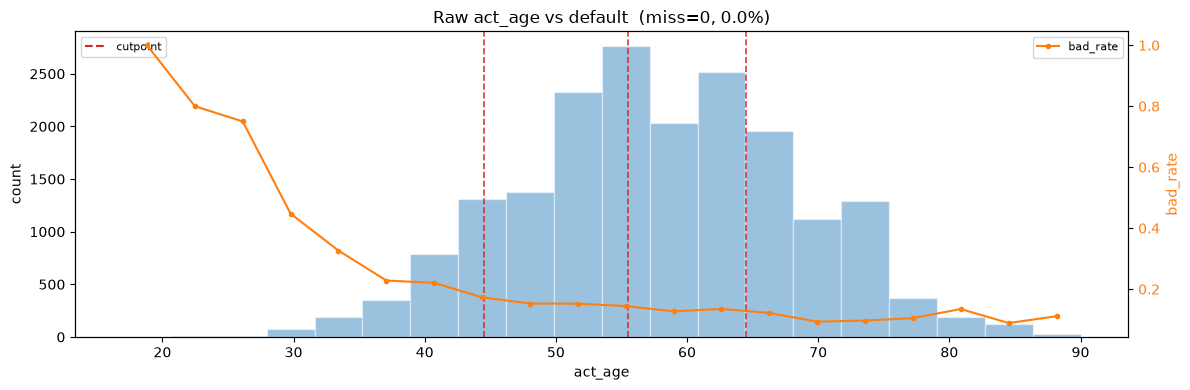

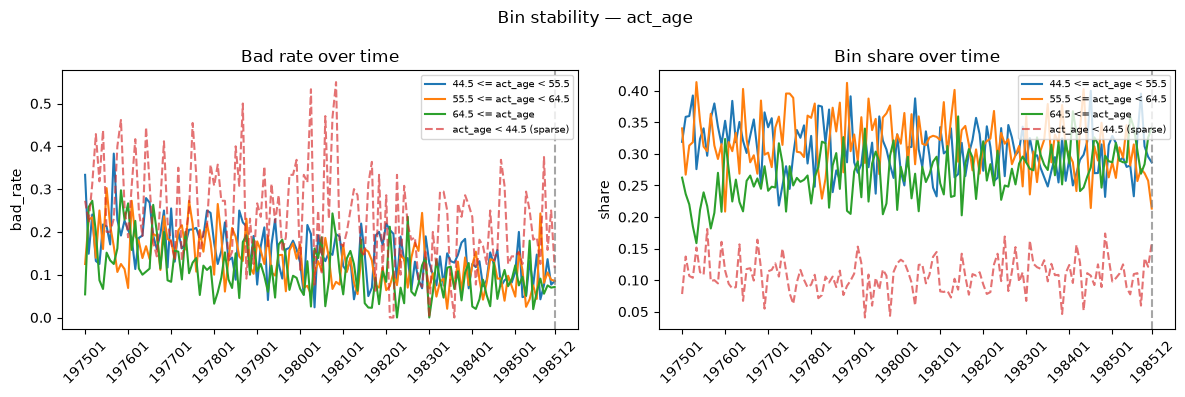

In [37]:
def plot_feature_vs_default(df, feature, target, binning_spec=None, n_bins=20, max_categories=30):
    """Raw feature volume + bad rate — for choosing cutpoints (not post-bin GRP)."""
    if df is None or feature not in df.columns or target not in df.columns:
        return

    col = df[feature]
    y = df[target]
    n_miss = int(col.isna().sum())
    miss_rate = n_miss / len(df) if len(df) else np.nan

    nominal_int_threshold = SCORECARD_PARAMS.get("binning", {}).get("nominal_int_threshold", 10)
    is_nominal = (
        pd.api.types.is_bool_dtype(col)
        or pd.api.types.is_object_dtype(col)
        or pd.api.types.is_string_dtype(col)
        or isinstance(col.dtype, pd.CategoricalDtype)
        or (
            pd.api.types.is_integer_dtype(col)
            and col.nunique(dropna=True) <= nominal_int_threshold
        )
        or (binning_spec is not None and binning_spec.get("type") == "nominal")
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    ax2 = ax.twinx()

    if not is_nominal and pd.api.types.is_numeric_dtype(col):
        mask = col.notna()
        x = col[mask].astype(float)
        yt = y[mask]
        if len(x) == 0:
            ax.set_title(f"{feature} — no non-null values")
            plt.show()
            return

        n_unique = int(x.nunique())
        bins = min(n_bins, max(n_unique, 1))
        counts, edges, _ = ax.hist(x, bins=bins, alpha=0.45, color="C0", edgecolor="white")
        ax.set_ylabel("count")

        bin_ids = pd.cut(x, bins=edges, include_lowest=True, duplicates="drop")
        br = yt.groupby(bin_ids, observed=False).mean()
        centers = np.array([(iv.left + iv.right) / 2 for iv in br.index])
        ax2.plot(centers, br.values, color="C1", marker="o", markersize=3, linewidth=1.5, label="bad_rate")
        ax2.set_ylabel("bad_rate", color="C1")
        ax2.tick_params(axis="y", labelcolor="C1")

        if binning_spec and binning_spec.get("type") == "numeric":
            for e in binning_spec.get("edges", []):
                if np.isfinite(e):
                    ax.axvline(float(e), color="C3", linestyle="--", linewidth=1.2, alpha=0.9)
            ax.plot([], [], color="C3", linestyle="--", label="cutpoint")

        ax.set_xlabel(feature)
        ax.set_title(f"Raw {feature} vs default  (miss={n_miss}, {miss_rate:.1%})")
        ax.legend(loc="upper left", fontsize=8)
        ax2.legend(loc="upper right", fontsize=8)
    else:
        s = col.astype(str).where(col.notna(), "<NA>")
        vc = s.value_counts()

        def _cat_sort_key(c):
            if c == "<NA>":
                return (2, 0)
            if c == "<rest>":
                return (3, 0)
            try:
                return (0, float(c))
            except (TypeError, ValueError):
                return (1, str(c))

        if len(vc) > max_categories:
            # keep rarest by count in <rest>, but display survivors by value
            rare = vc.nsmallest(len(vc) - (max_categories - 1)).index
            # OR: keep values outside a range / tail of sorted unique values
            keep = [c for c in vc.index if c not in rare]
            other_n = int(vc.loc[rare].sum())
            cats = sorted(keep, key=_cat_sort_key) + ["<rest>"]
            counts = [int(vc[c]) for c in cats[:-1]] + [other_n]
            br_vals = [float(y[s == c].mean()) for c in cats[:-1]]
            br_vals.append(float(y[s.isin(rare)].mean()))
        else:
            cats = sorted(vc.index, key=_cat_sort_key)
            counts = [int(vc[c]) for c in cats]
            br_vals = [float(y[s == c].mean()) for c in cats]

        xpos = np.arange(len(cats))
        ax.bar(xpos, counts, alpha=0.45, color="C0", edgecolor="white")
        ax.set_ylabel("count")
        ax.set_xticks(xpos)
        ax.set_xticklabels(cats, rotation=45, ha="right", fontsize=8)
        ax2.plot(xpos, br_vals, color="C1", marker="o", markersize=4, linewidth=1.5, label="bad_rate")
        ax2.set_ylabel("bad_rate", color="C1")
        ax2.tick_params(axis="y", labelcolor="C1")
        ax.set_xlabel(feature)
        ax.set_title(f"Raw {feature} vs default  (miss={n_miss}, {miss_rate:.1%})")
        ax2.legend(loc="upper right", fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_bin_stability(
    period_table, feature, train_end_period=None, min_n=None, tick_every=6, show_sparse_bins=True
):
    if period_table.empty:
        return
    min_n = min_n or SCORECARD_PARAMS["min_bin_n_period"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Bin stability — {feature}")

    for bin_label, sub in period_table.groupby("bin"):
        sub = sub.sort_values("period")
        is_sparse = sub["n"].min() < min_n
        if is_sparse and not show_sparse_bins:
            continue
        line_style = "--" if is_sparse else "-"
        alpha = 0.65 if is_sparse else 1.0
        label = f"{bin_label} (sparse)" if is_sparse else str(bin_label)
        axes[0].plot(sub["period"], sub["bad_rate"], label=label, linestyle=line_style, alpha=alpha)
        axes[1].plot(sub["period"], sub["share"], label=label, linestyle=line_style, alpha=alpha)

    if train_end_period:
        for ax in axes:
            ax.axvline(train_end_period, color="gray", linestyle="--", alpha=0.7)

    # keep only some periods on x-axis
    periods = sorted(period_table["period"].astype(str).unique())
    xticks = periods[::tick_every] if len(periods) > tick_every else periods
    if periods[-1] not in xticks:
        xticks.append(periods[-1])

    axes[0].set_title("Bad rate over time")
    axes[0].set_ylabel("bad_rate")
    axes[1].set_title("Bin share over time")
    axes[1].set_ylabel("share")

    for ax in axes:
        ax.set_xticks(xticks)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_bin_stability ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint plot_bin_stability ({_cp_plot_feat}):")
_cp_spec = _cp_maps.get(_cp_plot_feat) if "_cp_maps" in dir() else None
plot_feature_vs_default(
    _cp_train_binned, _cp_plot_feat, SCORECARD_PARAMS["target"], binning_spec=_cp_spec
)
plot_bin_stability(
    _cp_period_tables[_cp_plot_feat],
    _cp_plot_feat,
    train_end_period=SCORECARD_PARAMS["train_end_period"],
    tick_every=12,
)

checkpoint plot_br_gaps_over_time (act_age):


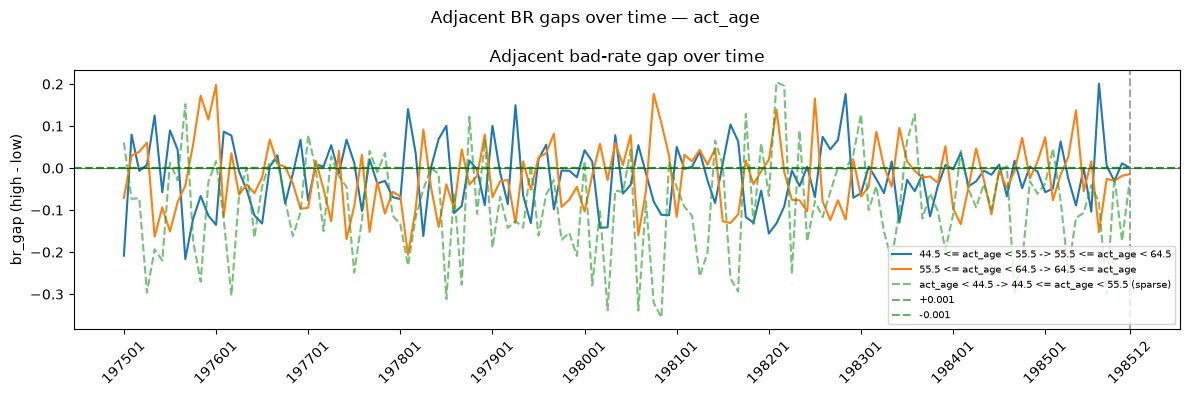

In [38]:
def plot_br_gaps_over_time(
    period_gaps, feature, train_end_period=None, min_n=None, tick_every=6, show_sparse_bins=True
):
    """Plot adjacent-bin bad-rate gaps over time for eyeballing."""
    if period_gaps is None or period_gaps.empty:
        print("No period gap data to plot")
        return

    min_n = min_n or SCORECARD_PARAMS.get("min_bin_n_period", 10)
    fig, ax = plt.subplots(figsize=(12, 4))
    fig.suptitle(f"Adjacent BR gaps over time — {feature}")

    for pair, sub in period_gaps.groupby("pair"):
        sub = sub.sort_values("period")
        ok = (sub["n_low"] >= min_n) & (sub["n_high"] >= min_n)
        if not show_sparse_bins:
            sub = sub.loc[ok]
        if sub.empty:
            continue
        is_sparse = not ok.all()
        line_style = "--" if is_sparse else "-"
        alpha = 0.65 if is_sparse else 1.0
        label = f"{pair} (sparse)" if is_sparse else str(pair)
        ax.plot(sub["period"], sub["br_gap"], label=label, linestyle=line_style, alpha=alpha)

    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    min_gap = SCORECARD_PARAMS.get("min_period_br_gap", 0.02)
    ax.axhline(min_gap, color="green", linestyle="--", alpha=0.6, label=f"+{min_gap}")
    ax.axhline(-min_gap, color="green", linestyle="--", alpha=0.6, label=f"-{min_gap}")

    if train_end_period:
        ax.axvline(train_end_period, color="gray", linestyle="--", alpha=0.7)

    periods = sorted(period_gaps["period"].astype(str).unique())
    xticks = periods[::tick_every] if len(periods) > tick_every else periods
    if periods and periods[-1] not in xticks:
        xticks.append(periods[-1])

    ax.set_title("Adjacent bad-rate gap over time")
    ax.set_ylabel("br_gap (high - low)")
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=7, loc="best")
    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_br_gaps_over_time ---
print(f"checkpoint plot_br_gaps_over_time ({_cp_feats[0]}):")
plot_br_gaps_over_time(
    _cp_variable_report[_cp_feats[0]]["period_gaps"],
    _cp_feats[0],
    train_end_period=SCORECARD_PARAMS["train_end_period"],
    tick_every=12,
)


checkpoint plot_woe_monotonic_check (act_age): increasing
WOE monotonicity (core bins): increasing
All bins (plot):


,bin,bad_rate_train,woe,woe_step
0,act_age < 44.5,0.236283,-0.453224,NaN
1,44.5 <= act_age < 55.5,0.153859,-0.345756,0.107468
2,55.5 <= act_age < 64.5,0.132619,0.184869,0.530624
3,64.5 <= act_age,0.107614,0.668914,0.484046


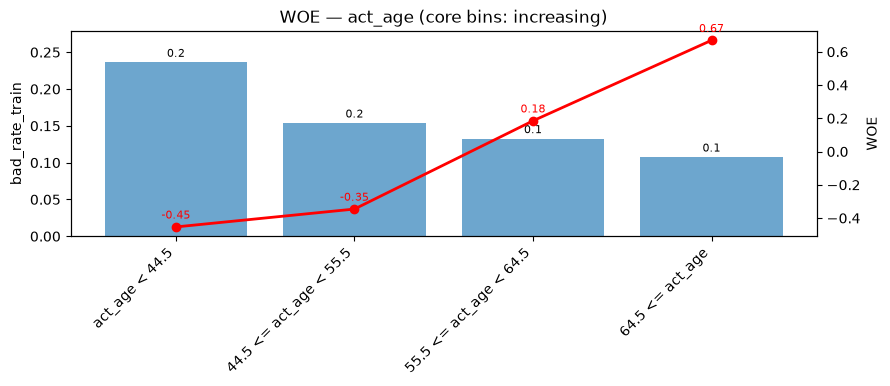

In [39]:
def plot_woe_monotonic_check(woe_display, feature, direction=None, woe_core=None):
    """Plot all bins; monotonicity label applies to core bins only."""
    if woe_display is None or woe_display.empty:
        print("No WOE data to plot")
        return

    direction = direction or "unknown"
    print(f"WOE monotonicity (core bins): {direction}")
    if woe_core is not None and len(woe_core):
        print("Core bins used for pass/fail:")
        display(woe_core)
    print("All bins (plot):")
    display(woe_display)

    fig, ax1 = plt.subplots(figsize=(9, 4))
    x = range(len(woe_display))
    bars = ax1.bar(x, woe_display["bad_rate_train"], alpha=0.65, label="bad_rate_train")
    _ymax = float(woe_display["bad_rate_train"].max())
    ax1.set_ylim(0, _ymax * 1.18)
    ax1.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(woe_display["bin"].astype(str), rotation=45, ha="right")
    ax1.set_ylabel("bad_rate_train")

    ax2 = ax1.twinx()
    ax2.plot(x, woe_display["woe"], color="red", marker="o", linewidth=2, label="WOE")
    for i, y in enumerate(woe_display["woe"]):
        ax2.annotate(
            f"{y:.2f}", (i, y), textcoords="offset points", xytext=(0, 6),
            ha="center", fontsize=8, color="red",
        )
    ax2.set_ylabel("WOE")
    plt.title(f"WOE — {feature} (core bins: {direction})")
    plt.tight_layout()
    fig.subplots_adjust(top=0.90)
    plt.show()

# --- checkpoint: plot_woe_monotonic_check ---
_cp_woe_ordered, _cp_woe_inc, _cp_woe_dec, _cp_woe_dir = check_woe_monotonicity(
    _cp_big_scorecard, _cp_feats[0], _cp_maps
)
print(f"checkpoint plot_woe_monotonic_check ({_cp_feats[0]}): {_cp_woe_dir}")
plot_woe_monotonic_check(_cp_woe_ordered, _cp_feats[0], _cp_woe_dir)


checkpoint display_variable_report (act_age):
### act_age
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
1,act_age,0.152906,0.127722,0.1647,0.16497,0.019779,0.083012,0.55,1,0,0,unknown,True,True,True,True,True,True,True,True,False,1 unstable bin(s): act_age < 44.5 (bad rate sw...,1 unstable bin(s): act_age < 44.5 (bad rate sw...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
0,44.5 <= act_age < 55.5,0.359169,0.023810,0.382979,30,5765,False,
1,55.5 <= act_age < 64.5,0.281917,0.020408,0.302326,29,5972,False,
2,64.5 <= act_age,0.297297,0.000000,0.297297,23,5083,False,
3,act_age < 44.5,0.550000,0.000000,0.550000,6,2023,True,bad rate swing too high; too few obs in a period


Static bins (Big_scorecard left block)


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,44.5 <= act_age < 55.5,44.5 <= act_age < 55.5,0.153859,0.305949,5765,887,4878,-0.345756
1,55.5 <= act_age < 64.5,55.5 <= act_age < 64.5,0.132619,0.316935,5972,792,5180,0.184869
2,64.5 <= act_age,64.5 <= act_age,0.107614,0.269755,5083,547,4536,0.668914
3,act_age < 44.5,act_age < 44.5,0.236283,0.107361,2023,478,1545,-0.453224


WOE monotonicity check
WOE monotonicity (core bins): increasing
Core bins used for pass/fail:


,bin,bad_rate_train,woe,woe_step
0,act_age < 44.5,0.236283,-0.453224,NaN
1,44.5 <= act_age < 55.5,0.153859,-0.345756,0.107468
2,55.5 <= act_age < 64.5,0.132619,0.184869,0.530624
3,64.5 <= act_age,0.107614,0.668914,0.484046


All bins (plot):


,bin,bad_rate_train,woe
0,act_age < 44.5,0.236283,-0.453224
1,44.5 <= act_age < 55.5,0.153859,-0.345756
2,55.5 <= act_age < 64.5,0.132619,0.184869
3,64.5 <= act_age,0.107614,0.668914


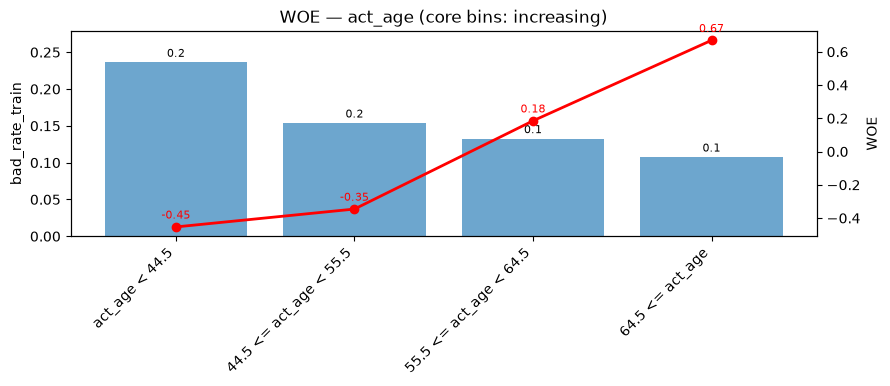

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_age,act_age < 44.5,44.5 <= act_age < 55.5,0.236283,0.153859,-0.082423,0.082423,0.179039,0.108504,-0.070535,0.070535,True,True
1,act_age,44.5 <= act_age < 55.5,55.5 <= act_age < 64.5,0.153859,0.132619,-0.021241,0.021241,0.108504,0.076757,-0.031748,0.031748,True,True
2,act_age,55.5 <= act_age < 64.5,64.5 <= act_age,0.132619,0.107614,-0.025005,0.025005,0.076757,0.097584,0.020827,0.020827,True,True


Adjacent bad-rate gaps over time (head)


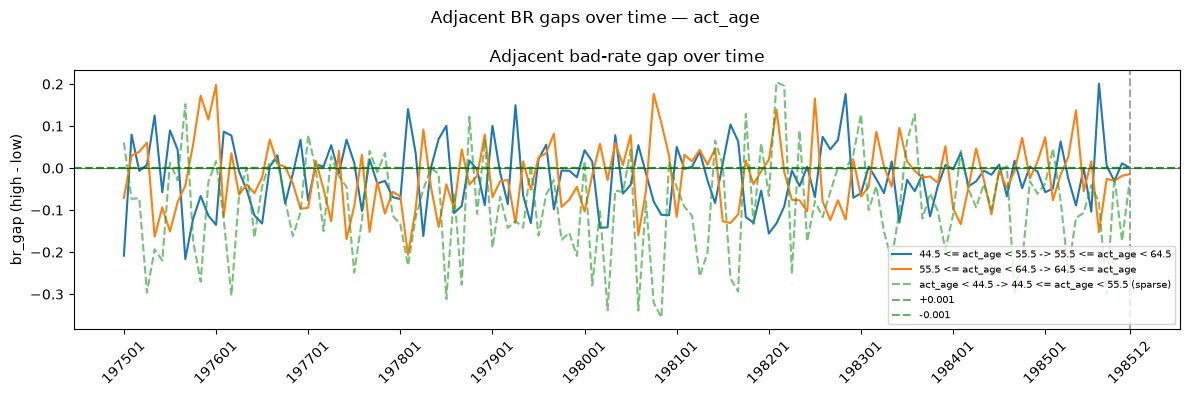

Raw feature vs default (for cutpoint choice)


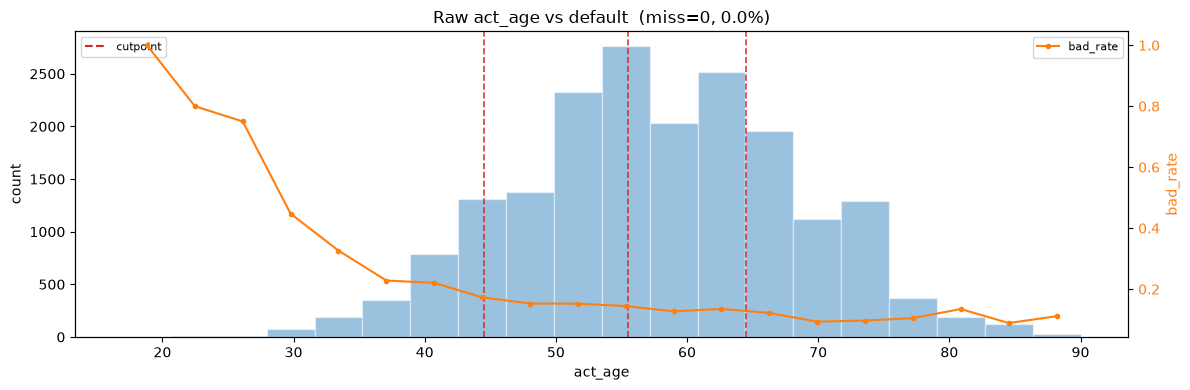

Period × bin (Variable_report right block)


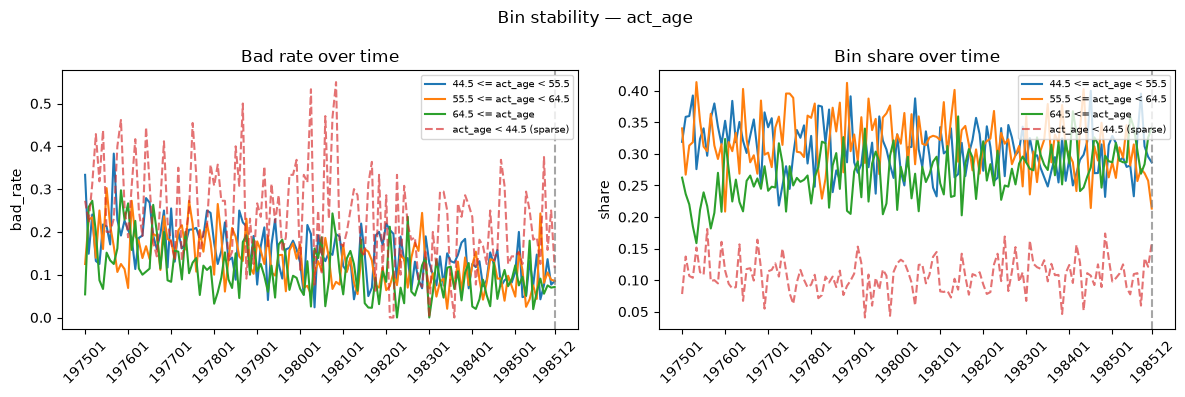

In [40]:
REVIEW_VAR_COLS = [
    "variable", "gini_train", "gini_valid", "delta_gini", "iv", "psi", "psi_tar",
    "max_bad_rate_swing", "n_unstable_bins",
    "n_fail_static_gaps", "n_fail_period_gaps", "woe_direction",
    "pass_gini_train", "pass_delta_gini", "pass_iv", "pass_psi", "pass_psi_tar",
    "pass_static_br_gap", "pass_period_br_gap", "pass_woe_monotonic",
    "safe_to_include", "safety_reason", "stability_reason",
]
REVIEW_BIN_COLS = [
    "bin", "bad_rate_swing", "min_bad_rate", "max_bad_rate",
    "min_n_period", "total_n", "flag_unstable", "flag_reason",
]
REVIEW_GAP_COLS = [
    "pair", "abs_br_gap_train", "abs_br_gap_valid", "n_fail_periods",
    "min_abs_br_gap", "flag_unstable", "flag_reason",
]


def display_variable_report(
    variable_report,
    feature,
    master_review_vars=None,
    master_review_bins=None,
    master_review_gaps=None,
    df=None,
    target=None,
    binning_maps=None,
):
    block = variable_report[feature]
    print(f"### {feature}")

    if master_review_vars is not None:
        print("Variable-level prescreen + stability")
        _var_row = master_review_vars.loc[master_review_vars["variable"] == feature, REVIEW_VAR_COLS]
        display(_var_row)

    if master_review_bins is not None:
        print("Bin-level bad-rate swing")
        _bin_rows = master_review_bins.loc[master_review_bins["variable"] == feature, REVIEW_BIN_COLS]
        display(_bin_rows)


    if (
        master_review_gaps is not None
        and "variable" in master_review_gaps.columns
    ):
        _gap_rows = master_review_gaps.loc[master_review_gaps["variable"] == feature]
        _gap_cols = [c for c in REVIEW_GAP_COLS if c in _gap_rows.columns]
        if len(_gap_rows) and _gap_cols:
            print("Adjacent-bin BR gap flags")
            display(_gap_rows[_gap_cols])

    print("Static bins (Big_scorecard left block)")
    display(block["static"])

    woe_ordered = block.get("woe_ordered", pd.DataFrame())
    woe_display = block.get("woe_display", woe_ordered)
    woe_mono = block.get("woe_monotonic", {})
    if woe_display is not None and len(woe_display):
        print("WOE monotonicity check")
        plot_woe_monotonic_check(
            woe_display,
            feature,
            direction=woe_mono.get("direction", "unknown"),
            woe_core=woe_ordered,
        )

    static_gaps = block.get("static_gaps", pd.DataFrame())
    if static_gaps is not None and len(static_gaps):
        print("Adjacent bad-rate gaps (static)")
        min_gap = SCORECARD_PARAMS.get("min_static_br_gap", 0.02)
        gaps_view = static_gaps.copy()
        gaps_view["pass_min_gap_train"] = gaps_view["abs_br_gap_train"] >= min_gap
        gaps_view["pass_min_gap_valid"] = gaps_view["abs_br_gap_valid"] >= min_gap
        display(gaps_view)

    period_gaps = block.get("period_gaps", pd.DataFrame())
    if period_gaps is not None and len(period_gaps):
        print("Adjacent bad-rate gaps over time (head)")
        plot_br_gaps_over_time(
            period_gaps,
            feature,
            train_end_period=SCORECARD_PARAMS["train_end_period"],
            tick_every=12,
        )

    _target = target or SCORECARD_PARAMS["target"]
    if df is not None and feature in df.columns:
        print("Raw feature vs default (for cutpoint choice)")
        _spec = binning_maps.get(feature) if binning_maps is not None else None
        plot_feature_vs_default(df, feature, _target, binning_spec=_spec)

    print("Period × bin (Variable_report right block)")
    plot_bin_stability(
        block["period"],
        feature,
        train_end_period=SCORECARD_PARAMS["train_end_period"],
        tick_every=12,
    )

# --- checkpoint: display_variable_report ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint display_variable_report ({_cp_plot_feat}):")
display_variable_report(
    _cp_variable_report, _cp_plot_feat,
    master_review_vars=_cp_master_vars,
    master_review_bins=_cp_master_bins,
    master_review_gaps=_cp_master_gaps if '_cp_master_gaps' in dir() else None,
    df=_cp_train_binned if '_cp_train_binned' in dir() else None,
    target=SCORECARD_PARAMS["target"],
    binning_maps=_cp_maps if '_cp_maps' in dir() else None,
)


In [41]:
# §2.1 — Overview (build bins/WOE + master review table)
binning_maps = fit_binning_maps(train_product, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
_no_split = [
	f for f, spec in binning_maps.items()
	if spec.get("type") == "numeric" and spec.get("no_numeric_split")
]
if _no_split:
	print(
		"WARN auto-binning: no numeric split for",
		_no_split,
		"— likely missing-only signal; tune in §2.3",
	)

artifacts = assign_review_artifacts(
	refresh_review_artifacts(binning_maps, train_product, valid_product, cand, SCORECARD_PARAMS)
)
train_binned = artifacts["train_binned"]
valid_binned = artifacts["valid_binned"]
train_woe = artifacts["train_woe"]
valid_woe = artifacts["valid_woe"]
woe_maps = artifacts["woe_maps"]
iv_table = artifacts["iv_table"]
big_scorecard = artifacts["big_scorecard"]
gini_vars = artifacts["gini_vars"]
review_vars = artifacts["review_vars"]
stability_flags = artifacts["stability_flags"]
static_br_gap_flags = artifacts["static_br_gap_flags"]
period_br_gap_flags = artifacts["period_br_gap_flags"]
woe_flags = artifacts["woe_flags"]
master_review_vars = artifacts["master_review_vars"]
master_review_bins = artifacts["master_review_bins"]
master_review_gaps = artifacts["master_review_gaps"]
vars_selected = artifacts["vars_selected"]

print(f"master_review_vars coverage: {len(master_review_vars)} / {len(cand['all'])} candidates")
# print_artifact_summary(artifacts, binning_maps=binning_maps)

manual_review_batch, needs_manual_review = build_manual_review_batch(master_review_vars, mode="unsafe")
print(f"needs_manual_review: {needs_manual_review}")
print(f"manual_review_batch (top unsafe): {len(manual_review_batch)}")
display(manual_review_batch.head())
print("Pick a feature in §2.2a, then run §2.2b for detail review.")


WARN auto-binning: no numeric split for ['act12_n_arrears', 'act12_n_good_days', 'act_cins_n_loans_act', 'act_cins_maxdue', 'act_cins_min_pninst', 'act_cins_min_lninst', 'act_cins_utl', 'act_cins_dueutl', 'act_cins_cc', 'act_cins_n_statB', 'act_ccss_n_loans_act', 'act_ccss_maxdue', 'act_ccss_min_lninst', 'act_ccss_utl', 'act_ccss_dueutl', 'act_ccss_seniority', 'act_ccss_min_seniority', 'act_ccss_n_loans_hist', 'act_ccss_n_statC', 'act_ccss_n_statB'] — likely missing-only signal; tune in §2.3
master_review_vars coverage: 56 / 56 candidates
needs_manual_review: True
manual_review_batch (top unsafe): 10


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order,n_metric_fails,manual_review_rank
0,act_ccss_n_loans_act,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,7,True,True,True,True,True,False,1 unstable bin(s): act_ccss_n_loans_act (all) ...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_n_loans_act (all) ...,0,0,True,True,single_bin,True,44,0,1
1,act_ccss_maxdue,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,8,True,True,True,True,True,False,1 unstable bin(s): act_ccss_maxdue (all) (bad ...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_maxdue (all) (bad ...,0,0,True,True,single_bin,True,45,0,2
2,act_ccss_min_lninst,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,25,True,True,True,True,True,False,1 unstable bin(s): act_ccss_min_lninst (all) (...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_min_lninst (all) (...,0,0,True,True,single_bin,True,46,0,3
3,act_ccss_utl,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,125,True,True,True,True,True,False,1 unstable bin(s): act_ccss_utl (all) (bad rat...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_utl (all) (bad rat...,0,0,True,True,single_bin,True,47,0,4
4,act_ccss_dueutl,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,68,True,True,True,True,True,False,1 unstable bin(s): act_ccss_dueutl (all) (bad ...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_dueutl (all) (bad ...,0,0,True,True,single_bin,True,48,0,5


Pick a feature in §2.2a, then run §2.2b for detail review.


### §2.1 notes — how to read review tables
- `safety_reason`: combined explanation (metric fails + stability issues).
- `stability_reason`: bin-level time stability summary (which bins failed and why).
- Metric examples: `delta_gini too high (0.24 vs threshold 0.2)`, `iv too low (0.01 vs threshold 0.02)`.
- Stability examples: `2 unstable bin(s) over time: act_age < 62 (bad rate swing too high ...); 62 <= act_age (too few obs in a period ...)`.
- In `master_review_bins`, use `flag_unstable` + `flag_reason` for bin-by-bin detail.
- BR gap / WOE examples: `1 static BR gap(s) too small; WOE not monotonic (not_monotonic)`.
- In `master_review_gaps`, use pair-level `flag_unstable` + `flag_reason` for adjacent-bin gap detail.


In [42]:
# §2.2a — Select variable for detail review
if manual_review_batch is None or len(manual_review_batch) == 0:
    feature_to_review = None
    print("manual_review_batch empty — skip detail review (Gate B bins already locked in §2.3a)")
else:
    feature_to_review = manual_review_batch["variable"].iloc[0]
    print(f"feature_to_review: {feature_to_review!r}")

    _edit = extract_bin_edit(binning_maps[feature_to_review])
    display_bin_edit_sheet(feature_to_review, _edit)
    # Do not overwrite locked edits for Gate B features
    if feature_to_review not in manual_bin_edits:
        manual_bin_edits[feature_to_review] = _edit
    print("Edit cutpoints/groups for this feature in §2.3a (manual_bin_edits).")


feature_to_review: 'act_ccss_n_loans_act'
'act_ccss_n_loans_act': {'type': 'numeric', 'cutpoints': [], 'missing_bin': True}  → 1 bin(s)
Edit cutpoints/groups for this feature in §2.3a (manual_bin_edits).


### act_ccss_n_loans_act
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
43,act_ccss_n_loans_act,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.666667,1,0,0,single_bin,True,True,True,True,True,True,True,True,False,1 unstable bin(s): act_ccss_n_loans_act (all) ...,1 unstable bin(s): act_ccss_n_loans_act (all) ...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
52,Missing,0.192993,0.051282,0.244275,107,17631,False,
53,act_ccss_n_loans_act (all),0.666667,0.000000,0.666667,3,1212,True,bad rate swing too high; too few obs in a period


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
94,Missing,Missing,0.137996,0.935679,17631,2433,15198,0.045532
95,act_ccss_n_loans_act (all),act_ccss_n_loans_act (all),0.223597,0.064321,1212,271,941,-0.541682


WOE monotonicity check
WOE monotonicity (core bins): single_bin
Core bins used for pass/fail:


,bin,bad_rate_train,woe
0,act_ccss_n_loans_act (all),0.223597,-0.541682


All bins (plot):


,bin,bad_rate_train,woe
0,act_ccss_n_loans_act (all),0.223597,-0.541682
1,Missing,0.137996,0.045532


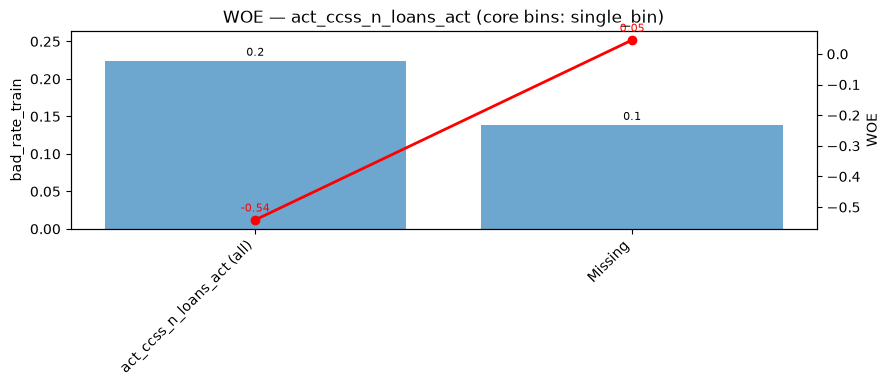

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_ccss_n_loans_act,act_ccss_n_loans_act (all),Missing,0.223597,0.137996,-0.085602,0.085602,0.208633,0.101705,-0.106928,0.106928,True,True


Adjacent bad-rate gaps over time (head)


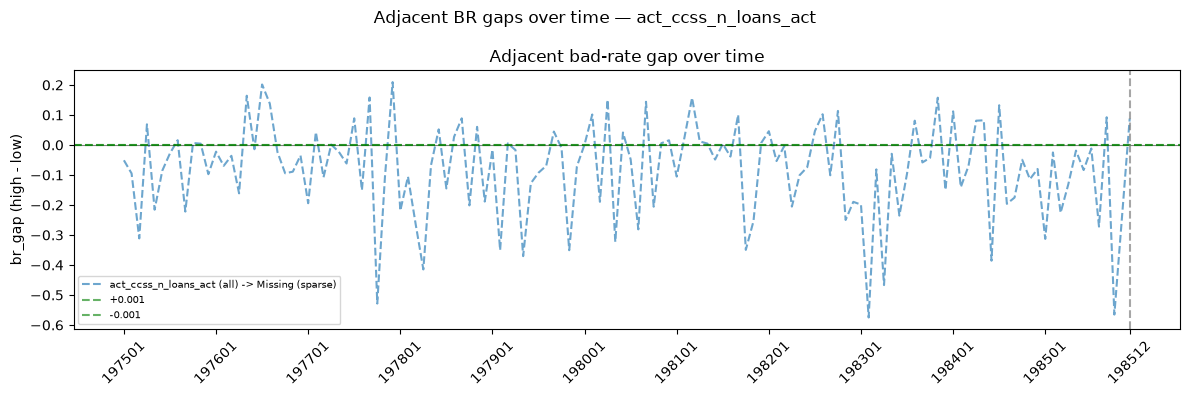

Raw feature vs default (for cutpoint choice)


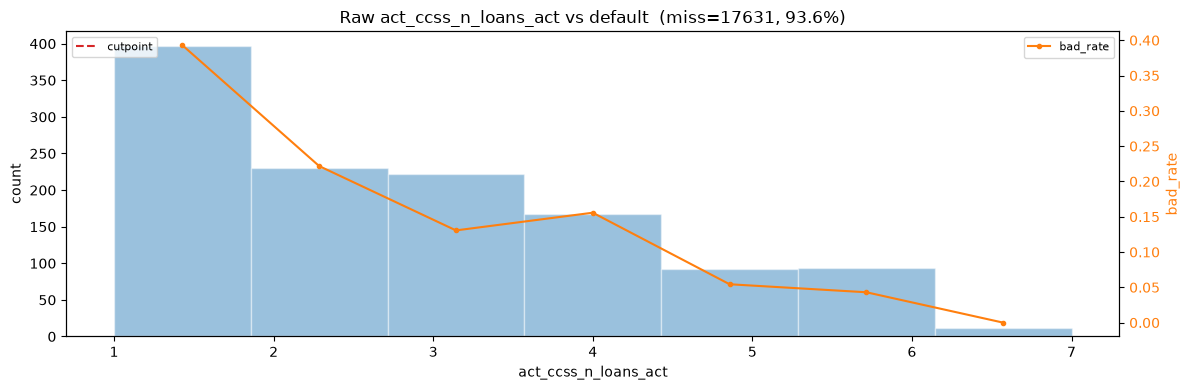

Period × bin (Variable_report right block)


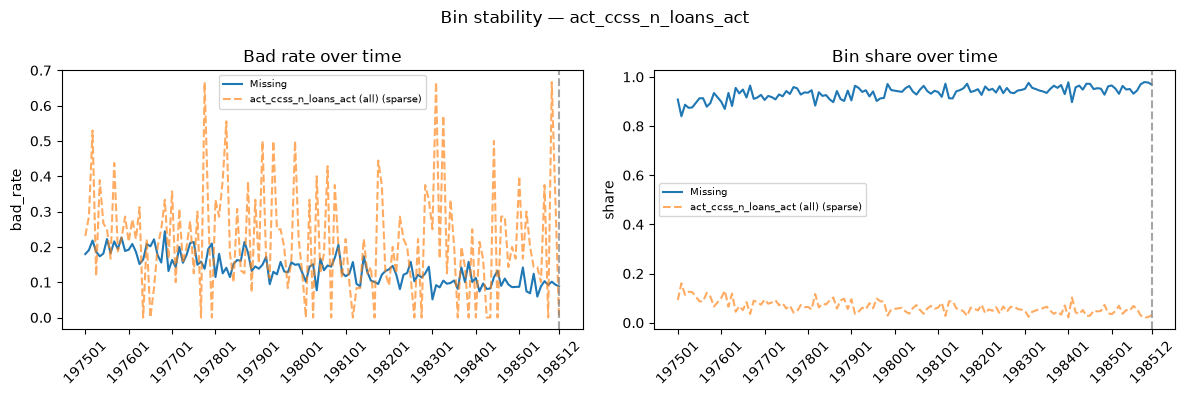

In [43]:
# §2.2b — Detail review for feature_to_review
if feature_to_review is None:
    print("skip §2.2b — no feature_to_review")
else:
    # §2.2b — Detail review for feature_to_review
    target = SCORECARD_PARAMS["target"]
    time_col = SCORECARD_PARAMS["time_col"]

    period_tables, _ = bin_stability_report(
        train_binned, [feature_to_review], target, time_col, SCORECARD_PARAMS
    )
    variable_report = build_variable_report(
        train_binned, big_scorecard, [feature_to_review],
        target, time_col, SCORECARD_PARAMS,
        period_tables=period_tables,
        binning_maps=binning_maps,
    )
    display_variable_report(
        variable_report, feature_to_review,
        master_review_vars=master_review_vars,
        master_review_bins=master_review_bins,
        master_review_gaps=master_review_gaps,
        df=train_binned,
        target=target,
        binning_maps=binning_maps,
    )


In [44]:
# §2.3a — Manual bin edits (compile to manual_binning_overrides)
import pprint

# Retuned for BR separation over time + WOE mono (Gate B still holds).
manual_bin_edits = {
	"act_age": {"type": "numeric", "cutpoints": [42.0, 62.0], "missing_bin": False},
	"act_cins_cc": {"type": "numeric", "cutpoints": [0.5], "missing_bin": True},
	"act_cins_n_statB": {"type": "numeric", "cutpoints": [], "missing_bin": True},  # Missing vs observed
	"app_number_of_children": {"type": "numeric", "cutpoints": [0.5], "missing_bin": False},
	"app_spendings": {"type": "numeric", "cutpoints": [250.0, 450.0], "missing_bin": False},
	"app_char_marital_status": {
		"type": "nominal",
		"groups": [["Widowed", "Maried"], ["Divorced"], ["Singiel"]],
		"other": [],
	},
	"app_char_job_code": {
		"type": "nominal",
		"groups": [["Permanent"], ["Retired"], ["Owner company"], ["Contract"]],
		"other": [],
	},
}

manual_binning_overrides = build_manual_binning_overrides(
	manual_bin_edits, binning_maps, SCORECARD_PARAMS
)
print(f"Compiled overrides: {sorted(manual_binning_overrides.keys())}")
for _feat, _spec in manual_binning_overrides.items():
	print(f"\n--- {_feat} ---")
	display_bin_edit_sheet(_feat, manual_bin_edits[_feat])
	pprint.pprint(_spec, width=120, sort_dicts=False)


Compiled overrides: ['act_age', 'act_cins_cc', 'act_cins_n_statB', 'app_char_job_code', 'app_char_marital_status', 'app_number_of_children', 'app_spendings']

--- act_age ---
'act_age': {'type': 'numeric', 'cutpoints': [42.0, 62.0], 'missing_bin': False}  → 3 bin(s)
{'type': 'numeric',
 'feature': 'act_age',
 'edges': [-inf, 42.0, 62.0, inf],
 'intervals': ['act_age < 42.0', '42.0 <= act_age < 62.0', '62.0 <= act_age'],
 'missing_label': 'Missing',
 'missing_bin': False,
 'no_numeric_split': False}

--- act_cins_cc ---
'act_cins_cc': {'type': 'numeric', 'cutpoints': [0.5], 'missing_bin': True}  → 2 bin(s)
{'type': 'numeric',
 'feature': 'act_cins_cc',
 'edges': [-inf, 0.5, inf],
 'intervals': ['act_cins_cc < 0.5', '0.5 <= act_cins_cc'],
 'missing_label': 'Missing',
 'missing_bin': True,
 'no_numeric_split': False}

--- act_cins_n_statB ---
'act_cins_n_statB': {'type': 'numeric', 'cutpoints': [], 'missing_bin': True}  → 1 bin(s)
{'type': 'numeric',
 'feature': 'act_cins_n_statB',
 'edge

In [45]:
# §2.3b — Apply bin overrides + refresh artifacts
manual_binning_overrides = build_manual_binning_overrides(
	manual_bin_edits, binning_maps, SCORECARD_PARAMS
)

for feat, edit in manual_bin_edits.items():
	assert feat in binning_maps, f"{feat} not found in binning_maps"
	spec = manual_binning_overrides[feat]
	assert spec["type"] == edit["type"], f"{feat}: edit/spec type mismatch"
	if spec["type"] == "numeric":
		assert len(spec["edges"]) >= 2, f"{feat}: edges must have at least 2 boundaries"
		assert len(spec["intervals"]) == len(spec["edges"]) - 1, (
			f"{feat}: intervals must be len(edges)-1"
		)
		assert isinstance(spec.get("missing_bin", False), (bool, np.bool_)), (
			f"{feat}: missing_bin must be boolean"
		)
	elif spec["type"] == "nominal":
		assert len(spec["intervals"]) == len(edit["groups"]), (
			f"{feat}: intervals must match number of groups"
		)
		assert set(spec["intervals"]) <= set(spec["category_map"].values()), (
			f"{feat}: every interval must appear in category_map values"
		)
		assert all(
			spec["category_map"].get(str(cat)) == spec["other_label"]
			for cat in edit.get("other", [])
		), f"{feat}: every edit['other'] category must map to other_label"
	else:
		raise ValueError(f"{feat}: unknown binning type {spec['type']!r}")
	binning_maps[feat] = spec

print("Applied manual overrides:", sorted(manual_binning_overrides.keys()))

artifacts = assign_review_artifacts(
	refresh_review_artifacts(binning_maps, train_product, valid_product, cand, SCORECARD_PARAMS)
)
train_binned = artifacts["train_binned"]
valid_binned = artifacts["valid_binned"]
train_woe = artifacts["train_woe"]
valid_woe = artifacts["valid_woe"]
woe_maps = artifacts["woe_maps"]
iv_table = artifacts["iv_table"]
big_scorecard = artifacts["big_scorecard"]
gini_vars = artifacts["gini_vars"]
review_vars = artifacts["review_vars"]
stability_flags = artifacts["stability_flags"]
static_br_gap_flags = artifacts["static_br_gap_flags"]
period_br_gap_flags = artifacts["period_br_gap_flags"]
woe_flags = artifacts["woe_flags"]
master_review_vars = artifacts["master_review_vars"]
master_review_bins = artifacts["master_review_bins"]
master_review_gaps = artifacts["master_review_gaps"]
vars_selected = artifacts["vars_selected"]
if "manual_variable_decisions" in dir():
    master_review_vars = apply_manual_variable_decisions(
        master_review_vars, manual_variable_decisions
    )
    vars_selected = select_vars_from_manual_review(master_review_vars)

for _feat in manual_binning_overrides:
	_row = master_review_vars.loc[master_review_vars["variable"] == _feat]
	display(_row)

manual_review_batch, needs_manual_review = build_manual_review_batch(master_review_vars, mode="unsafe")
print(f"needs_manual_review: {needs_manual_review}")
print(f"manual_review_batch (top unsafe): {len(manual_review_batch)}")
display(manual_review_batch.head())
print("Next: run §2.3b-post to re-inspect overridden feature(s), then §2.3c/§2.3d.")


Applied manual overrides: ['act_age', 'act_cins_cc', 'act_cins_n_statB', 'app_char_job_code', 'app_char_marital_status', 'app_number_of_children', 'app_spendings']


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order
40,act_age,0.125394,0.119292,0.048662,0.077494,0.009369,0.035568,0.0,71,True,True,True,True,True,False,1 unstable bin(s): act_age < 42.0 (bad rate sw...,review,,3,1,0.714286,59,1 unstable bin(s): act_age < 42.0 (bad rate sw...,0,0,True,True,increasing,True,41


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order
10,act_cins_cc,0.179812,0.219259,0.219379,0.420244,0.012189,0.007798,0.949318,924,True,False,True,True,True,False,delta_gini too high (0.219 vs threshold 0.2); ...,review,,3,2,1.0,105,2 unstable bin(s): 0.5 <= act_cins_cc (bad rat...,0,0,True,True,decreasing,True,11


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order
37,act_cins_n_statB,0.109899,0.081008,0.262884,0.117016,0.000182,0.002248,0.913655,18,True,False,True,True,True,False,delta_gini too high (0.263 vs threshold 0.2); ...,review,,2,1,0.857143,104,1 unstable bin(s): act_cins_n_statB (all) (bad...,0,0,True,True,single_bin,True,38


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order
55,app_number_of_children,0.194255,0.206134,0.061147,0.195935,0.000026,0.002969,0.0,4,True,True,True,True,True,True,,keep,,2,0,0.268997,69,,0,0,True,True,increasing,True,56


...

,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order
36,app_char_marital_status,0.179805,0.206582,0.148924,0.179825,0.00048,0.006373,0.0,4,True,True,True,True,True,False,1 unstable bin(s): Singiel (bad rate swing too...,review,,3,1,1.0,79,1 unstable bin(s): Singiel (bad rate swing too...,0,0,True,True,decreasing,True,37


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order
5,app_char_job_code,0.234986,0.287974,0.225493,0.334795,0.000882,0.01996,0.0,4,True,False,True,True,True,False,delta_gini too high (0.225 vs threshold 0.2); ...,review,,4,2,0.888889,53,2 unstable bin(s): Contract (bad rate swing to...,0,2,True,False,decreasing,True,6


needs_manual_review: True
manual_review_batch (top unsafe): 10


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order,n_metric_fails,manual_review_rank
0,act_ccss_maxdue,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,8,True,True,True,True,True,False,1 unstable bin(s): act_ccss_maxdue (all) (bad ...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_maxdue (all) (bad ...,0,0,True,True,single_bin,True,44,0,1
1,act_ccss_dueutl,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,68,True,True,True,True,True,False,1 unstable bin(s): act_ccss_dueutl (all) (bad ...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_dueutl (all) (bad ...,0,0,True,True,single_bin,True,45,0,2
2,act_ccss_utl,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,125,True,True,True,True,True,False,1 unstable bin(s): act_ccss_utl (all) (bad rat...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_utl (all) (bad rat...,0,0,True,True,single_bin,True,46,0,3
3,act_ccss_min_lninst,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,25,True,True,True,True,True,False,1 unstable bin(s): act_ccss_min_lninst (all) (...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_min_lninst (all) (...,0,0,True,True,single_bin,True,47,0,4
4,act_ccss_n_loans_act,0.041916,0.043255,0.031949,0.024614,0.012245,0.005767,0.935679,7,True,True,True,True,True,False,1 unstable bin(s): act_ccss_n_loans_act (all) ...,review,,2,1,0.666667,107,1 unstable bin(s): act_ccss_n_loans_act (all) ...,0,0,True,True,single_bin,True,48,0,5


Next: run §2.3b-post to re-inspect overridden feature(s), then §2.3c/§2.3d.


features_to_recheck: ['act_age', 'act_cins_cc', 'act_cins_n_statB', 'app_char_job_code', 'app_char_marital_status', 'app_number_of_children', 'app_spendings']
### act_age
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
40,act_age,0.125394,0.119292,0.048662,0.077494,0.009369,0.035568,0.714286,1,0,0,increasing,True,True,True,True,True,True,True,True,False,1 unstable bin(s): act_age < 42.0 (bad rate sw...,1 unstable bin(s): act_age < 42.0 (bad rate sw...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
22,42.0 <= act_age < 62.0,0.200855,0.055556,0.256410,59,10674,False,
23,62.0 <= act_age,0.304348,0.000000,0.304348,37,6948,False,
24,act_age < 42.0,0.714286,0.000000,0.714286,2,1221,True,bad rate swing too high; too few obs in a period


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,42.0 <= act_age < 62.0,42.0 <= act_age < 62.0,0.148304,0.566470,10674,1583,9091,-0.038543
1,62.0 <= act_age,62.0 <= act_age,0.113846,0.368731,6948,791,6157,0.265540
2,act_age < 42.0,act_age < 42.0,0.270270,0.064799,1221,330,891,-0.793255


WOE monotonicity check
WOE monotonicity (core bins): increasing
Core bins used for pass/fail:


,bin,bad_rate_train,woe,woe_step
0,act_age < 42.0,0.270270,-0.793255,NaN
1,42.0 <= act_age < 62.0,0.148304,-0.038543,0.754711
2,62.0 <= act_age,0.113846,0.265540,0.304084


All bins (plot):


,bin,bad_rate_train,woe
0,act_age < 42.0,0.270270,-0.793255
1,42.0 <= act_age < 62.0,0.148304,-0.038543
2,62.0 <= act_age,0.113846,0.265540


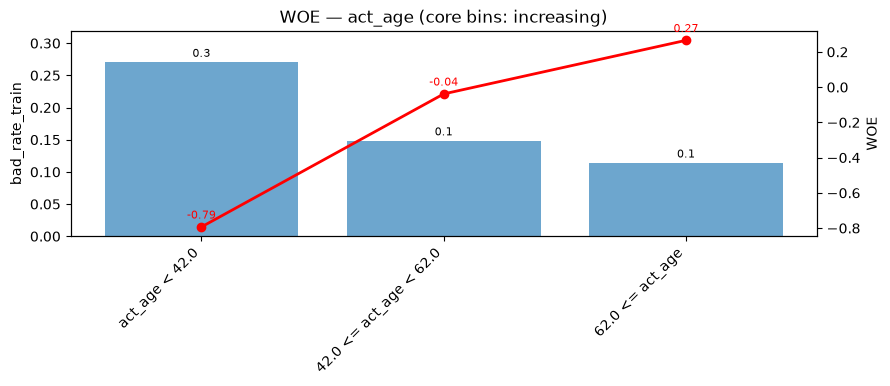

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_age,act_age < 42.0,42.0 <= act_age < 62.0,0.270270,0.148304,-0.121966,0.121966,0.217544,0.100549,-0.116994,0.116994,True,True
1,act_age,42.0 <= act_age < 62.0,62.0 <= act_age,0.148304,0.113846,-0.034459,0.034459,0.100549,0.090051,-0.010499,0.010499,True,True


Adjacent bad-rate gaps over time (head)


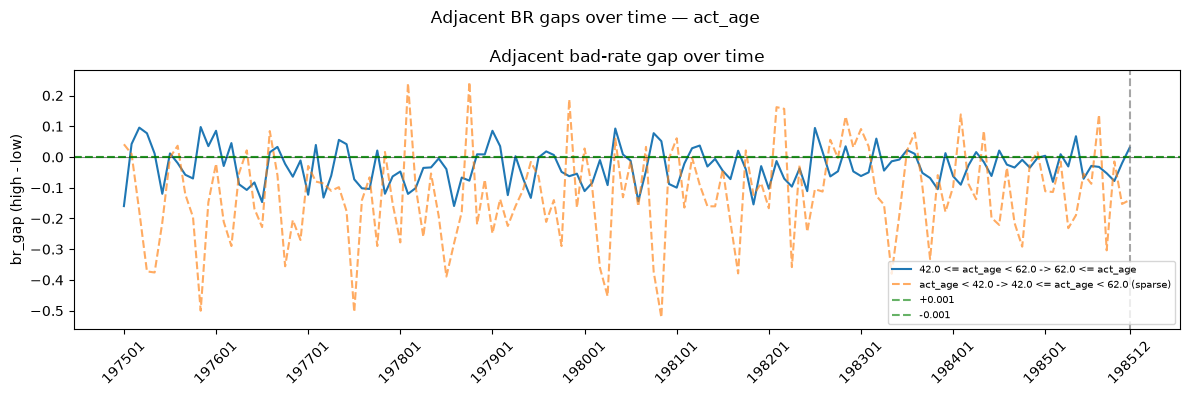

Raw feature vs default (for cutpoint choice)


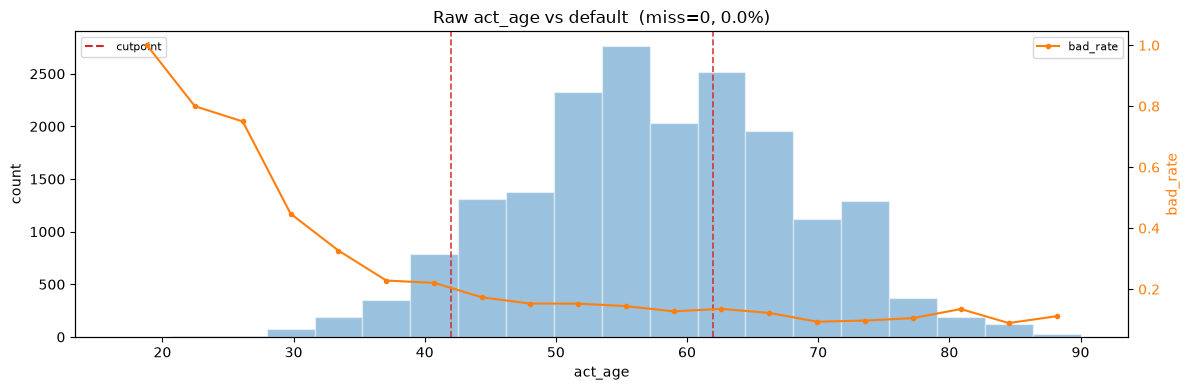

Period × bin (Variable_report right block)


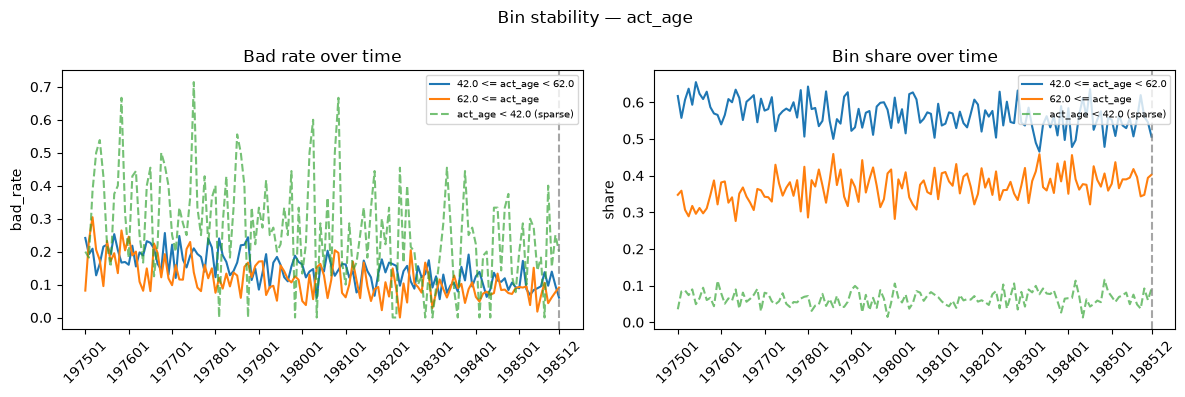

Post-fix review: 'act_age'  safe_to_include=False
### act_cins_cc
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
10,act_cins_cc,0.179812,0.219259,0.219379,0.420244,0.012189,0.007798,1.0,2,0,0,decreasing,True,False,True,True,True,True,True,True,False,delta_gini too high (0.219 vs threshold 0.2); ...,2 unstable bin(s): 0.5 <= act_cins_cc (bad rat...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
63,0.5 <= act_cins_cc,1.000000,0.000000,1.000000,1,567,True,bad rate swing too high; too few obs in a period
64,Missing,0.169064,0.050633,0.219697,105,17888,False,
65,act_cins_cc < 0.5,1.000000,0.000000,1.000000,1,388,True,bad rate swing too high; too few obs in a period


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
75,0.5 <= act_cins_cc,0.5 <= act_cins_cc,0.629630,0.030091,567,357,210,-2.317135
76,Missing,Missing,0.120304,0.949318,17888,2152,15736,0.203047
77,act_cins_cc < 0.5,act_cins_cc < 0.5,0.502577,0.020591,388,195,193,-1.796816


WOE monotonicity check
WOE monotonicity (core bins): decreasing
Core bins used for pass/fail:


,bin,bad_rate_train,woe,woe_step
0,act_cins_cc < 0.5,0.502577,-1.796816,NaN
1,0.5 <= act_cins_cc,0.629630,-2.317135,-0.520319


All bins (plot):


,bin,bad_rate_train,woe
0,act_cins_cc < 0.5,0.502577,-1.796816
1,0.5 <= act_cins_cc,0.629630,-2.317135
2,Missing,0.120304,0.203047


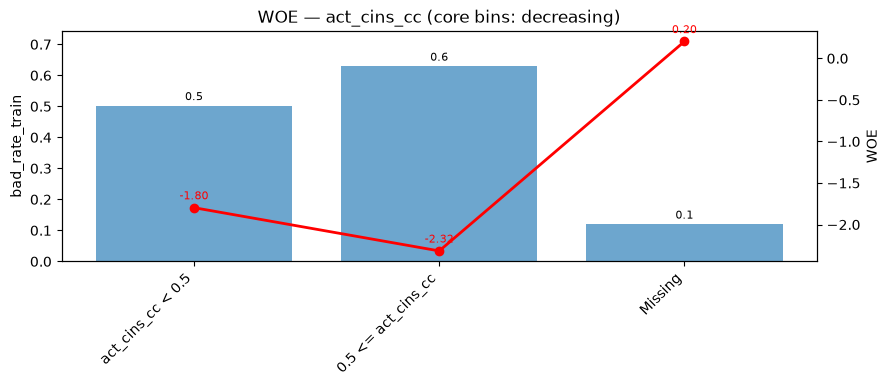

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_cins_cc,act_cins_cc < 0.5,0.5 <= act_cins_cc,0.502577,0.629630,0.127052,0.127052,0.774194,0.759494,-0.014700,0.014700,True,True
1,act_cins_cc,0.5 <= act_cins_cc,Missing,0.629630,0.120304,-0.509326,0.509326,0.759494,0.084520,-0.674974,0.674974,True,True


Adjacent bad-rate gaps over time (head)


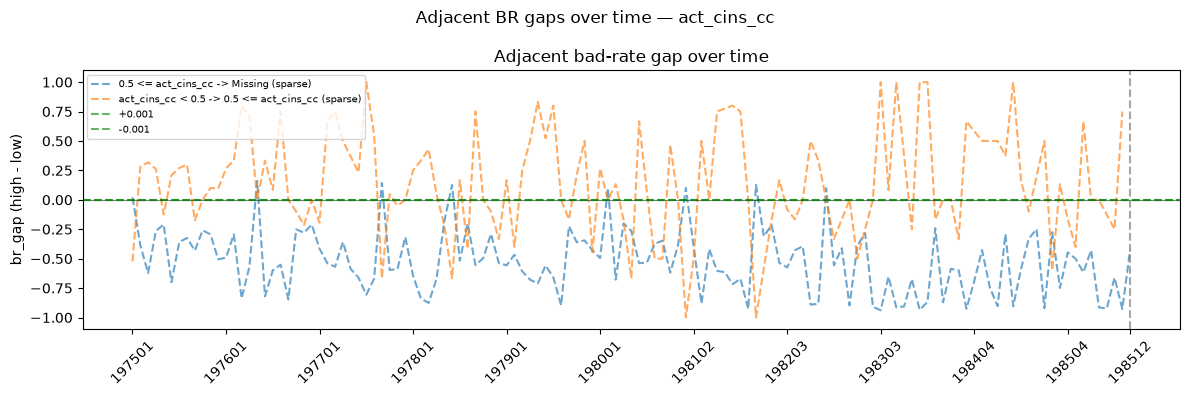

Raw feature vs default (for cutpoint choice)


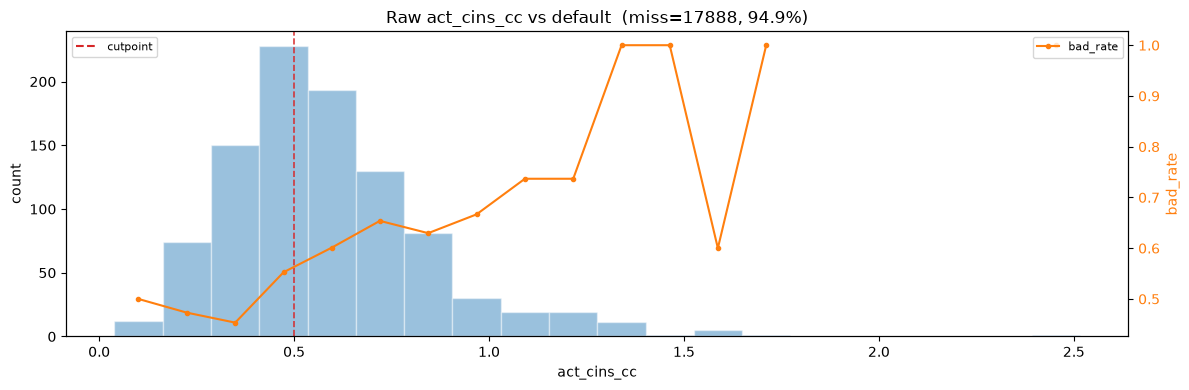

Period × bin (Variable_report right block)


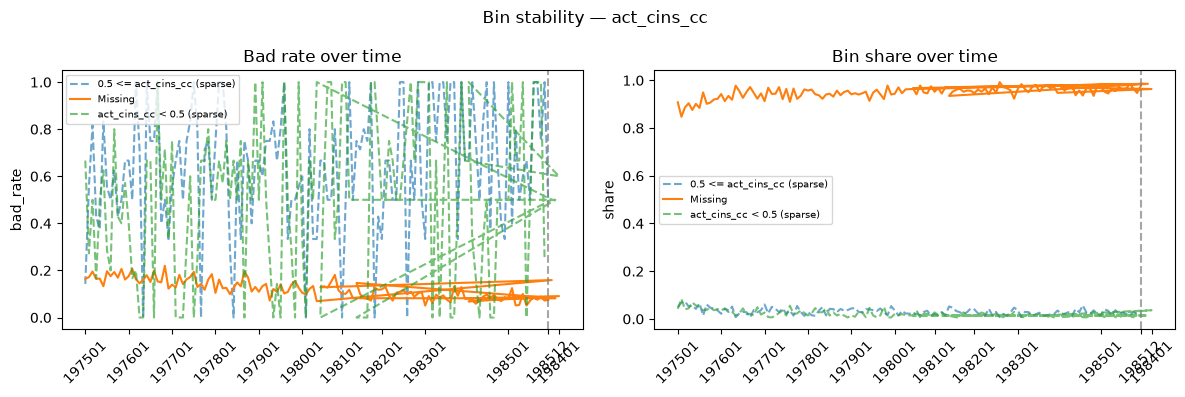

Post-fix review: 'act_cins_cc'  safe_to_include=False
### act_cins_n_statB
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
37,act_cins_n_statB,0.109899,0.081008,0.262884,0.117016,0.000182,0.002248,0.857143,1,0,0,single_bin,True,False,True,True,True,True,True,True,False,delta_gini too high (0.263 vs threshold 0.2); ...,1 unstable bin(s): act_cins_n_statB (all) (bad...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
84,Missing,0.176381,0.047619,0.224000,104,17216,False,
85,act_cins_n_statB (all),0.857143,0.000000,0.857143,4,1627,True,bad rate swing too high; too few obs in a period


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
90,Missing,Missing,0.128717,0.913655,17216,2216,15000,0.125840
91,act_cins_n_statB (all),act_cins_n_statB (all),0.299939,0.086345,1627,488,1139,-0.938916


WOE monotonicity check
WOE monotonicity (core bins): single_bin
Core bins used for pass/fail:


,bin,bad_rate_train,woe
0,act_cins_n_statB (all),0.299939,-0.938916


All bins (plot):


,bin,bad_rate_train,woe
0,act_cins_n_statB (all),0.299939,-0.938916
1,Missing,0.128717,0.125840


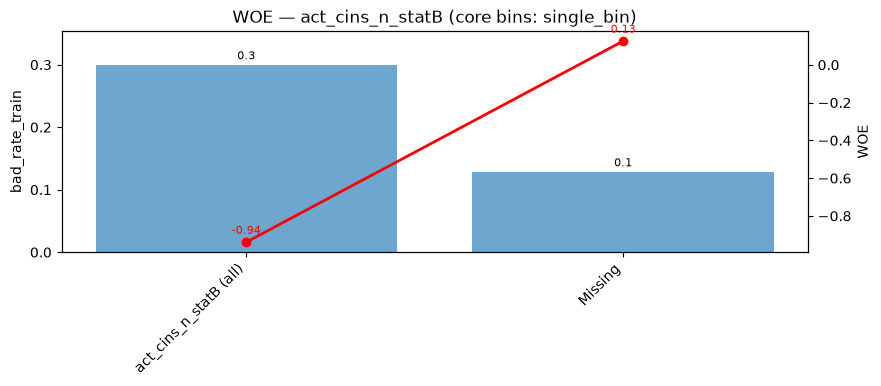

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_cins_n_statB,act_cins_n_statB (all),Missing,0.299939,0.128717,-0.171221,0.171221,0.191083,0.097538,-0.093545,0.093545,True,True


Adjacent bad-rate gaps over time (head)


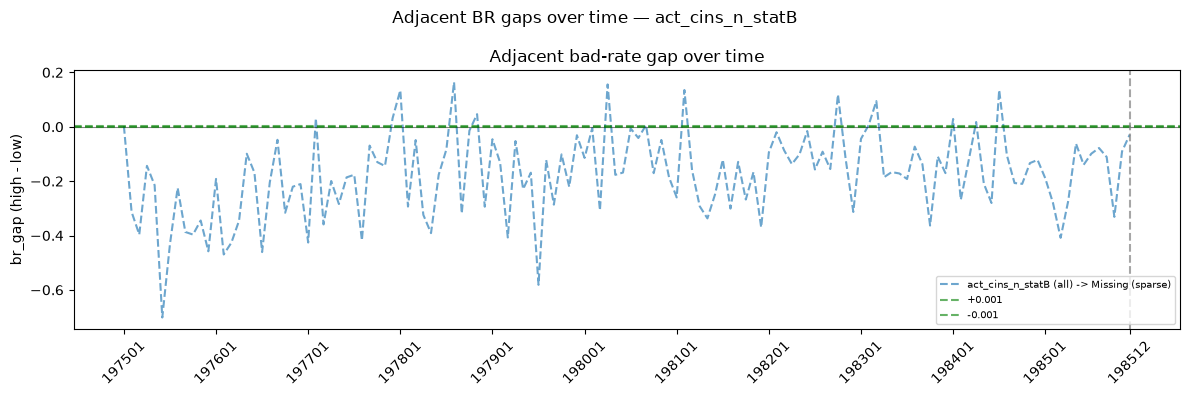

Raw feature vs default (for cutpoint choice)


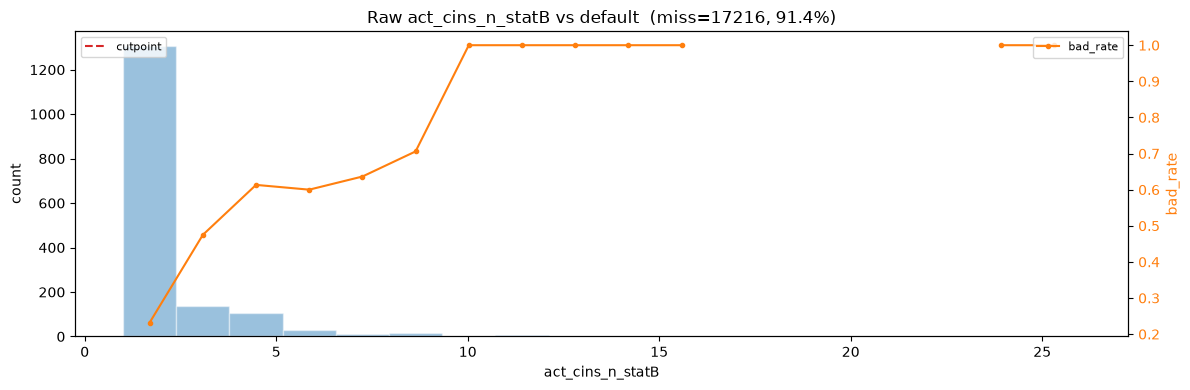

Period × bin (Variable_report right block)


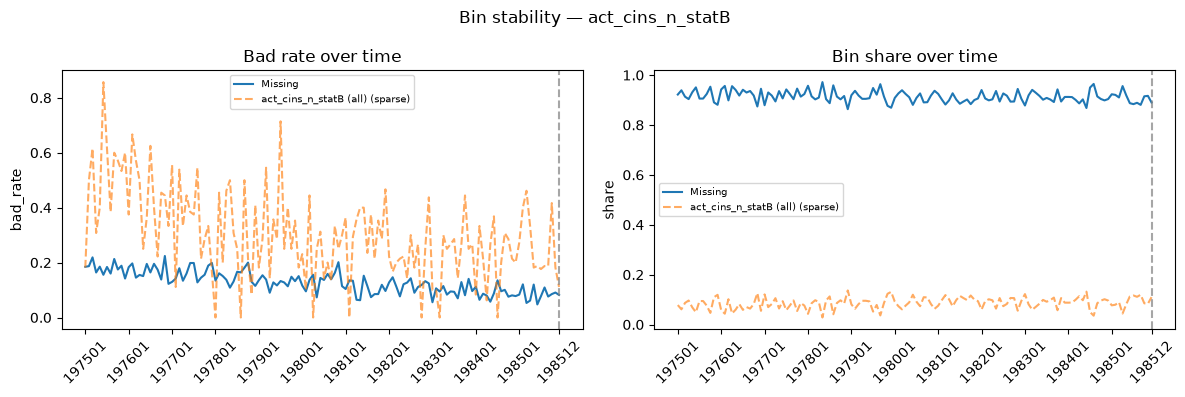

Post-fix review: 'act_cins_n_statB'  safe_to_include=False
### app_char_job_code
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
5,app_char_job_code,0.234986,0.287974,0.225493,0.334795,0.000882,0.01996,0.888889,2,0,2,decreasing,True,False,True,True,True,True,False,True,False,delta_gini too high (0.225 vs threshold 0.2); ...,2 unstable bin(s): Contract (bad rate swing to...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
113,Contract,0.888889,0.111111,1.000000,4,1271,True,bad rate swing too high; too few obs in a period
114,Owner company,0.550000,0.000000,0.550000,8,2091,True,bad rate swing too high; too few obs in a period
115,Permanent,0.300000,0.000000,0.300000,27,5922,False,
116,Retired,0.245076,0.012500,0.257576,53,9559,False,


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
124,Contract,Contract,0.452400,0.067452,1271,575,696,-1.595527
125,Owner company,Owner company,0.176471,0.110970,2091,369,1722,-0.246062
126,Permanent,Permanent,0.104694,0.314281,5922,620,5302,0.359613
127,Retired,Retired,0.119259,0.507297,9559,1140,8419,0.212956


WOE monotonicity check
WOE monotonicity (core bins): decreasing
Core bins used for pass/fail:


,bin,bad_rate_train,woe,woe_step
0,Permanent,0.104694,0.359613,NaN
1,Retired,0.119259,0.212956,-0.146657
2,Owner company,0.176471,-0.246062,-0.459018
3,Contract,0.452400,-1.595527,-1.349465


All bins (plot):


,bin,bad_rate_train,woe
0,Permanent,0.104694,0.359613
1,Retired,0.119259,0.212956
2,Owner company,0.176471,-0.246062
3,Contract,0.452400,-1.595527


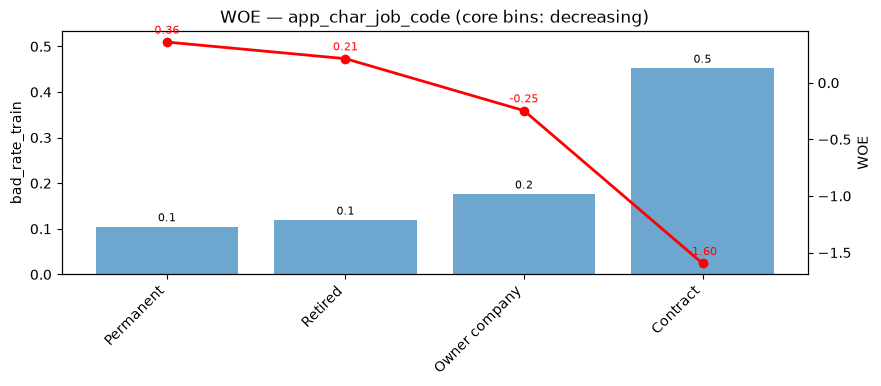

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,app_char_job_code,Permanent,Retired,0.104694,0.119259,0.014565,0.014565,0.069210,0.085359,0.016149,0.016149,True,True
1,app_char_job_code,Retired,Owner company,0.119259,0.176471,0.057211,0.057211,0.085359,0.111717,0.026358,0.026358,True,True
2,app_char_job_code,Owner company,Contract,0.176471,0.452400,0.275929,0.275929,0.111717,0.452055,0.340338,0.340338,True,True


Adjacent bad-rate gaps over time (head)


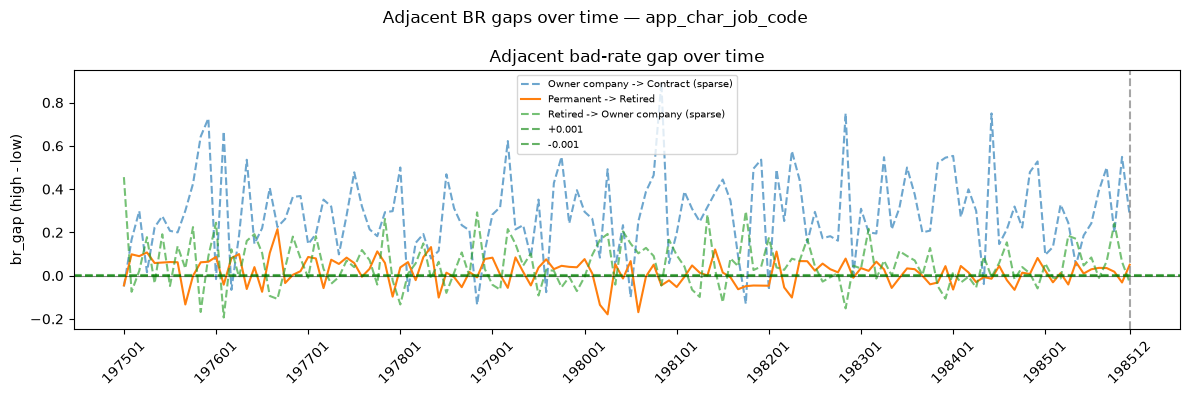

Raw feature vs default (for cutpoint choice)


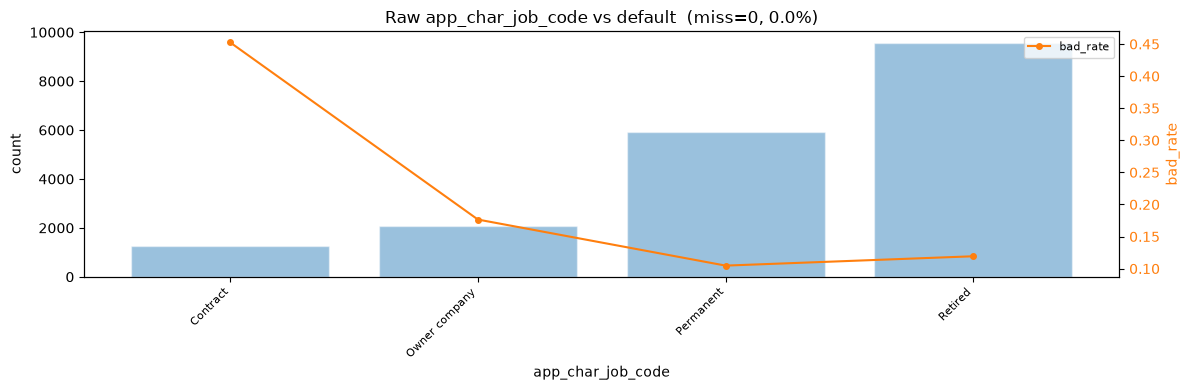

Period × bin (Variable_report right block)


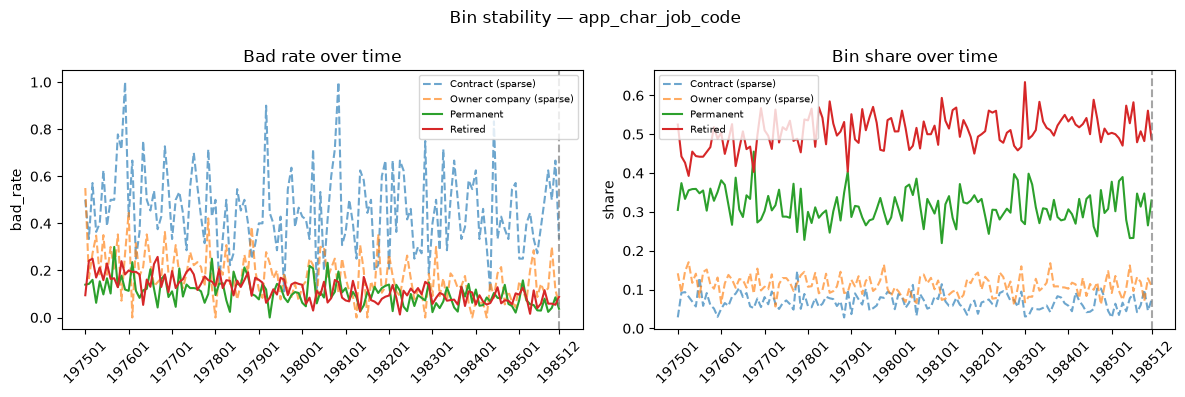

Post-fix review: 'app_char_job_code'  safe_to_include=False
### app_char_marital_status
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
36,app_char_marital_status,0.179805,0.206582,0.148924,0.179825,0.00048,0.006373,1.0,1,0,0,decreasing,True,True,True,True,True,True,True,True,False,1 unstable bin(s): Singiel (bad rate swing too...,1 unstable bin(s): Singiel (bad rate swing too...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
117,Divorced,0.335719,0.023256,0.358974,25,4864,False,
118,Singiel,1.000000,0.000000,1.000000,1,530,True,bad rate swing too high; too few obs in a period
119,"Widowed, Maried",0.210672,0.034783,0.245455,79,13449,False,


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
128,Divorced,Divorced,0.189556,0.258133,4864,922,3942,-0.333608
129,Singiel,Singiel,0.441509,0.028127,530,234,296,-1.551468
130,"Widowed, Maried","Widowed, Maried",0.115101,0.713740,13449,1548,11901,0.253152


WOE monotonicity check
WOE monotonicity (core bins): decreasing
Core bins used for pass/fail:


,bin,bad_rate_train,woe,woe_step
0,"Widowed, Maried",0.115101,0.253152,NaN
1,Divorced,0.189556,-0.333608,-0.58676
2,Singiel,0.441509,-1.551468,-1.21786


All bins (plot):


,bin,bad_rate_train,woe
0,"Widowed, Maried",0.115101,0.253152
1,Divorced,0.189556,-0.333608
2,Singiel,0.441509,-1.551468


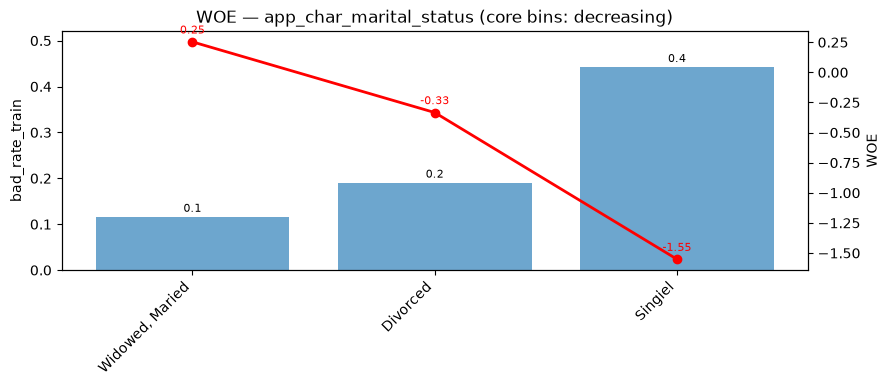

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,app_char_marital_status,"Widowed, Maried",Divorced,0.115101,0.189556,0.074454,0.074454,0.080763,0.144273,0.063510,0.063510,True,True
1,app_char_marital_status,Divorced,Singiel,0.189556,0.441509,0.251954,0.251954,0.144273,0.354545,0.210272,0.210272,True,True


Adjacent bad-rate gaps over time (head)


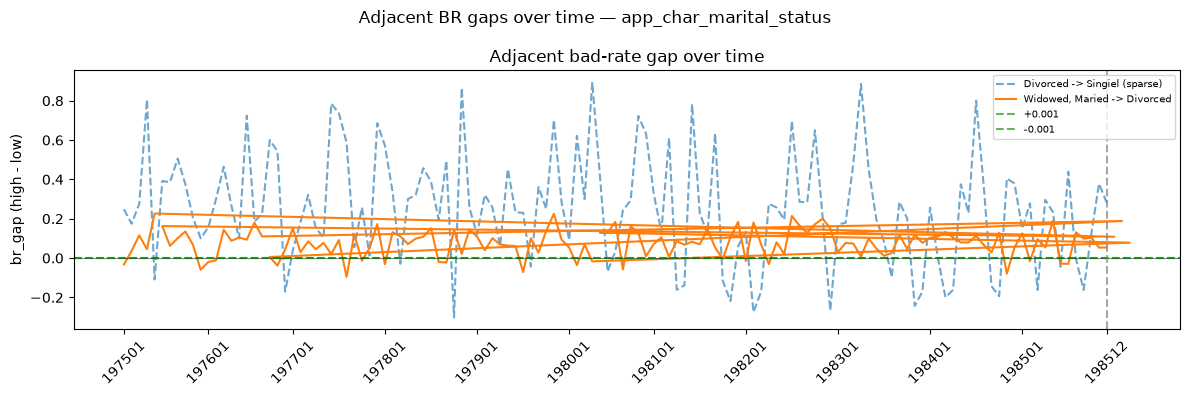

Raw feature vs default (for cutpoint choice)


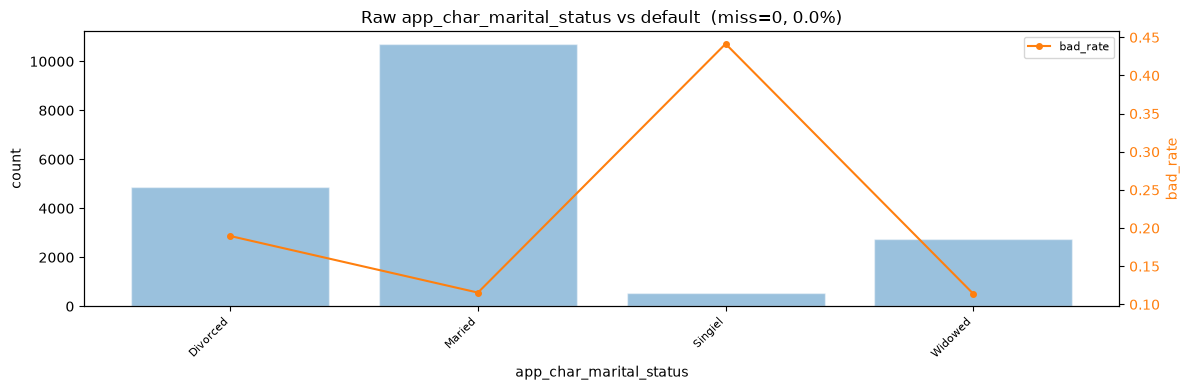

Period × bin (Variable_report right block)


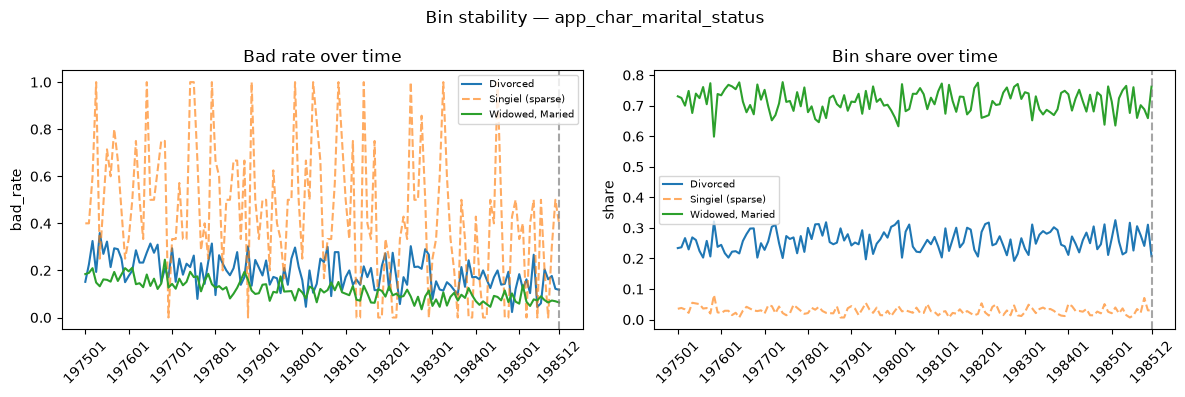

Post-fix review: 'app_char_marital_status'  safe_to_include=False
### app_number_of_children
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
55,app_number_of_children,0.194255,0.206134,0.061147,0.195935,0.000026,0.002969,0.268997,0,0,0,increasing,True,True,True,True,True,True,True,True,True,,


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
135,0.5 <= app_number_of_children,0.212766,0.000000,0.212766,34,6480,False,
136,app_number_of_children < 0.5,0.268997,0.071429,0.340426,69,12363,False,


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
22,0.5 <= app_number_of_children,0.5 <= app_number_of_children,0.074074,0.343894,6480,480,6000,0.739222
23,app_number_of_children < 0.5,app_number_of_children < 0.5,0.179892,0.656106,12363,2224,10139,-0.269425


WOE monotonicity check
WOE monotonicity (core bins): increasing
Core bins used for pass/fail:


,bin,bad_rate_train,woe,woe_step
0,app_number_of_children < 0.5,0.179892,-0.269425,NaN
1,0.5 <= app_number_of_children,0.074074,0.739222,1.008646


All bins (plot):


,bin,bad_rate_train,woe
0,app_number_of_children < 0.5,0.179892,-0.269425
1,0.5 <= app_number_of_children,0.074074,0.739222


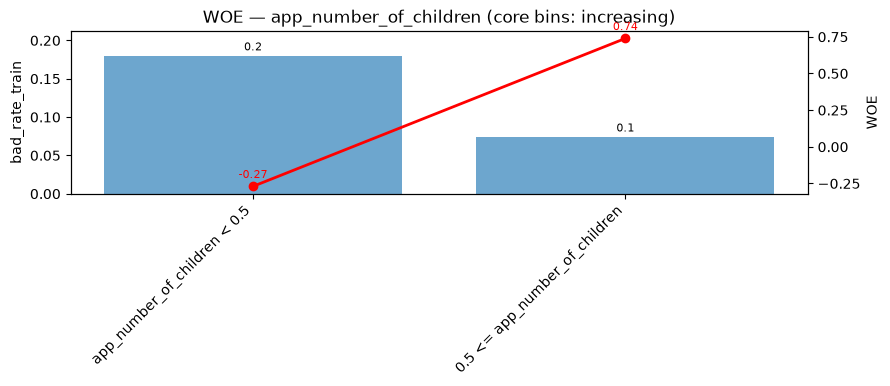

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,app_number_of_children,app_number_of_children < 0.5,0.5 <= app_number_of_children,0.179892,0.074074,-0.105818,0.105818,0.13563,0.04878,-0.08685,0.08685,True,True


Adjacent bad-rate gaps over time (head)


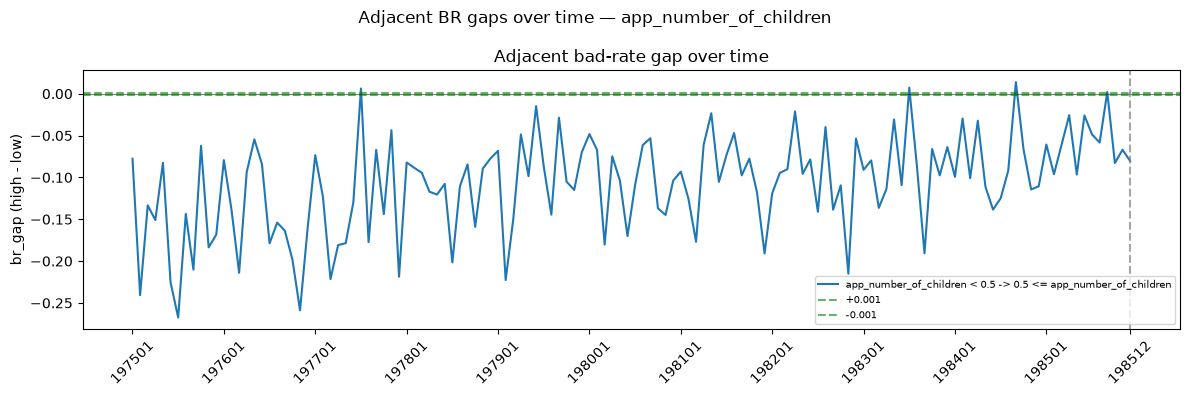

Raw feature vs default (for cutpoint choice)


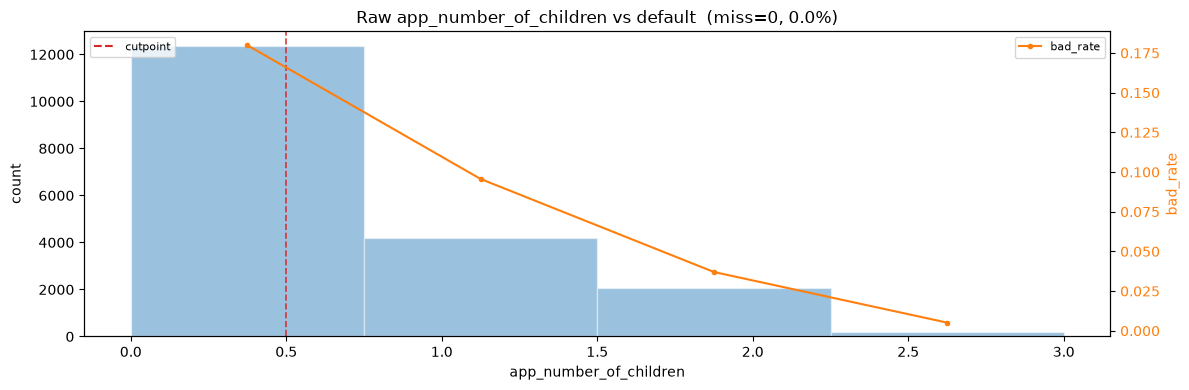

Period × bin (Variable_report right block)


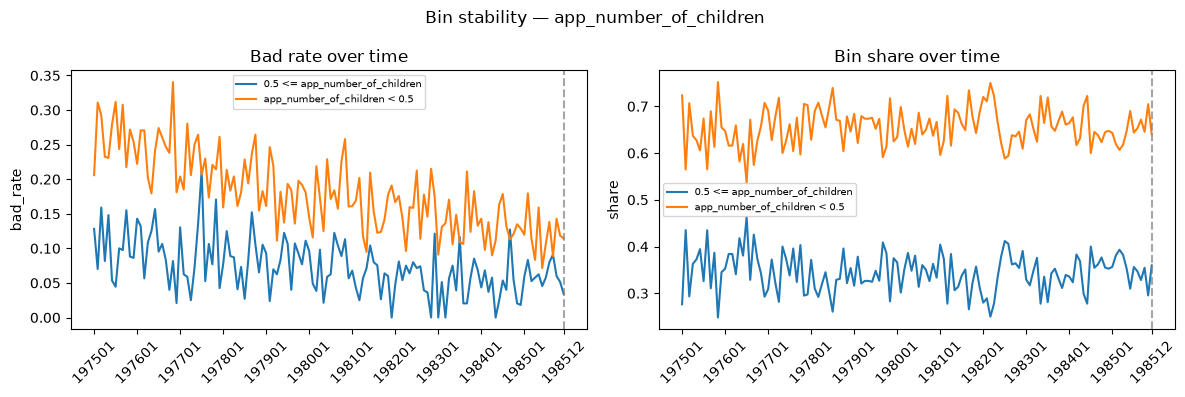

Post-fix review: 'app_number_of_children'  safe_to_include=True
### app_spendings
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
17,app_spendings,0.119154,0.17506,0.469193,0.067299,0.000042,0.009061,0.578947,1,0,1,increasing,True,False,True,True,True,True,False,True,False,delta_gini too high (0.469 vs threshold 0.2); ...,1 unstable bin(s): app_spendings < 250.0 (bad ...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
137,250.0 <= app_spendings < 450.0,0.282051,0.000000,0.282051,22,4506,False,
138,450.0 <= app_spendings,0.216505,0.027397,0.243902,52,10710,False,
139,app_spendings < 250.0,0.578947,0.000000,0.578947,15,3627,True,bad rate swing too high


Adjacent-bin BR gap flags


...

,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
24,250.0 <= app_spendings < 450.0,250.0 <= app_spendings < 450.0,0.134709,0.239134,4506,607,3899,0.073440
25,450.0 <= app_spendings,450.0 <= app_spendings,0.123996,0.568381,10710,1328,9382,0.168612
26,app_spendings < 250.0,app_spendings < 250.0,0.212021,0.192485,3627,769,2858,-0.473720


WOE monotonicity check
WOE monotonicity (core bins): increasing
Core bins used for pass/fail:


,bin,bad_rate_train,woe,woe_step
0,app_spendings < 250.0,0.212021,-0.473720,NaN
1,250.0 <= app_spendings < 450.0,0.134709,0.073440,0.547160
2,450.0 <= app_spendings,0.123996,0.168612,0.095172


All bins (plot):


,bin,bad_rate_train,woe
0,app_spendings < 250.0,0.212021,-0.473720
1,250.0 <= app_spendings < 450.0,0.134709,0.073440
2,450.0 <= app_spendings,0.123996,0.168612


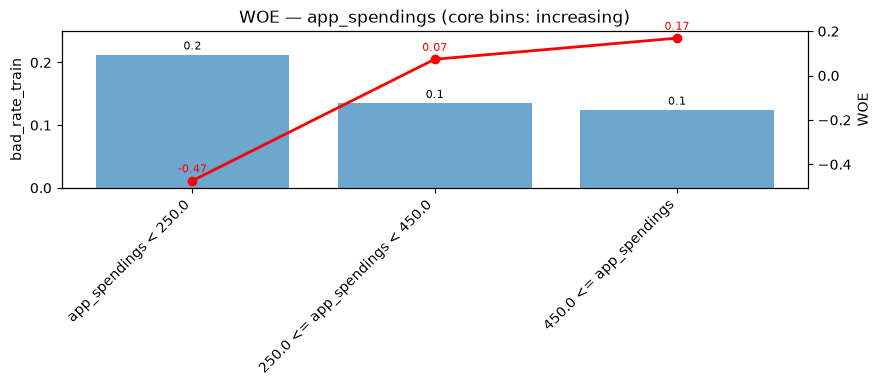

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,app_spendings,app_spendings < 250.0,250.0 <= app_spendings < 450.0,0.212021,0.134709,-0.077312,0.077312,0.175412,0.106667,-0.068746,0.068746,True,True
1,app_spendings,250.0 <= app_spendings < 450.0,450.0 <= app_spendings,0.134709,0.123996,-0.010713,0.010713,0.106667,0.082412,-0.024255,0.024255,True,True


Adjacent bad-rate gaps over time (head)


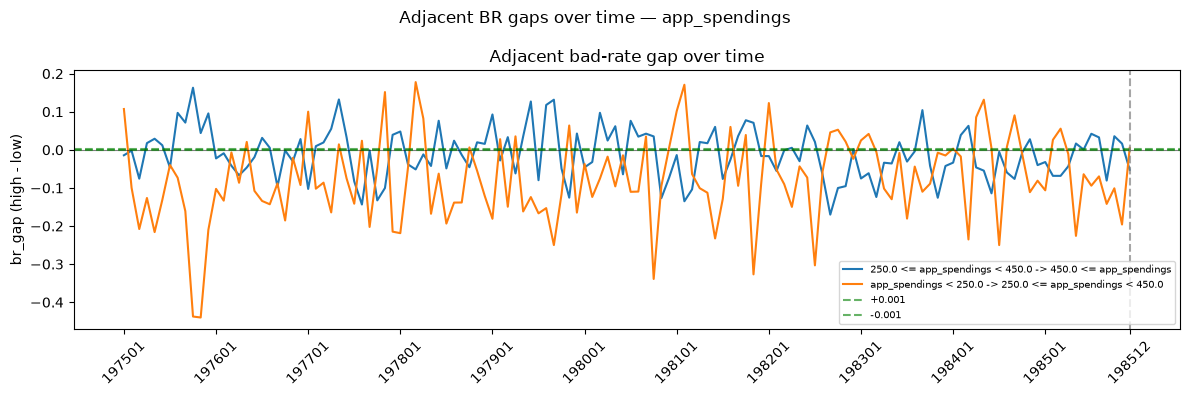

Raw feature vs default (for cutpoint choice)


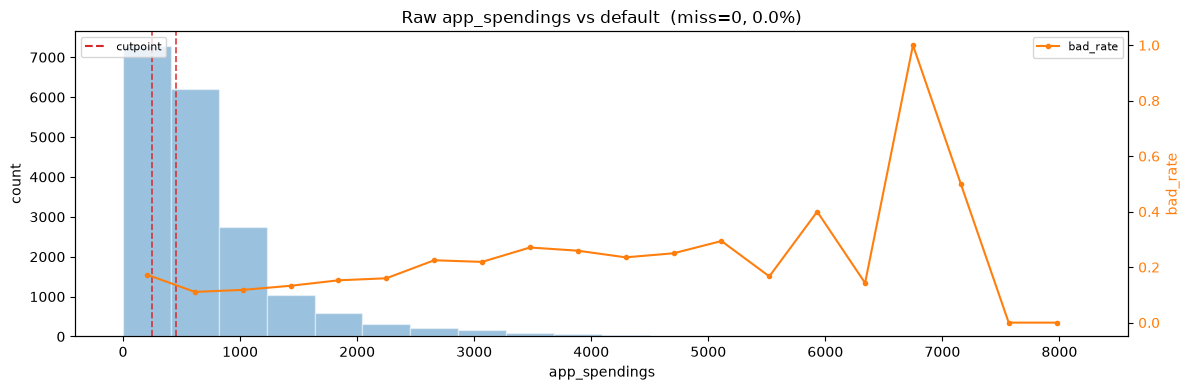

Period × bin (Variable_report right block)


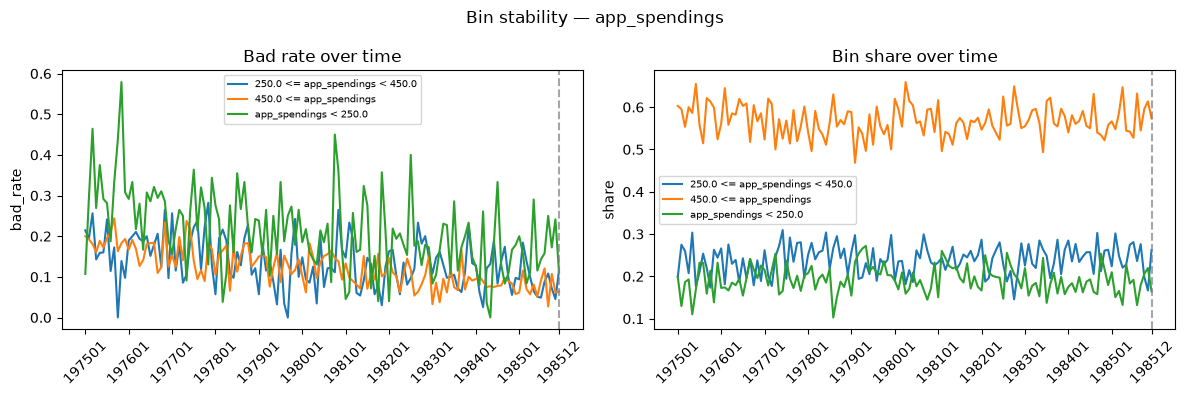

Post-fix review: 'app_spendings'  safe_to_include=False


In [46]:
# §2.3b-post — Re-inspect features after bin override
target = SCORECARD_PARAMS["target"]
time_col = SCORECARD_PARAMS["time_col"]
_features_to_recheck = (
    sorted(manual_binning_overrides.keys())
    if manual_binning_overrides
    else [feature_to_review]
)
print(f"features_to_recheck: {_features_to_recheck}")

for _feat in _features_to_recheck:
    period_tables, _ = bin_stability_report(
        train_binned, [_feat], target, time_col, SCORECARD_PARAMS
    )
    _report = build_variable_report(
        train_binned, big_scorecard, [_feat],
        target, time_col, SCORECARD_PARAMS,
        period_tables=period_tables,
        binning_maps=binning_maps,
    )
    display_variable_report(
        _report, _feat,
        master_review_vars=master_review_vars,
        master_review_bins=master_review_bins,
        master_review_gaps=master_review_gaps,
        df=train_binned,
        target=target,
        binning_maps=binning_maps,
    )
    _safe = master_review_vars.loc[master_review_vars["variable"] == _feat, "safe_to_include"]
    print(f"Post-fix review: {_feat!r}  safe_to_include={bool(_safe.iloc[0]) if len(_safe) else 'n/a'}")


### §2 loop notes

After §2.3b-post, continue §2.2 → §2.3 until the pending review queue is empty or decisions are recorded.
§2.3b refreshes bins/WOE/review tables — avoid re-running §2.1 after overrides unless a full reset is intended.
When finished, run §2.4 once as the hard gate before §3.


In [47]:
# §2.3c — Manual variable decisions (dict only; accumulate across loop)
manual_variable_decisions = {
	"act_age": {"decision": "keep", "note": "Gate B; WOE increasing; BR gaps > 0"},
	"act_cins_cc": {"decision": "keep", "note": "Gate B; WOE decreasing; Missing vs util bins"},
	"act_cins_n_statB": {"decision": "keep", "note": "Gate B; Missing vs any B-status (single observed bin)"},
	"app_char_job_code": {"decision": "keep", "note": "Gate B; WOE decreasing across job codes"},
	"app_char_marital_status": {"decision": "keep", "note": "Gate B; merged Widowed+Maried; WOE decreasing"},
	"app_number_of_children": {"decision": "keep", "note": "Gate B; 0 vs 1+; WOE increasing"},
	"app_spendings": {"decision": "keep", "note": "Gate B; WOE increasing"},
}

print(f"manual_variable_decisions keys: {sorted(manual_variable_decisions.keys())}")


manual_variable_decisions keys: ['act_age', 'act_cins_cc', 'act_cins_n_statB', 'app_char_job_code', 'app_char_marital_status', 'app_number_of_children', 'app_spendings']


In [48]:
# §2.3d — Apply manual variable decisions + rebuild review queue
for var, cfg in manual_variable_decisions.items():
    mask = master_review_vars["variable"].eq(var)
    if not mask.any():
        print(f"WARN: {var} not in master_review_vars")
        continue
    master_review_vars.loc[mask, "manual_decision"] = cfg["decision"]
    master_review_vars.loc[mask, "manual_note"] = cfg.get("note", "")

vars_selected = select_vars_from_manual_review(master_review_vars)
print(f"vars_selected (manual_decision='keep'): {len(vars_selected)}")
print(vars_selected)

manual_review_batch, needs_manual_review = build_manual_review_batch(master_review_vars, mode="pending")
print(f"needs_manual_review: {needs_manual_review}")
print(f"manual_review_batch (pending review): {len(manual_review_batch)}")
display(manual_review_batch[["variable", "manual_decision", "manual_note", "n_metric_fails"]].head(10))
if len(manual_review_batch):
    print(f"Suggested next feature_to_review: {manual_review_batch['variable'].iloc[0]!r}")
else:
    print("manual_review_batch empty — proceed to §2.4 final gate.")


vars_selected (manual_decision='keep'): 7
['app_char_job_code', 'act_cins_cc', 'app_spendings', 'app_char_marital_status', 'act_cins_n_statB', 'act_age', 'app_number_of_children']
needs_manual_review: True
manual_review_batch (pending review): 10


,variable,manual_decision,manual_note,n_metric_fails
0,act_ccss_maxdue,review,,0
1,act_ccss_dueutl,review,,0
2,act_ccss_utl,review,,0
3,act_ccss_min_lninst,review,,0
4,act_ccss_n_loans_act,review,,0
5,act9_n_good_days,review,,0
6,act_ccss_n_loan,review,,0
7,act_cins_n_loan,review,,0
8,act_cins_n_loans_hist,review,,0
9,act_ccss_cc,review,,0


Suggested next feature_to_review: 'act_ccss_maxdue'


In [49]:
# §2.4 — Final gate before §3 (run once after loop is complete)
vars_selected_pre_time = select_vars_from_manual_review(master_review_vars)
print(f"vars_selected_pre_time (manual_decision='keep'): {len(vars_selected_pre_time)} of {len(master_review_vars)}")

# optional time gate
def build_feature_gini_time_summary(df_woe, features, target, time_col, min_rows=50):
    rows = []
    for feat in features:
        woe_col = f"{feat}_WOE"
        if woe_col not in df_woe.columns:
            continue
        for period, sub in df_woe.groupby(time_col):
            n = len(sub)
            if n < min_rows or sub[target].nunique() < 2:
                continue
            gini_val = compute_gini(sub[target], sub[woe_col])
            rows.append({"variable": feat, "period": str(period), "n": n, "gini": gini_val})

    per_period = pd.DataFrame(rows)
    if per_period.empty:
        return per_period, pd.DataFrame(columns=["variable", "n_periods", "gini_first", "gini_last", "gini_delta", "gini_slope"])

    summary_rows = []
    for var, sub in per_period.sort_values("period").groupby("variable"):
        vals = sub["gini"].to_numpy(dtype=float)
        x = np.arange(len(vals), dtype=float)
        slope = float(np.polyfit(x, vals, 1)[0]) if len(vals) >= 2 else np.nan
        summary_rows.append({
            "variable": var,
            "n_periods": int(len(vals)),
            "gini_first": float(vals[0]),
            "gini_last": float(vals[-1]),
            "gini_delta": float(vals[-1] - vals[0]),
            "gini_slope": slope,
        })

    return per_period, pd.DataFrame(summary_rows).sort_values(["gini_slope", "gini_delta"], ascending=False)

time_gate_cfg = SCORECARD_PARAMS.get("time_gate", {})
time_gate_cfg.setdefault("min_periods", SCORECARD_PARAMS.get("min_periods_for_stability", 6))
time_gate_cfg.setdefault("gini_slope_min", 0.0)
time_gate_cfg.setdefault("gini_delta_min", -0.02)

gini_time_vars, gini_time_summary = build_feature_gini_time_summary(
    valid_woe, vars_selected_pre_time, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"]
)

if gini_time_summary.empty:
    stable_time_vars = set(vars_selected_pre_time)
else:
    stable_time_vars = set(gini_time_summary.loc[
        (gini_time_summary["n_periods"] >= time_gate_cfg["min_periods"])
        & (gini_time_summary["gini_slope"] >= time_gate_cfg["gini_slope_min"])
        & (gini_time_summary["gini_delta"] >= time_gate_cfg["gini_delta_min"]),
        "variable",
    ])

vars_selected = [v for v in vars_selected_pre_time if v in stable_time_vars]
vars_rejected_time = [v for v in vars_selected_pre_time if v not in stable_time_vars]

# Always keep locked Gate B MANUAL_OVERRIDE features in the modeling pool.
_override_raw = [
    f[: -len("_WOE")] if f.endswith("_WOE") else f for f in (MANUAL_OVERRIDE or [])
]
for _f in _override_raw:
    if _f not in vars_selected:
        vars_selected.append(_f)
        print(f"forced keep for MANUAL_OVERRIDE: {_f}")

thin_bins = big_scorecard.loc[
    (big_scorecard["variable"].isin(vars_selected))
    & (big_scorecard["share_train"] < SCORECARD_PARAMS["minimum_share_int"])
]
# Ignore thin bins that are intentional Missing-heavy Missing vs observed designs
_thin_ignore = {"act_cins_cc", "act_cins_n_statB"}
thin_bins = thin_bins.loc[~thin_bins["variable"].isin(_thin_ignore)]

print(f"vars_selected_after_time_gate: {len(vars_selected)}")
print(f"§2 final check — PRODUCT={PRODUCT} vars_selected={len(vars_selected)} thin_bins={len(thin_bins)}")

_min_keep = 7 if MANUAL_OVERRIDE else 10
_override_ok = all(_f in vars_selected for _f in _override_raw) if MANUAL_OVERRIDE else True
if len(vars_selected) >= _min_keep and thin_bins.empty and _override_ok:
    print("§2 PASS — proceed to §3")
    screen_report = (
        master_review_vars[["variable", "manual_decision", "manual_note", "safe_to_include"]]
        .rename(columns={"variable": "feature", "manual_decision": "status"})
        .copy()
    )
else:
    if len(thin_bins):
        display(thin_bins[["variable", "bin", "share_train"]].head(20))
    if vars_rejected_time:
        display(gini_time_summary[gini_time_summary["variable"].isin(vars_rejected_time)].sort_values("gini_slope"))
    print(
        f"§2 gate failed for PRODUCT={PRODUCT}: "
        f"vars_selected={len(vars_selected)} (need >= {_min_keep}), thin_bins={len(thin_bins)}. "
        "Continue the §2 review loop, then re-run §2.4."
    )


vars_selected_pre_time (manual_decision='keep'): 7 of 56
forced keep for MANUAL_OVERRIDE: act_cins_cc
forced keep for MANUAL_OVERRIDE: app_spendings
vars_selected_after_time_gate: 7
§2 final check — PRODUCT=ins vars_selected=7 thin_bins=3


,variable,bin,share_train
2,act_age,act_age < 42.0,0.064799
124,app_char_job_code,Contract,0.067452
129,app_char_marital_status,Singiel,0.028127


,variable,n_periods,gini_first,gini_last,gini_delta,gini_slope
1,act_cins_cc,24,0.179167,0.222222,0.043056,-0.001912
6,app_spendings,24,0.296759,0.230824,-0.065935,-0.000004


§2 gate failed for PRODUCT=ins: vars_selected=7 (need >= 7), thin_bins=3. Continue the §2 review loop, then re-run §2.4.


---


## §3 — Model fit

Requires §2.4 gate pass (`vars_selected`, `train_woe` / `valid_woe`, `binning_maps`, `big_scorecard`).

1. **§3.1** — Product WOE slice + candidate columns  
2. **§3.2** — RFE shortlist  
3. **§3.3** — Build `Model_list` (shortlist + `number_features` combos)  
4. **§3.4–3.5** — Diagnose near-misses; filter `subModel_list`  
5. **§3.5b** — BR stability **summary tables** for the first `subModel_list` row (detail plots stay in §2)  
6. **§3.6** — Pick winner (`WINNER_ROW` or `MANUAL_OVERRIDE`)  
7. **§3.7–3.8** — Final logit, effects, `model_package`


In [50]:
# §3.1 — Slice product data + candidate WOE columns
vars_for_modeling = vars_selected

target = SCORECARD_PARAMS["target"]
train_subset = slice_product(train_woe, PRODUCT)
valid_subset = slice_product(valid_woe, PRODUCT)
candidate_woe = [f"{f}_WOE" for f in vars_for_modeling if f"{f}_WOE" in train_woe.columns]
print(f"PRODUCT={PRODUCT}  train={len(train_subset)}  valid={len(valid_subset)}  candidate_woe={len(candidate_woe)}")


PRODUCT=ins  train=18843  valid=3482  candidate_woe=7


In [51]:
# §3.2 — RFE shortlist
number_vars = SCORECARD_PARAMS["selection"]["number_vars"]
rfe_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SCORECARD_PARAMS["selection"].get("rfe_random_state", RANDOM_SEED),
)
rfe = RFE(estimator=rfe_model, n_features_to_select=1, step=1)
rfe.fit(train_subset[candidate_woe], train_subset[target])
rfe_ranking = pd.Series(rfe.ranking_, index=candidate_woe)
shortlisted = rfe_ranking[rfe_ranking <= number_vars].sort_values().index.tolist()
display(rfe_ranking.sort_values().head(15))
print("shortlisted:", shortlisted)


act_age_WOE                    1
app_number_of_children_WOE     2
act_cins_cc_WOE                3
app_char_job_code_WOE          4
app_spendings_WOE              5
app_char_marital_status_WOE    6
act_cins_n_statB_WOE           7
dtype: int64

shortlisted: ['act_age_WOE', 'app_number_of_children_WOE', 'act_cins_cc_WOE', 'app_char_job_code_WOE', 'app_spendings_WOE', 'app_char_marital_status_WOE', 'act_cins_n_statB_WOE']


In [52]:
def _period_gini_stats(pred_valid, valid_df, target_col, time_col):
    """Gate B helpers: min monthly Gini + OLS slope over validation periods."""
    if time_col not in valid_df.columns:
        raise KeyError(
            f"valid_subset missing {time_col!r} — keep period through WOE encode / product slice"
        )
    tmp = valid_df[[target_col, time_col]].copy()
    tmp["_pred"] = np.asarray(pred_valid)
    rows = []
    for period, grp in tmp.groupby(time_col, sort=True):
        if grp[target_col].nunique() < 2 or len(grp) < 20:
            continue
        rows.append({"period": period, "gini": compute_gini(grp[target_col], grp["_pred"])})
    if not rows:
        return np.nan, np.nan, 0
    gini_time = pd.DataFrame(rows)
    vals = gini_time["gini"].to_numpy(dtype=float)
    slope = float(np.polyfit(np.arange(len(vals)), vals, 1)[0]) if len(vals) >= 2 else np.nan
    return float(vals.min()), slope, int(len(vals))


def _assess_combo(feature_set):
    feature_set = list(feature_set)
    missing = [f for f in feature_set if f not in train_subset.columns]
    if missing:
        raise KeyError(f"features not in train_subset: {missing}")
    x_train = sm.add_constant(train_subset[feature_set], has_constant="add")
    y_train = train_subset[target]
    # Newton often LinAlgError/singular on larger WOE combos — use lbfgs (Gate B search path)
    model = sm.Logit(y_train, x_train).fit(disp=0, maxiter=200, method="lbfgs")
    feature_cols = [c for c in model.params.index if c != "const"]
    x_valid = sm.add_constant(valid_subset[feature_cols], has_constant="add")
    pred_train = model.predict(x_train)
    pred_valid = model.predict(x_valid)
    gini_train = compute_gini(train_subset[target], pred_train)
    gini_valid = compute_gini(valid_subset[target], pred_valid)
    pvalues = model.pvalues.drop(labels=["const"], errors="ignore")
    max_pvalue = float(pvalues.max()) if len(pvalues) else 0.0
    vif_series = check_vif(train_subset[feature_cols])
    max_vif = float(vif_series.replace([np.inf, -np.inf], np.nan).max()) if len(vif_series) else 1.0
    if np.isnan(max_vif):
        max_vif = float("inf")
    betas = model.params.drop(labels=["const"], errors="ignore")
    nnegative_betas = int((betas < 0).sum())
    min_period_gini, period_gini_slope, n_periods = _period_gini_stats(
        pred_valid, valid_subset, target, SCORECARD_PARAMS["time_col"]
    )
    sel = SCORECARD_PARAMS["selection"]
    return {
        "Variables": ",".join(feature_cols),
        "n_features": len(feature_cols),
        "nnegative_betas": nnegative_betas,
        "max_pvalue": max_pvalue,
        "max_vif": max_vif,
        "gini_train": gini_train,
        "gini_valid": gini_valid,
        "ar_diff": abs(gini_train - gini_valid),
        "min_period_gini": min_period_gini,
        "period_gini_slope": period_gini_slope,
        "n_gini_periods": n_periods,
        "gate_b_pass": bool(
            gini_train >= sel["overall_gini_min"]
            and gini_valid >= sel["overall_gini_min"]
            and min_period_gini >= sel["min_period_gini"]
            and period_gini_slope > sel["period_gini_slope_min"]
            and max_vif < sel["vif_max"]
            and nnegative_betas == len(feature_cols)
            and max_pvalue <= sel["pvalue_max"]
        ),
    }

# --- checkpoint: _assess_combo ---
_probe = _assess_combo(shortlisted[: min(3, len(shortlisted))])
print("checkpoint _assess_combo:", {k: _probe[k] for k in _probe if k != "Variables"}, "vars=", _probe["Variables"])


checkpoint _assess_combo: {'n_features': 3, 'nnegative_betas': 3, 'max_pvalue': 1.6616494238569513e-118, 'max_vif': 1.0952711047116896, 'gini_train': 0.44535981053649687, 'gini_valid': 0.5412828622343402, 'ar_diff': 0.09592305169784332, 'min_period_gini': 0.3250000000000002, 'period_gini_slope': 0.003434989885096686, 'n_gini_periods': 24, 'gate_b_pass': False} vars= act_age_WOE,app_number_of_children_WOE,act_cins_cc_WOE


In [53]:
# §3.3 — Build Model_list
# Combo search is optional diagnostics; Gate B winner is MANUAL_OVERRIDE (always scored below).
number_features = SCORECARD_PARAMS["selection"]["number_features"]
_model_list_cols = [
    "Variables", "n_features", "nnegative_betas", "max_pvalue", "max_vif",
    "gini_train", "gini_valid", "ar_diff", "min_period_gini", "period_gini_slope",
    "n_gini_periods", "gate_b_pass",
]
rows = []
fit_failures = 0
_seen = set()

def _add_combo(feats, label=""):
    global fit_failures
    key = tuple(feats)
    if key in _seen:
        return
    _seen.add(key)
    try:
        rows.append(_assess_combo(feats))
    except Exception as exc:
        fit_failures += 1
        if fit_failures <= 5:
            print(f"fit failed ({label}):", repr(exc))

print(f"shortlisted={len(shortlisted)}  number_features={number_features}  MANUAL_OVERRIDE={len(MANUAL_OVERRIDE)}")

# 1) Always score the Gate B override first (this is the locked winner)
if MANUAL_OVERRIDE:
    missing = [f for f in MANUAL_OVERRIDE if f not in train_subset.columns]
    if missing:
        print("MANUAL_OVERRIDE missing from train_subset (need those WOE cols in §2 keeps):", missing)
    else:
        _add_combo(list(MANUAL_OVERRIDE), "MANUAL_OVERRIDE")
        print("scored MANUAL_OVERRIDE; gate_b_pass=", rows[-1]["gate_b_pass"] if rows else None)

# 2) Full RFE shortlist
_add_combo(list(shortlisted), "full_shortlist")

# 3) Combinations at number_features (can be slow: C(12,8)=495)
_max_combos = 300  # cap runtime; override already scored
if len(shortlisted) >= number_features:
    n_combo = 0
    for combo in combinations(shortlisted, number_features):
        _add_combo(list(combo), "combo")
        n_combo += 1
        if n_combo >= _max_combos:
            print(f"stopped after {_max_combos} combos (cap); MANUAL_OVERRIDE already included")
            break
else:
    print("skipped combinations — shortlisted < number_features")

Model_list = pd.DataFrame(rows) if rows else pd.DataFrame(columns=_model_list_cols)
for col in _model_list_cols:
    if col not in Model_list.columns:
        Model_list[col] = pd.Series(dtype="object" if col == "Variables" else "float64")
Model_list = Model_list.reindex(columns=_model_list_cols)
if not Model_list.empty and "gate_b_pass" in Model_list.columns:
    Model_list = Model_list.sort_values(
        ["gate_b_pass", "min_period_gini", "gini_valid"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

print("Model_list shape:", Model_list.shape, "  fit_failures:", fit_failures)
if Model_list.empty:
    print("Model_list EMPTY — if MANUAL_OVERRIDE is set, skip to §3.6 anyway")
else:
    display(Model_list.head(10))


shortlisted=7  number_features=7  MANUAL_OVERRIDE=7
scored MANUAL_OVERRIDE; gate_b_pass= True
Model_list shape: (2, 12)   fit_failures: 0


,Variables,n_features,nnegative_betas,max_pvalue,max_vif,gini_train,gini_valid,ar_diff,min_period_gini,period_gini_slope,n_gini_periods,gate_b_pass
0,"act_age_WOE,act_cins_cc_WOE,act_cins_n_statB_W...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True
1,"act_age_WOE,app_number_of_children_WOE,act_cin...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True


In [54]:
# §3.4 — Diagnose near-misses before filtering
sel = SCORECARD_PARAMS["selection"]
print("Model_list rows:", len(Model_list), "columns:", list(Model_list.columns))

if Model_list.empty or "gini_valid" not in Model_list.columns:
    msg = (
        "Model_list is empty — combo fits failed or never ran. "
        f"(shortlisted={len(shortlisted)}, number_features={sel.get('number_features')}, "
        f"MANUAL_OVERRIDE={len(MANUAL_OVERRIDE)}). "
    )
    if MANUAL_OVERRIDE:
        print("WARNING:", msg, "MANUAL_OVERRIDE is set → continue to §3.5/§3.6 (winner path).")
    else:
        raise RuntimeError(msg + "Fix §3.2–§3.3 or set MANUAL_OVERRIDE.")
else:
    _diag_cols = [
        "nnegative_betas", "max_pvalue", "max_vif", "gini_valid",
        "min_period_gini", "period_gini_slope",
    ]
    _diag_cols = [c for c in _diag_cols if c in Model_list.columns]
    display(Model_list[_diag_cols].describe())

    _all_neg = Model_list["nnegative_betas"] == Model_list["n_features"]
    print("pass all-neg betas:", int(_all_neg.sum()))
    print("pass pvalue:", int((Model_list["max_pvalue"] <= sel["pvalue_max"]).sum()))
    print("pass vif (<):", int((Model_list["max_vif"] < sel["vif_max"]).sum()))
    print(
        "pass sign+p+vif:",
        int(
            (
                _all_neg
                & (Model_list["max_pvalue"] <= sel["pvalue_max"])
                & (Model_list["max_vif"] < sel["vif_max"])
            ).sum()
        ),
    )
    if "gate_b_pass" in Model_list.columns:
        print("pass Gate B:", int(Model_list["gate_b_pass"].fillna(False).sum()))

    near = Model_list.sort_values(
        ["min_period_gini", "gini_valid"]
        if "min_period_gini" in Model_list.columns
        else ["gini_valid"],
        ascending=False,
    )
    display(near.head(5))


Model_list rows: 2 columns: ['Variables', 'n_features', 'nnegative_betas', 'max_pvalue', 'max_vif', 'gini_train', 'gini_valid', 'ar_diff', 'min_period_gini', 'period_gini_slope', 'n_gini_periods', 'gate_b_pass']


,nnegative_betas,max_pvalue,max_vif,gini_valid,min_period_gini,period_gini_slope
count,2.0,2.000000e+00,2.000000e+00,2.000000,2.000000,2.000000
mean,7.0,3.500833e-20,1.151232e+00,0.731385,0.609524,0.007347
std,0.0,3.021578e-33,6.280370e-16,0.000000,0.000000,0.000000
min,7.0,3.500833e-20,1.151232e+00,0.731385,0.609524,0.007347
25%,7.0,3.500833e-20,1.151232e+00,0.731385,0.609524,0.007347
50%,7.0,3.500833e-20,1.151232e+00,0.731385,0.609524,0.007347
75%,7.0,3.500833e-20,1.151232e+00,0.731385,0.609524,0.007347
max,7.0,3.500833e-20,1.151232e+00,0.731385,0.609524,0.007347


pass all-neg betas: 2
pass pvalue: 2
pass vif (<): 2
pass sign+p+vif: 2
pass Gate B: 2


,Variables,n_features,nnegative_betas,max_pvalue,max_vif,gini_train,gini_valid,ar_diff,min_period_gini,period_gini_slope,n_gini_periods,gate_b_pass
0,"act_age_WOE,act_cins_cc_WOE,act_cins_n_statB_W...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True
1,"act_age_WOE,app_number_of_children_WOE,act_cin...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True


In [55]:
# §3.5 — Filter subModel_list (Gate B: all-neg betas, VIF<3, period floor + slope)
sel = SCORECARD_PARAMS["selection"]
sort_metric = sel.get("sort_metric", "min_period_gini")

if Model_list.empty or "gini_valid" not in Model_list.columns:
    subModel_list = Model_list.copy()
    near_miss = Model_list.copy()
    print("subModel_list empty (no Model_list) — §3.6 will use MANUAL_OVERRIDE")
else:
    _neg_ok = (
        Model_list["nnegative_betas"] == Model_list["n_features"]
        if sel.get("require_all_negative_betas", True)
        else Model_list["nnegative_betas"] > 0
    )

    subModel_list = Model_list[
        _neg_ok
        & (Model_list["max_pvalue"] <= sel["pvalue_max"])
        & (Model_list["max_vif"] < sel["vif_max"])
        & (Model_list["gini_train"] >= sel["overall_gini_min"])
        & (Model_list["gini_valid"] >= sel["overall_gini_min"])
        & (Model_list["min_period_gini"] >= sel["min_period_gini"])
        & (Model_list["period_gini_slope"] > sel["period_gini_slope_min"])
    ].sort_values(
        ["gate_b_pass", "min_period_gini", "gini_valid", "period_gini_slope"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)

    near_miss = Model_list[
        _neg_ok
        & (Model_list["max_pvalue"] <= sel["pvalue_max"])
        & (Model_list["max_vif"] < sel["vif_max"])
    ].sort_values(["min_period_gini", "gini_valid"], ascending=False).reset_index(drop=True)

    print("subModel_list (Gate B) shape:", subModel_list.shape)
    display(subModel_list.head(10))
    print("near-miss top5 by min_period_gini:")
    display(near_miss.head())
    if subModel_list.empty:
        print("No combo passes Gate B filters — MANUAL_OVERRIDE in §3.6 is the locked winner path")


subModel_list (Gate B) shape: (2, 12)


,Variables,n_features,nnegative_betas,max_pvalue,max_vif,gini_train,gini_valid,ar_diff,min_period_gini,period_gini_slope,n_gini_periods,gate_b_pass
0,"act_age_WOE,act_cins_cc_WOE,act_cins_n_statB_W...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True
1,"act_age_WOE,app_number_of_children_WOE,act_cin...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True


near-miss top5 by min_period_gini:


,Variables,n_features,nnegative_betas,max_pvalue,max_vif,gini_train,gini_valid,ar_diff,min_period_gini,period_gini_slope,n_gini_periods,gate_b_pass
0,"act_age_WOE,act_cins_cc_WOE,act_cins_n_statB_W...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True
1,"act_age_WOE,app_number_of_children_WOE,act_cin...",7,7,3.500833e-20,1.151232,0.602942,0.731385,0.128443,0.609524,0.007347,24,True


In [56]:
# §3.5b — BR stability summary (first subModel row only; tables, no plots)
stability_flags = pd.DataFrame()
variable_report = {}
REVIEW_ROW = 0  # aligned with WINNER_ROW default in §3.6

if subModel_list.empty:
    raise RuntimeError(
        "subModel_list is empty — relax §3.5 filters or set MANUAL_OVERRIDE in §3.6"
    )

vars_str = subModel_list.loc[REVIEW_ROW, "Variables"]
submodel_vars = sorted({
    (f[:-4] if f.endswith("_WOE") else f)
    for f in vars_str.split(",")
})
print(f"subModel_list row {REVIEW_ROW} variables: {len(submodel_vars)}")
print("features:", submodel_vars)

period_tables, stability_flags = bin_stability_report(
    train_binned, submodel_vars, SCORECARD_PARAMS["target"],
    SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
)
variable_report = build_variable_report(
    train_binned, big_scorecard, submodel_vars,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    period_tables=period_tables,
    binning_maps=binning_maps,
)

var_summary = (
    stability_flags.groupby("variable", as_index=False)
    .agg(
        n_bins=("bin", "count"),
        n_unstable=("flag_unstable", "sum"),
        max_swing=("bad_rate_swing", "max"),
        worst_bin=("bad_rate_swing", lambda s: stability_flags.loc[s.idxmax(), "bin"]),
        min_n_period=("min_n_period", "min"),
    )
    .sort_values(["n_unstable", "max_swing"], ascending=[False, False])
)
display(var_summary)

problems = (
    stability_flags.query("flag_unstable")
    .sort_values("bad_rate_swing", ascending=False)
    [["variable", "bin", "bad_rate_swing", "min_n_period", "total_n", "flag_reason"]]
)
display(problems)
print("For per-variable plots, re-run §2.2b on a flagged feature.")


subModel_list row 0 variables: 7
features: ['act_age', 'act_cins_cc', 'act_cins_n_statB', 'app_char_job_code', 'app_char_marital_status', 'app_number_of_children', 'app_spendings']


,variable,n_bins,n_unstable,max_swing,worst_bin,min_n_period
1,act_cins_cc,3,2,1.000000,0.5 <= act_cins_cc,1
3,app_char_job_code,4,2,0.888889,Contract,4
4,app_char_marital_status,3,1,1.000000,Singiel,1
2,act_cins_n_statB,2,1,0.857143,act_cins_n_statB (all),4
0,act_age,3,1,0.714286,act_age < 42.0,2
6,app_spendings,3,1,0.578947,app_spendings < 250.0,15
5,app_number_of_children,2,0,0.268997,app_number_of_children < 0.5,34


,variable,bin,bad_rate_swing,min_n_period,total_n,flag_reason
3,act_cins_cc,0.5 <= act_cins_cc,1.000000,1,567,bad rate swing too high; too few obs in a period
5,act_cins_cc,act_cins_cc < 0.5,1.000000,1,388,bad rate swing too high; too few obs in a period
13,app_char_marital_status,Singiel,1.000000,1,530,bad rate swing too high; too few obs in a period
8,app_char_job_code,Contract,0.888889,4,1271,bad rate swing too high; too few obs in a period
7,act_cins_n_statB,act_cins_n_statB (all),0.857143,4,1627,bad rate swing too high; too few obs in a period
2,act_age,act_age < 42.0,0.714286,2,1221,bad rate swing too high; too few obs in a period
19,app_spendings,app_spendings < 250.0,0.578947,15,3627,bad rate swing too high
9,app_char_job_code,Owner company,0.550000,8,2091,bad rate swing too high; too few obs in a period


For per-variable plots, re-run §2.2b on a flagged feature.


In [57]:
# §3.6 — Pick winner (Gate B MANUAL_OVERRIDE from §0)
WINNER_ROW = 0
# Gate B INS locked: 7-feature set from search_ins_gate_b + lock_ins_gate_b_winner.

if MANUAL_OVERRIDE:
    selected_woe = list(MANUAL_OVERRIDE)
elif not subModel_list.empty:
    selected_woe = subModel_list.loc[WINNER_ROW, "Variables"].split(",")
else:
    selected_woe = []
    raise RuntimeError("No auto winner — set MANUAL_OVERRIDE or relax filters in §3.5")

selected_features = [f[:-4] if f.endswith("_WOE") else f for f in selected_woe]
print("selected_woe:", selected_woe)
print("selected_features:", selected_features)
print("Gate B MANUAL_OVERRIDE active:", bool(MANUAL_OVERRIDE))

if selected_features and (
    stability_flags.empty
    or not set(selected_features).issubset(set(stability_flags["variable"].unique()))
):
    period_tables, stability_flags = bin_stability_report(
        train_binned, selected_features, SCORECARD_PARAMS["target"],
        SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    )
    variable_report = build_variable_report(
        train_binned, big_scorecard, selected_features,
        SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
        period_tables=period_tables,
        binning_maps=binning_maps,
    )
    print(f"BR stability recomputed for {len(selected_features)} selected features")


selected_woe: ['act_age_WOE', 'act_cins_cc_WOE', 'act_cins_n_statB_WOE', 'app_char_job_code_WOE', 'app_char_marital_status_WOE', 'app_number_of_children_WOE', 'app_spendings_WOE']
selected_features: ['act_age', 'act_cins_cc', 'act_cins_n_statB', 'app_char_job_code', 'app_char_marital_status', 'app_number_of_children', 'app_spendings']
Gate B MANUAL_OVERRIDE active: True


In [58]:
# §3.7 — Fit final logit + effects
if not selected_woe:
    raise RuntimeError("No features selected — complete §3.6 first")

x_train = sm.add_constant(train_subset[selected_woe], has_constant="add")
final_model = sm.Logit(train_subset[target], x_train).fit(disp=0, maxiter=200, method="lbfgs")

feature_cols = [c for c in final_model.params.index if c != "const"]
x_valid = sm.add_constant(valid_subset[feature_cols], has_constant="add")
pred_train = final_model.predict(x_train)
pred_valid = final_model.predict(x_valid)
gini_train = compute_gini(train_subset[target], pred_train)
gini_valid = compute_gini(valid_subset[target], pred_valid)
pvalues = final_model.pvalues.drop(labels=["const"], errors="ignore")
max_pvalue = float(pvalues.max()) if len(pvalues) else 0.0
vif_series = check_vif(train_subset[feature_cols])
max_vif = float(vif_series.max()) if len(vif_series) else 1.0
betas = final_model.params.drop(labels=["const"], errors="ignore")
nnegative_betas = int((betas < 0).sum())

metrics = {
    "gini_train": gini_train,
    "gini_valid": gini_valid,
    "ar_diff": abs(gini_train - gini_valid),
    "max_pvalue": max_pvalue,
    "max_vif": max_vif,
    "nnegative_betas": nnegative_betas,
    "n_features": len(feature_cols),
    "pvalues": pvalues.to_dict(),
    "vif": vif_series.to_dict(),
}

print("metrics:", metrics)

effects = pd.DataFrame([
    {
        "feature": feat,
        "beta": final_model.params[feat],
        "pvalue": final_model.pvalues[feat],
        "vif": vif_series.get(feat, np.nan),
    }
    for feat in feature_cols
]).assign(abs_beta=lambda d: d["beta"].abs()).sort_values("abs_beta", ascending=False).drop(columns=["abs_beta"])
display(effects)


metrics: {'gini_train': 0.6029419299642054, 'gini_valid': 0.7313852129847993, 'ar_diff': 0.12844328302059393, 'max_pvalue': 3.500833482741801e-20, 'max_vif': 1.1512319556492543, 'nnegative_betas': 7, 'n_features': 7, 'pvalues': {'act_age_WOE': 4.2311453468628355e-61, 'act_cins_cc_WOE': 7.053713081422384e-246, 'act_cins_n_statB_WOE': 3.500833482741801e-20, 'app_char_job_code_WOE': 4.453995916781557e-177, 'app_char_marital_status_WOE': 6.166329488403614e-56, 'app_number_of_children_WOE': 3.6880094821450493e-94, 'app_spendings_WOE': 1.3603561689236493e-20}, 'vif': {'act_age_WOE': 1.1512319556492543, 'act_cins_cc_WOE': 1.0386080160931277, 'act_cins_n_statB_WOE': 1.0521185423031452, 'app_char_job_code_WOE': 1.0538557281577559, 'app_char_marital_status_WOE': 1.0392989927349492, 'app_number_of_children_WOE': 1.1387649606622627, 'app_spendings_WOE': 1.0233842331427705}}


,feature,beta,pvalue,vif
0,act_age_WOE,-1.449549,4.231145e-61,1.151232
5,app_number_of_children_WOE,-1.299918,3.688009e-94,1.138765
1,act_cins_cc_WOE,-1.124707,7.053713e-246,1.038608
3,app_char_job_code_WOE,-1.108909,4.453996e-177,1.053856
6,app_spendings_WOE,-0.832340,1.360356e-20,1.023384
4,app_char_marital_status_WOE,-0.824588,6.166329e-56,1.039299
2,act_cins_n_statB_WOE,-0.610616,3.500833e-20,1.052119


In [59]:
# §3.8 — Assemble model_package for §4+
if not selected_woe:
    raise RuntimeError("No model_package — complete §3.7 first")

woe_tables = {}
for woe_col in selected_woe:
    raw_feat = woe_col[: -len("_WOE")]
    grp_key = f"{raw_feat}_GRP"
    if grp_key in woe_maps:
        woe_tables[woe_col] = woe_maps[grp_key]

# Ensure screen_report exists for §6 even if §2.4 was re-run partially.
if screen_report is None or (isinstance(screen_report, pd.DataFrame) and screen_report.empty):
    screen_report = pd.DataFrame({
        "feature": selected_features,
        "status": "keep",
    })

model_package = {
    "product": PRODUCT,
    "features": selected_woe,
    "model": final_model,
    "metrics": metrics,
    "effects": effects,
    "train_subset": train_subset,
    "valid_subset": valid_subset,
    "woe_tables": woe_tables,
    "id_col": SCORECARD_PARAMS.get("id_col", "aid"),
    "rfe_ranking": rfe_ranking,
    "Model_list": Model_list,
    "subModel_list": subModel_list,
    "binning_maps": {f: binning_maps[f] for f in selected_features if f in binning_maps},
    "screen_report": screen_report,
    "params": {k: v for k, v in SCORECARD_PARAMS.items() if not isinstance(v, (pd.DataFrame, dict)) or k in ("binning", "prescreen", "stability", "selection", "candidate")},
    "git_sha": GIT_SHA,
    "random_seed": RANDOM_SEED,
    "manual_bin_edits": manual_bin_edits,
    "manual_variable_decisions": manual_variable_decisions,
    "manual_override": list(MANUAL_OVERRIDE),
}

from math import comb
shortlisted_len = int((rfe_ranking <= SCORECARD_PARAMS["selection"]["number_vars"]).sum())
nf = SCORECARD_PARAMS["selection"]["number_features"]
expected_combo_rows = comb(shortlisted_len, nf) + 1 if shortlisted_len >= nf else 0

print("Model_list rows:", len(Model_list), "expected from shortlist:", expected_combo_rows)
print("notebook selected vars:", selected_features)
print("model_package ready for §4")


Model_list rows: 2 expected from shortlist: 2
notebook selected vars: ['act_age', 'act_cins_cc', 'act_cins_n_statB', 'app_char_job_code', 'app_char_marital_status', 'app_number_of_children', 'app_spendings']
model_package ready for §4


## §4 — Scorecard points & calibration

Helper cells below define scaling / scoring / calibration. Their checkpoints use synthetic `_cp_*` fixtures so they run without a finished §3 `model_package`.

The workflow cell after the helpers builds the real `points_table`, `valid_scored`, and `calibration` from the fitted model.


In [60]:
def scale_scorecard(model_package, factor, offset):
	model = model_package["model"]
	features = model_package["features"]
	intercept = model.params.get("const", 0.0)
	base_points = offset - factor * intercept
	rows = []
	for feat in features:
		beta = model.params[feat]
		woe_table = model_package.get("woe_tables", {}).get(feat)
		if woe_table is None:
			rows.append({"feature": feat, "bin": "<ALL>", "woe": np.nan, "points": np.nan})
			continue
		for _, row in woe_table.iterrows():
			rows.append({
				"feature": feat,
				"bin": row["bin"],
				"woe": row["woe"],
				"points": -beta * row["woe"] * factor,
			})
	points_table = pd.DataFrame(rows)
	points_table.attrs["base_points"] = base_points
	points_table.attrs["intercept"] = intercept
	points_table.attrs["factor"] = factor
	points_table.attrs["offset"] = offset
	return points_table

# --- checkpoint: scale_scorecard (synthetic; does not need §3 model_package) ---
_rng = np.random.default_rng(0)
_cp_n = 80
_cp_feat = "feat_a_WOE"
_cp_y = pd.Series((_rng.random(_cp_n) > 0.7).astype(int), name=SCORECARD_PARAMS["target"])
_cp_x = pd.DataFrame({_cp_feat: _rng.normal(size=_cp_n)})
_cp_logit = sm.Logit(_cp_y, sm.add_constant(_cp_x, has_constant="add")).fit(disp=0)
_cp_woe_table = pd.DataFrame({"bin": ["low", "high"], "woe": [-0.5, 0.5]})
_cp_model_package = {
	"features": [_cp_feat],
	"model": _cp_logit,
	"woe_tables": {_cp_feat: _cp_woe_table},
	"id_col": "aid",
	"metrics": {
		"gini_train": 0.4, "gini_valid": 0.35, "ar_diff": 0.05,
		"max_vif": 1.2, "max_pvalue": 0.01, "n_features": 1, "nnegative_betas": 1,
	},
	"effects": pd.DataFrame([{"feature": _cp_feat, "beta": float(_cp_logit.params[_cp_feat]), "pvalue": 0.01, "vif": 1.1}]),
	"train_subset": _cp_x.assign(**{SCORECARD_PARAMS["target"]: _cp_y.values}),
}
_cp_points_table = scale_scorecard(
	_cp_model_package, SCORECARD_PARAMS["factor"], SCORECARD_PARAMS["offset"]
)
print(f"checkpoint scale_scorecard: {len(_cp_points_table)} rows base={_cp_points_table.attrs.get('base_points', 0):.1f}")


checkpoint scale_scorecard: 2 rows base=513.5


In [61]:
def score_applicants(df_woe, model_package, points_table=None):
	features = model_package["features"]
	id_col = model_package.get("id_col", "aid")
	out = pd.DataFrame({id_col: df_woe[id_col].values})
	if points_table is not None:
		base_points = points_table.attrs.get("base_points", 0.0)
		total = pd.Series(base_points, index=df_woe.index, dtype=float)
		for feat in features:
			raw_feat = feat[: -len("_WOE")]
			grp_col = f"{raw_feat}_GRP"
			feat_points_map = (
				points_table[points_table["feature"] == feat]
				.set_index("bin")["points"]
				.to_dict()
			)
			contrib = df_woe[grp_col].map(feat_points_map).fillna(0.0)
			out[f"{feat}_points"] = contrib.values
			total = total + contrib
		out["score"] = total.values
	else:
		model = model_package["model"]
		x = df_woe[features].copy()
		x.insert(0, "const", 1.0)
		out["score"] = x.values @ model.params[["const"] + features].values
	return out.rename(columns={id_col: "aid"}) if id_col != "aid" else out

# --- checkpoint: score_applicants (synthetic; needs §4 scale_scorecard cell for _cp_model_package) ---
try:
	_pkg, _pt = _cp_model_package, _cp_points_table
except NameError:
	raise RuntimeError(
		"Run the scale_scorecard helper cell first — it builds synthetic _cp_model_package / _cp_points_table"
	)
_cp_woe_df = pd.DataFrame({
	"aid": [f"a{i}" for i in range(20)],
	"feat_a_GRP": np.where(np.arange(20) < 10, "low", "high"),
	"feat_a_WOE": np.where(np.arange(20) < 10, -0.5, 0.5),
})
_cp_scored = score_applicants(_cp_woe_df, _pkg, _pt)
_cp_scored[SCORECARD_PARAMS["target"]] = (_cp_scored["score"] < _cp_scored["score"].median()).astype(int)
print("checkpoint score_applicants:")
display(_cp_scored.head())


checkpoint score_applicants:


,aid,feat_a_WOE_points,score,default12
0,a0,-2.231427,511.261097,1
1,a1,-2.231427,511.261097,1
2,a2,-2.231427,511.261097,1
3,a3,-2.231427,511.261097,1
4,a4,-2.231427,511.261097,1


In [62]:
def calibrate_pd(scores_df, target="default12"):
	y = scores_df[target].values
	score = scores_df["score"].values
	x = sm.add_constant(score)
	calib_model = sm.Logit(y, x).fit(disp=0)
	if hasattr(calib_model.params, "index"):
		param_index = calib_model.params.index.tolist()
		a = float(calib_model.params["const"]) if "const" in param_index else float(calib_model.params.iloc[0])
		slope_cols = [c for c in param_index if c != "const"]
		b = float(calib_model.params[slope_cols[0]]) if slope_cols else 0.0
	else:
		a = float(calib_model.params[0])
		b = float(calib_model.params[1]) if len(calib_model.params) > 1 else 0.0
	pd_calibrated = calib_model.predict(x)
	return {
		"params": {"intercept": a, "coef": b, "target": target, "score_col": "score"},
		"diagnostics": {
			"auc_before": float(roc_auc_score(y, score)),
			"auc_after": float(roc_auc_score(y, pd_calibrated)),
			"brier_before": float(brier_score_loss(y, (score - score.min()) / (score.max() - score.min() + 1e-12))),
			"brier_after": float(brier_score_loss(y, pd_calibrated)),
			"mean_pd_predicted": float(pd_calibrated.mean()),
			"mean_pd_actual": float(y.mean()),
		},
	}

# --- checkpoint: calibrate_pd (synthetic; does not need §4 valid_scored) ---
try:
	_scores_for_cal = _cp_scored
except NameError:
	_rng = np.random.default_rng(2)
	_score = _rng.normal(600, 40, size=80)
	# Soft labels — avoid perfect separation in the smoke fixture
	_p = 1 / (1 + np.exp((_score - 600) / 25))
	_y = (_rng.random(80) < _p).astype(int)
	_scores_for_cal = pd.DataFrame({"score": _score, SCORECARD_PARAMS["target"]: _y})
_cp_cal = calibrate_pd(_scores_for_cal, target=SCORECARD_PARAMS["target"])
print("checkpoint calibrate_pd:", _cp_cal["params"])
print("diagnostics:", {k: round(v, 4) for k, v in _cp_cal["diagnostics"].items()})


checkpoint calibrate_pd: {'intercept': 6552.763065875919, 'coef': -12.761173927075545, 'target': 'default12', 'score_col': 'score'}
diagnostics: {'auc_before': 0.0, 'auc_after': 1.0, 'brier_before': 1.0, 'brier_after': 0.0, 'mean_pd_predicted': 0.5, 'mean_pd_actual': 0.5}


/Users/mac/Learningnewthings/credit-scoring/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/mac/Learningnewthings/credit-scoring/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/mac/Learningnewthings/credit-scoring/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/mac/Learningnewthings/credit-scoring/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect sep

In [63]:
def variable_importance_from_points(points_table):
	scale = (
		points_table.groupby("feature")["points"]
		.agg(min_points="min", max_points="max")
		.reset_index()
	)
	scale["range"] = scale["max_points"] - scale["min_points"]
	total_range = scale["range"].sum()
	scale["importance_pct"] = scale["range"] / total_range if total_range else 0.0
	return scale.sort_values("importance_pct", ascending=False)

# --- checkpoint: variable_importance_from_points ---
try:
	_pt_for_imp = _cp_points_table
except NameError:
	_pt_for_imp = pd.DataFrame({
		"feature": ["feat_a_WOE", "feat_a_WOE", "feat_b_WOE", "feat_b_WOE"],
		"bin": ["low", "high", "low", "high"],
		"points": [5.0, -5.0, 8.0, -8.0],
	})
_cp_imp = variable_importance_from_points(_pt_for_imp)
print("checkpoint variable_importance_from_points:")
display(_cp_imp)


checkpoint variable_importance_from_points:


,feature,min_points,max_points,range,importance_pct
0,feat_a_WOE,-2.231427,2.231427,4.462854,1.0


checkpoint plot_calibration_curve:


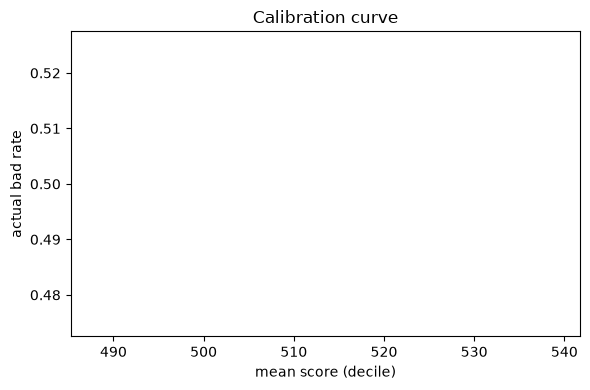

,decile,n,mean_score,bad_rate
0,"(511.26000000000005, 515.724]",20,513.492524,0.5


In [64]:
def plot_calibration_curve(scores_df, target, n_deciles=10):
	work = scores_df[[target, "score"]].dropna().copy()
	work["decile"] = pd.qcut(work["score"], n_deciles, duplicates="drop")
	cal = work.groupby("decile", observed=False).agg(
		n=("score", "count"),
		mean_score=("score", "mean"),
		bad_rate=(target, "mean"),
	).reset_index()
	fig, ax = plt.subplots(figsize=(6, 4))
	ax.plot(cal["mean_score"], cal["bad_rate"])
	ax.set_xlabel("mean score (decile)")
	ax.set_ylabel("actual bad rate")
	ax.set_title("Calibration curve")
	plt.tight_layout()
	plt.show()
	return cal

# --- checkpoint: plot_calibration_curve (synthetic) ---
try:
	_scores_for_plot = _cp_scored
except NameError:
	_rng = np.random.default_rng(3)
	_score = _rng.normal(600, 40, size=80)
	_p = 1 / (1 + np.exp((_score - 600) / 25))
	_scores_for_plot = pd.DataFrame({
		"score": _score,
		SCORECARD_PARAMS["target"]: (_rng.random(len(_score)) < _p).astype(int),
	})
print("checkpoint plot_calibration_curve:")
_cp_cal_table = plot_calibration_curve(_scores_for_plot, SCORECARD_PARAMS["target"], n_deciles=5)
display(_cp_cal_table.head())


,feature,bin,woe,points
0,act_age_WOE,42.0 <= act_age < 62.0,-0.038543,-1.612085
1,act_age_WOE,62.0 <= act_age,0.265540,11.106265
2,act_age_WOE,act_age < 42.0,-0.793255,-33.178009
3,act_cins_cc_WOE,0.5 <= act_cins_cc,-2.317135,-75.196109
4,act_cins_cc_WOE,Missing,0.203047,6.589318
5,act_cins_cc_WOE,act_cins_cc < 0.5,-1.796816,-58.310624
6,act_cins_n_statB_WOE,Missing,0.125840,2.217129
7,act_cins_n_statB_WOE,act_cins_n_statB (all),-0.938916,-16.542435
8,app_char_job_code_WOE,Contract,-1.595527,-51.051037
9,app_char_job_code_WOE,Owner company,-0.246062,-7.873076


,feature,min_points,max_points,range,importance_pct
1,act_cins_cc_WOE,-75.196109,6.589318,81.785427,0.269402
3,app_char_job_code_WOE,-51.051037,11.506311,62.557348,0.206064
0,act_age_WOE,-33.178009,11.106265,44.284274,0.145873
4,app_char_marital_status_WOE,-36.913434,6.023141,42.936575,0.141433
5,app_number_of_children_WOE,-10.105495,27.726513,37.832008,0.124619
2,act_cins_n_statB_WOE,-16.542435,2.217129,18.759564,0.061794
6,app_spendings_WOE,-11.376991,4.049439,15.426430,0.050815


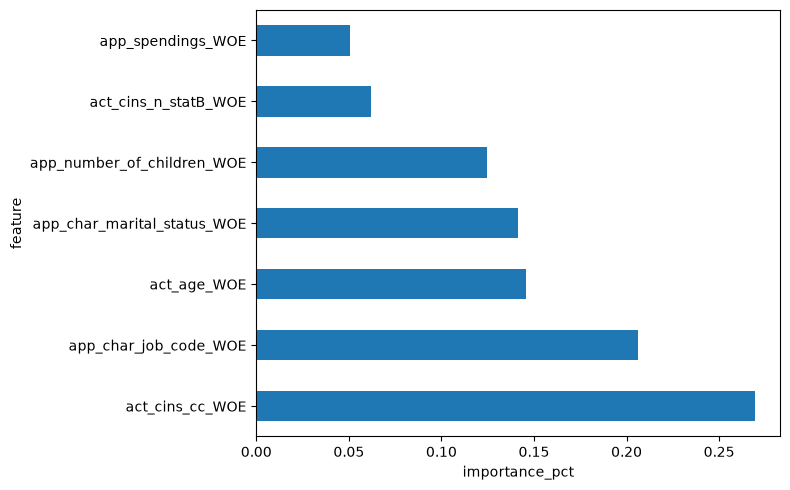

calibration params: {'intercept': 23.25022106845082, 'coef': -0.04738868244582047, 'target': 'default12', 'score_col': 'score'}


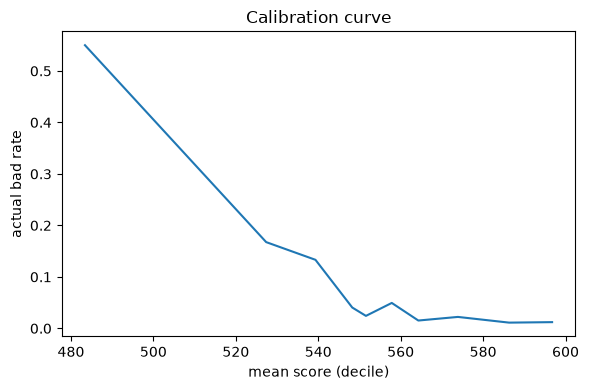

,decile,n,mean_score,bad_rate
0,"(392.01500000000004, 514.468]",360,483.398927,0.550000
1,"(514.468, 536.043]",394,527.366074,0.167513
2,"(536.043, 543.444]",353,539.320413,0.133144
3,"(543.444, 550.004]",346,548.249569,0.040462
4,"(550.004, 552.712]",330,551.565366,0.024242
5,"(552.712, 561.896]",324,557.836370,0.049383
6,"(561.896, 565.43]",460,564.281467,0.015217
7,"(565.43, 575.857]",225,573.877563,0.022222
8,"(575.857, 592.95]",359,586.301384,0.011142
9,"(592.95, 607.954]",331,596.734441,0.012085


In [65]:
if model_package is None:
    raise RuntimeError("§4 requires model_package — complete §3 first")

points_table = scale_scorecard(
    model_package, SCORECARD_PARAMS["factor"], SCORECARD_PARAMS["offset"]
)
display(points_table.head(20))

importance = variable_importance_from_points(points_table)
display(importance)
importance.plot.barh(x="feature", y="importance_pct", legend=False, figsize=(8, 5))
plt.xlabel("importance_pct")
plt.tight_layout()
plt.show()

valid_scored = score_applicants(valid_woe, model_package, points_table)
valid_scored = valid_scored.merge(
    valid_product[[SCORECARD_PARAMS["id_col"], SCORECARD_PARAMS["target"]]].rename(
        columns={SCORECARD_PARAMS["id_col"]: "aid"}
    ),
    on="aid",
)
calibration = calibrate_pd(valid_scored, target=SCORECARD_PARAMS["target"])
print("calibration params:", calibration["params"])

cal_table = plot_calibration_curve(valid_scored, SCORECARD_PARAMS["target"])
display(cal_table)


## §5 — Model stability (Gini over time)

Helper checkpoints use synthetic `_cp_*` series. The workflow cell computes `gini_time` from real `valid_scored`.


In [66]:
def gini_over_time(scored_df, target, time_col="period", score_col="score", min_n=30):
	rows = []
	for period, sub in scored_df.groupby(time_col):
		if len(sub) < min_n:
			continue
		g = compute_gini(sub[target], sub[score_col])
		rows.append({
			"period": period,
			"n": len(sub),
			"bad_rate": sub[target].mean(),
			"gini": g,
		})
	return pd.DataFrame(rows).sort_values("period")

# --- checkpoint: gini_over_time (synthetic; does not need §5 scored_with_period) ---
_rng = np.random.default_rng(1)
_cp_rows = []
for p in ["198601", "198602", "198603", "198604"]:
	n = 40
	score = _rng.normal(loc=600, scale=40, size=n)
	p_bad = 1 / (1 + np.exp((score - 600) / 25))
	y = (_rng.random(n) < p_bad).astype(int)
	_cp_rows.append(pd.DataFrame({"period": p, "score": score, SCORECARD_PARAMS["target"]: y}))
_cp_scored_time = pd.concat(_cp_rows, ignore_index=True)
_cp_gini_time = gini_over_time(
	_cp_scored_time, SCORECARD_PARAMS["target"], "period", min_n=10
)
print(f"checkpoint gini_over_time: {len(_cp_gini_time)} periods")
display(_cp_gini_time.head())


checkpoint gini_over_time: 4 periods


,period,n,bad_rate,gini
0,198601,40,0.375,0.402667
1,198602,40,0.525,0.478697
2,198603,40,0.500,0.450000
3,198604,40,0.550,0.696970


checkpoint plot_gini_over_time:


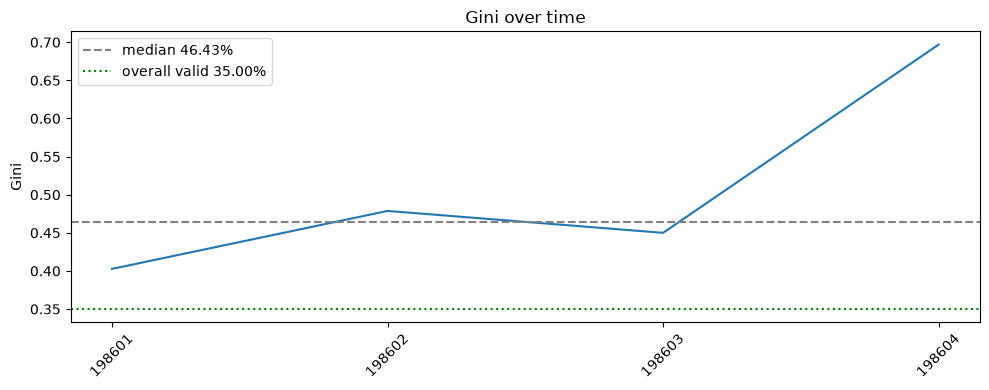

In [67]:
def plot_gini_over_time(gini_by_period, overall_gini=None):
	if gini_by_period.empty:
		return
	fig, ax = plt.subplots(figsize=(10, 4))
	ax.plot(gini_by_period["period"], gini_by_period["gini"])
	median_g = gini_by_period["gini"].median()
	ax.axhline(median_g, color="gray", linestyle="--", label=f"median {median_g:.2%}")
	if overall_gini is not None:
		ax.axhline(overall_gini, color="green", linestyle=":", label=f"overall valid {overall_gini:.2%}")
	ax.set_title("Gini over time")
	ax.set_ylabel("Gini")
	ax.tick_params(axis="x", rotation=45)
	ax.legend()
	plt.tight_layout()
	plt.show()
	flagged = gini_by_period[gini_by_period["gini"] < median_g - 0.10]
	if len(flagged):
		print("Warning: periods with Gini >10pp below median:")
		display(flagged)

# --- checkpoint: plot_gini_over_time (synthetic) ---
print("checkpoint plot_gini_over_time:")
plot_gini_over_time(_cp_gini_time, overall_gini=0.35)


,period,n,bad_rate,gini
0,198601,151,0.105960,0.688889
1,198602,129,0.077519,0.730252
2,198603,146,0.136986,0.609524
3,198604,136,0.102941,0.634660
4,198605,138,0.144928,0.739407
5,198606,141,0.085106,0.742894
6,198607,147,0.095238,0.668099
7,198608,151,0.086093,0.622631
8,198609,134,0.089552,0.704235
9,198610,144,0.111111,0.629883


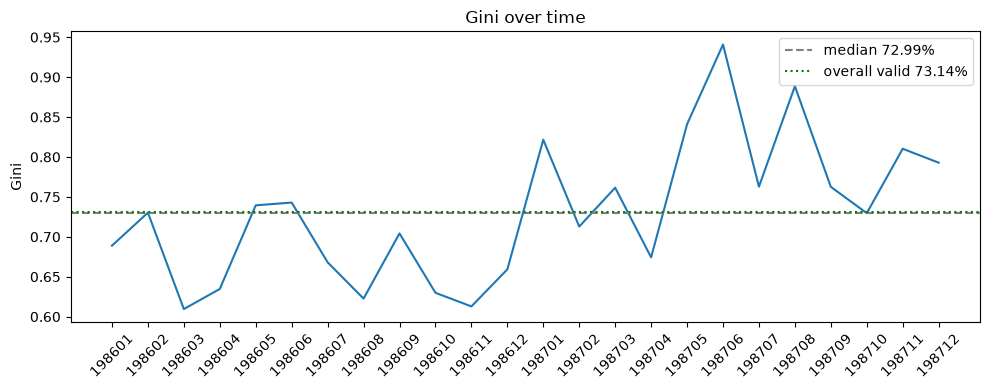

,period,n,bad_rate,gini
2,198603,146,0.136986,0.609524
7,198608,151,0.086093,0.622631
9,198610,144,0.111111,0.629883
10,198611,151,0.112583,0.612818


Gate B diagnostics: gini_train=0.603 gini_valid=0.731 min_period=0.610 slope=0.00735 max_vif=1.151 all_neg_betas=True
Gate B PASSED


In [68]:
if valid_scored is None:
    raise RuntimeError("§5 requires valid_scored — complete §4 first")

scored_with_period = valid_scored.merge(
    valid_product[[SCORECARD_PARAMS["id_col"], SCORECARD_PARAMS["time_col"]]].rename(
        columns={SCORECARD_PARAMS["id_col"]: "aid"}
    ),
    on="aid",
)
gini_time = gini_over_time(
    scored_with_period,
    SCORECARD_PARAMS["target"],
    SCORECARD_PARAMS["time_col"],
)
display(gini_time)
plot_gini_over_time(gini_time, overall_gini=model_package["metrics"]["gini_valid"])

# --- Gate B hard assert ---
_gate = SCORECARD_PARAMS["gate_b"]
_vals = gini_time["gini"].to_numpy(dtype=float)
_slope = float(np.polyfit(np.arange(len(_vals)), _vals, 1)[0]) if len(_vals) >= 2 else np.nan
_min_g = float(_vals.min()) if len(_vals) else np.nan
_ov_tr = float(model_package["metrics"]["gini_train"])
_ov_va = float(model_package["metrics"]["gini_valid"])
_max_vif = float(model_package["metrics"].get("max_vif", np.nan))
_betas = model_package["model"].params.drop(labels=["const"], errors="ignore")
_all_neg = bool((_betas < 0).all()) if len(_betas) else False

print(
    f"Gate B diagnostics: gini_train={_ov_tr:.3f} gini_valid={_ov_va:.3f} "
    f"min_period={_min_g:.3f} slope={_slope:.5f} max_vif={_max_vif:.3f} all_neg_betas={_all_neg}"
)
_fail = []
if _ov_tr < _gate["overall_gini_min"] or _ov_va < _gate["overall_gini_min"]:
    _fail.append(f"overall Gini < {_gate['overall_gini_min']}")
if _min_g < _gate["min_period_gini"]:
    _fail.append(
        f"period floor: {int((_vals < _gate['min_period_gini']).sum())} months < {_gate['min_period_gini']}"
    )
if not (_slope > _gate["period_gini_slope_min"]):
    _fail.append(f"period Gini slope {_slope} not > {_gate['period_gini_slope_min']}")
if not (np.isnan(_max_vif) or _max_vif < SCORECARD_PARAMS["selection"]["vif_max"]):
    _fail.append(f"max_vif={_max_vif} not < {SCORECARD_PARAMS['selection']['vif_max']}")
if not _all_neg:
    _fail.append("not all WOE betas negative")
if _fail:
    raise AssertionError("Gate B FAILED: " + "; ".join(_fail))
print("Gate B PASSED")


## §6 — Save artifacts

Helper checkpoints use synthetic `_cp_model_report`. The workflow cell writes product artifacts under `data/06_models`.


In [69]:
def build_model_report(model_package, points_table, gini_time, calibration, cal_table, gini_vars):
	m = model_package["metrics"]
	main = pd.DataFrame({
		"Measure": [
			"gini_train", "gini_valid", "ar_diff", "max_vif",
			"max_pvalue", "n_features", "nnegative_betas",
		],
		"Value": [
			m["gini_train"], m["gini_valid"], m["ar_diff"], m["max_vif"],
			m["max_pvalue"], m["n_features"], m["nnegative_betas"],
		],
	})
	effects = model_package.get("effects")
	if effects is None:
		feature_cols = model_package["features"]
		vif_series = check_vif(model_package["train_subset"][feature_cols])
		effects = pd.DataFrame([
			{"feature": feat, "beta": model_package["model"].params[feat],
			 "pvalue": model_package["model"].pvalues[feat],
			 "vif": vif_series.get(feat, np.nan)}
			for feat in feature_cols
		])
	importance = variable_importance_from_points(points_table)
	scorecard = points_table.copy()
	scorecard["points_round"] = scorecard["points"].round(0)
	cal_df = pd.DataFrame([calibration["params"]])
	cal_df = pd.concat([cal_df, cal_table], ignore_index=True)
	final_vars = [f[: -len("_WOE")] for f in model_package["features"]]
	gini_final = gini_vars[gini_vars["variable"].isin(final_vars)] if gini_vars is not None and len(gini_vars) else pd.DataFrame()
	return {
		"Main_measures": main,
		"Effects": effects,
		"Gini_over_time": gini_time,
		"Scorecard": scorecard,
		"Variable importance": importance,
		"Calibration": cal_df,
		"Gini_vars_final": gini_final,
	}

# --- checkpoint: build_model_report (synthetic) ---
# Prefer §4/§5 _cp_* fixtures when those helper cells already ran; otherwise build a tiny stand-in.
try:
	_pkg, _pt, _gt, _cal, _cal_tbl = (
		_cp_model_package, _cp_points_table, _cp_gini_time, _cp_cal, _cp_cal_table
	)
except NameError:
	_pt = pd.DataFrame({
		"feature": ["feat_a_WOE", "feat_a_WOE"],
		"bin": ["low", "high"],
		"woe": [-0.5, 0.5],
		"points": [10.0, -10.0],
	})
	_pt.attrs["base_points"] = 600.0
	_pkg = {
		"features": ["feat_a_WOE"],
		"metrics": {
			"gini_train": 0.4, "gini_valid": 0.35, "ar_diff": 0.05,
			"max_vif": 1.2, "max_pvalue": 0.01, "n_features": 1, "nnegative_betas": 1,
		},
		"effects": pd.DataFrame([{"feature": "feat_a_WOE", "beta": -0.2, "pvalue": 0.01, "vif": 1.1}]),
	}
	_gt = pd.DataFrame({"period": ["198601", "198602"], "n": [40, 40], "bad_rate": [0.2, 0.25], "gini": [0.3, 0.32]})
	_cal = {"params": {"intercept": 0.0, "coef": -0.01, "target": SCORECARD_PARAMS["target"], "score_col": "score"}}
	_cal_tbl = pd.DataFrame({"decile": ["q1", "q2"], "n": [10, 10], "mean_score": [580.0, 620.0], "bad_rate": [0.3, 0.1]})

_cp_gini_vars_smoke = pd.DataFrame({"variable": ["feat_a"], "gini_train": [0.4], "gini_valid": [0.35]})
_cp_model_report = build_model_report(_pkg, _pt, _gt, _cal, _cal_tbl, _cp_gini_vars_smoke)
print(f"checkpoint build_model_report: sheets={list(_cp_model_report.keys())}")


checkpoint build_model_report: sheets=['Main_measures', 'Effects', 'Gini_over_time', 'Scorecard', 'Variable importance', 'Calibration', 'Gini_vars_final']


checkpoint display_model_report:
## Main_measures


,Measure,Value
0,gini_train,0.40
1,gini_valid,0.35
2,ar_diff,0.05
3,max_vif,1.20
4,max_pvalue,0.01
5,n_features,1.00
6,nnegative_betas,1.00


## Effects


,feature,beta,pvalue,vif
0,feat_a_WOE,-0.154671,0.01,1.1


## Gini_over_time


,period,n,bad_rate,gini
0,198601,40,0.375,0.402667
1,198602,40,0.525,0.478697
2,198603,40,0.500,0.450000
3,198604,40,0.550,0.696970


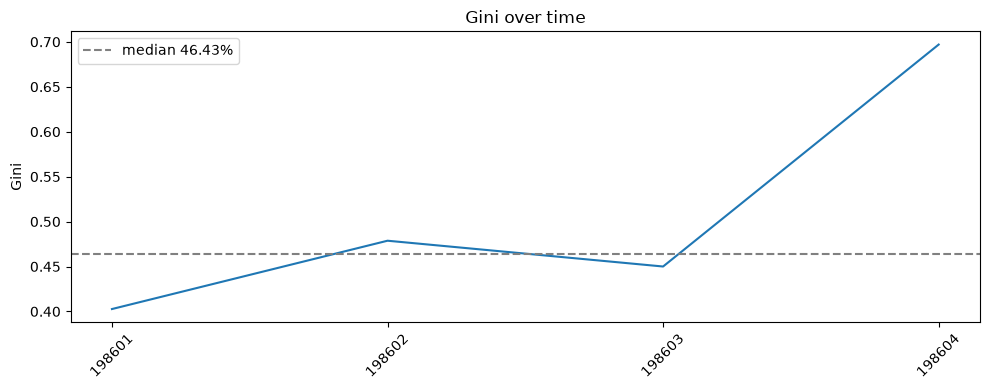

## Scorecard


,feature,bin,woe,points,points_round
0,feat_a_WOE,low,-0.5,-2.231427,-2.0
1,feat_a_WOE,high,0.5,2.231427,2.0


## Variable importance


,feature,min_points,max_points,range,importance_pct
0,feat_a_WOE,-2.231427,2.231427,4.462854,1.0


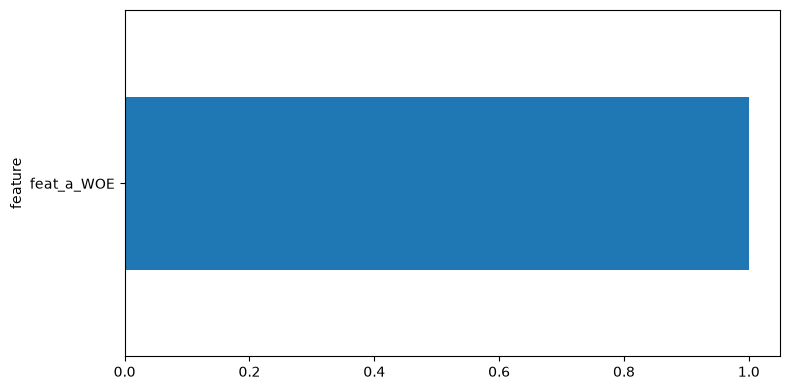

## Calibration


,intercept,coef,target,score_col,decile,n,mean_score,bad_rate
0,6552.763066,-12.761174,default12,score,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,"(511.26000000000005, 515.724]",20.0,513.492524,0.5


## Gini_vars_final


,variable,gini_train,gini_valid
0,feat_a,0.4,0.35


In [70]:
def display_model_report(model_report):
	for sheet_name, df in model_report.items():
		print(f"## {sheet_name}")
		display(df)
		if sheet_name == "Gini_over_time":
			plot_gini_over_time(df)
		elif sheet_name == "Variable importance":
			df.plot.barh(x="feature", y="importance_pct", legend=False, figsize=(8, 4))
			plt.tight_layout()
			plt.show()

# --- checkpoint: display_model_report (synthetic) ---
print("checkpoint display_model_report:")
display_model_report(_cp_model_report)


In [71]:
def save_product_artifacts(
	product, out_dir, big_scorecard, gini_vars, stability_flags, gini_time,
	model_package, points_table, screen_report, woe_maps, calibration,
	artifact_suffix=None,
):
	"""Save scorecard artifacts. Use artifact_suffix (e.g. ins_v2) to avoid clobbering v1."""
	tag = artifact_suffix or product
	out = Path(out_dir)
	out.mkdir(parents=True, exist_ok=True)
	big_scorecard.to_parquet(out / f"big_scorecard_{tag}.parquet", index=False)
	gini_vars.to_parquet(out / f"gini_vars_{tag}.parquet", index=False)
	stability_flags.to_parquet(out / f"bin_stability_flags_{tag}.parquet", index=False)
	gini_time.to_parquet(out / f"gini_by_period_{tag}.parquet", index=False)
	points_table.to_parquet(out / f"points_table_{tag}.parquet", index=False)
	screen_report.to_parquet(out / f"feature_screen_report_{tag}.parquet", index=False)
	with (out / f"pd_{tag}.pkl").open("wb") as fh:
		pickle.dump(model_package, fh)
	woe_path = out / f"woe_maps_{tag}.pkl"
	with woe_path.open("wb") as fh:
		pickle.dump({product: woe_maps}, fh)
	cal_path = out / f"calibration_params_{tag}.json"
	with cal_path.open("w", encoding="utf-8") as fh:
		json.dump({product: calibration["params"]}, fh, indent=2)


## Main_measures


,Measure,Value
0,gini_train,6.029419e-01
1,gini_valid,7.313852e-01
2,ar_diff,1.284433e-01
3,max_vif,1.151232e+00
4,max_pvalue,3.500833e-20
5,n_features,7.000000e+00
6,nnegative_betas,7.000000e+00


## Effects


,feature,beta,pvalue,vif
0,act_age_WOE,-1.449549,4.231145e-61,1.151232
5,app_number_of_children_WOE,-1.299918,3.688009e-94,1.138765
1,act_cins_cc_WOE,-1.124707,7.053713e-246,1.038608
3,app_char_job_code_WOE,-1.108909,4.453996e-177,1.053856
6,app_spendings_WOE,-0.832340,1.360356e-20,1.023384
4,app_char_marital_status_WOE,-0.824588,6.166329e-56,1.039299
2,act_cins_n_statB_WOE,-0.610616,3.500833e-20,1.052119


## Gini_over_time


,period,n,bad_rate,gini
0,198601,151,0.105960,0.688889
1,198602,129,0.077519,0.730252
2,198603,146,0.136986,0.609524
3,198604,136,0.102941,0.634660
4,198605,138,0.144928,0.739407
5,198606,141,0.085106,0.742894
6,198607,147,0.095238,0.668099
7,198608,151,0.086093,0.622631
8,198609,134,0.089552,0.704235
9,198610,144,0.111111,0.629883


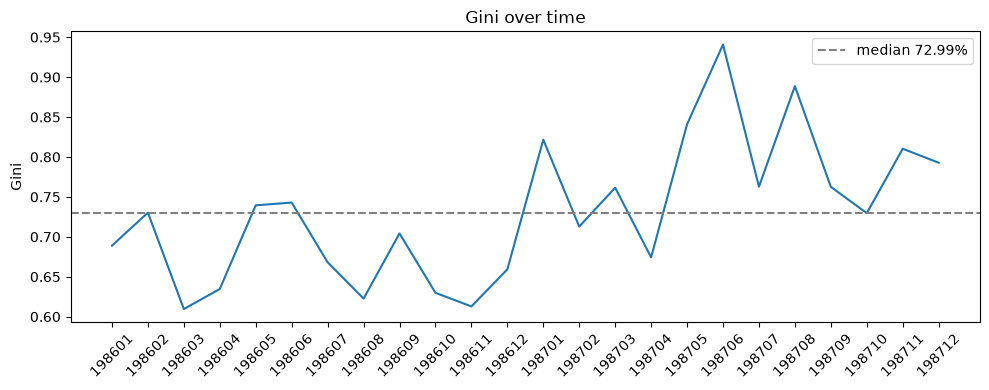

,period,n,bad_rate,gini
2,198603,146,0.136986,0.609524
7,198608,151,0.086093,0.622631
9,198610,144,0.111111,0.629883
10,198611,151,0.112583,0.612818


## Scorecard


,feature,bin,woe,points,points_round
0,act_age_WOE,42.0 <= act_age < 62.0,-0.038543,-1.612085,-2.0
1,act_age_WOE,62.0 <= act_age,0.265540,11.106265,11.0
2,act_age_WOE,act_age < 42.0,-0.793255,-33.178009,-33.0
3,act_cins_cc_WOE,0.5 <= act_cins_cc,-2.317135,-75.196109,-75.0
4,act_cins_cc_WOE,Missing,0.203047,6.589318,7.0
5,act_cins_cc_WOE,act_cins_cc < 0.5,-1.796816,-58.310624,-58.0
6,act_cins_n_statB_WOE,Missing,0.125840,2.217129,2.0
7,act_cins_n_statB_WOE,act_cins_n_statB (all),-0.938916,-16.542435,-17.0
8,app_char_job_code_WOE,Contract,-1.595527,-51.051037,-51.0
9,app_char_job_code_WOE,Owner company,-0.246062,-7.873076,-8.0


## Variable importance


,feature,min_points,max_points,range,importance_pct
1,act_cins_cc_WOE,-75.196109,6.589318,81.785427,0.269402
3,app_char_job_code_WOE,-51.051037,11.506311,62.557348,0.206064
0,act_age_WOE,-33.178009,11.106265,44.284274,0.145873
4,app_char_marital_status_WOE,-36.913434,6.023141,42.936575,0.141433
5,app_number_of_children_WOE,-10.105495,27.726513,37.832008,0.124619
2,act_cins_n_statB_WOE,-16.542435,2.217129,18.759564,0.061794
6,app_spendings_WOE,-11.376991,4.049439,15.426430,0.050815


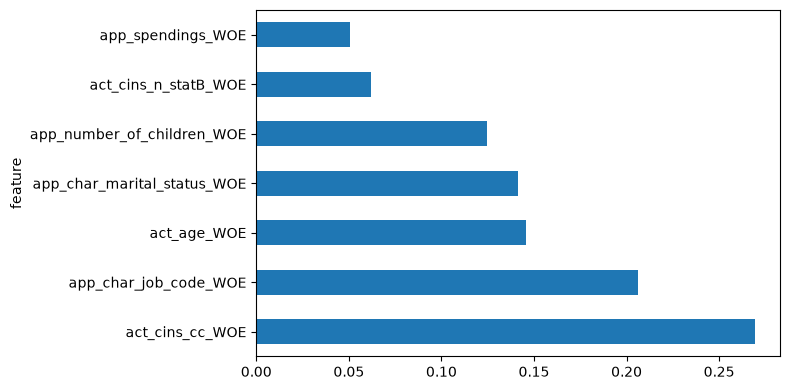

## Calibration


,intercept,coef,target,score_col,decile,n,mean_score,bad_rate
0,23.250221,-0.047389,default12,score,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,"(392.01500000000004, 514.468]",360.0,483.398927,0.550000
2,NaN,NaN,NaN,NaN,"(514.468, 536.043]",394.0,527.366074,0.167513
3,NaN,NaN,NaN,NaN,"(536.043, 543.444]",353.0,539.320413,0.133144
4,NaN,NaN,NaN,NaN,"(543.444, 550.004]",346.0,548.249569,0.040462
5,NaN,NaN,NaN,NaN,"(550.004, 552.712]",330.0,551.565366,0.024242
6,NaN,NaN,NaN,NaN,"(552.712, 561.896]",324.0,557.836370,0.049383
7,NaN,NaN,NaN,NaN,"(561.896, 565.43]",460.0,564.281467,0.015217
8,NaN,NaN,NaN,NaN,"(565.43, 575.857]",225.0,573.877563,0.022222
9,NaN,NaN,NaN,NaN,"(575.857, 592.95]",359.0,586.301384,0.011142


## Gini_vars_final


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique
3,app_char_job_code,0.234986,0.287974,0.225493,0.334795,0.000882,0.019960,0.000000,4
6,app_number_of_children,0.194255,0.206134,0.061147,0.195935,0.000026,0.002969,0.000000,4
8,act_cins_cc,0.179812,0.219259,0.219379,0.420244,0.012189,0.007798,0.949318,924
9,app_char_marital_status,0.179805,0.206582,0.148924,0.179825,0.000480,0.006373,0.000000,4
24,act_age,0.125394,0.119292,0.048662,0.077494,0.009369,0.035568,0.000000,71
25,app_spendings,0.119154,0.175060,0.469193,0.067299,0.000042,0.009061,0.000000,269
27,act_cins_n_statB,0.109899,0.081008,0.262884,0.117016,0.000182,0.002248,0.913655,18


PD ins (ins_v2): 7 features, valid Gini 73.1%
Saved parquet/pkl/json for ins_v2


In [72]:
if model_package is None:
    raise RuntimeError("§6 requires model_package — complete §3–§5 first")

# Prefer package copy if local screen_report was not rebuilt this session.
_screen = screen_report if isinstance(screen_report, pd.DataFrame) and not screen_report.empty else model_package.get("screen_report")
if _screen is None or (isinstance(_screen, pd.DataFrame) and _screen.empty):
    _screen = pd.DataFrame({"feature": model_package["features"], "status": "keep"})

model_report = build_model_report(
    model_package, points_table, gini_time, calibration, cal_table, gini_vars
)
display_model_report(model_report)

# Persist decision log beside core artifacts (v2 names)
_decision_log = {
    "product": PRODUCT,
    "artifact_suffix": ARTIFACT_SUFFIX,
    "git_sha": GIT_SHA,
    "random_seed": RANDOM_SEED,
    "scorecard_params": {
        k: SCORECARD_PARAMS[k]
        for k in ("binning", "prescreen", "stability", "selection", "gate_b")
        if k in SCORECARD_PARAMS
    },
    "manual_bin_edits": manual_bin_edits,
    "manual_variable_decisions": manual_variable_decisions,
    "manual_override": list(MANUAL_OVERRIDE),
    "selected_features": list(model_package["features"]),
    "metrics": model_package.get("metrics"),
}
_out = Path("../data/06_models")
_out.mkdir(parents=True, exist_ok=True)
with (_out / f"decision_log_{ARTIFACT_SUFFIX}.json").open("w", encoding="utf-8") as fh:
    json.dump(_decision_log, fh, indent=2, default=str)

save_product_artifacts(
    PRODUCT,
    "../data/06_models",
    big_scorecard,
    gini_vars,
    stability_flags,
    gini_time,
    model_package,
    points_table,
    _screen,
    woe_maps,
    calibration,
    artifact_suffix=ARTIFACT_SUFFIX,
)

gini_valid = model_package["metrics"]["gini_valid"]
print(f"PD {PRODUCT} ({ARTIFACT_SUFFIX}): {len(model_package['features'])} features, valid Gini {gini_valid:.1%}")
print("Saved parquet/pkl/json for", ARTIFACT_SUFFIX)


Final model report (reprint):
## Main_measures


,Measure,Value
0,gini_train,6.029419e-01
1,gini_valid,7.313852e-01
2,ar_diff,1.284433e-01
3,max_vif,1.151232e+00
4,max_pvalue,3.500833e-20
5,n_features,7.000000e+00
6,nnegative_betas,7.000000e+00


## Effects


,feature,beta,pvalue,vif
0,act_age_WOE,-1.449549,4.231145e-61,1.151232
5,app_number_of_children_WOE,-1.299918,3.688009e-94,1.138765
1,act_cins_cc_WOE,-1.124707,7.053713e-246,1.038608
3,app_char_job_code_WOE,-1.108909,4.453996e-177,1.053856
6,app_spendings_WOE,-0.832340,1.360356e-20,1.023384
4,app_char_marital_status_WOE,-0.824588,6.166329e-56,1.039299
2,act_cins_n_statB_WOE,-0.610616,3.500833e-20,1.052119


## Gini_over_time


,period,n,bad_rate,gini
0,198601,151,0.105960,0.688889
1,198602,129,0.077519,0.730252
2,198603,146,0.136986,0.609524
3,198604,136,0.102941,0.634660
4,198605,138,0.144928,0.739407
5,198606,141,0.085106,0.742894
6,198607,147,0.095238,0.668099
7,198608,151,0.086093,0.622631
8,198609,134,0.089552,0.704235
9,198610,144,0.111111,0.629883


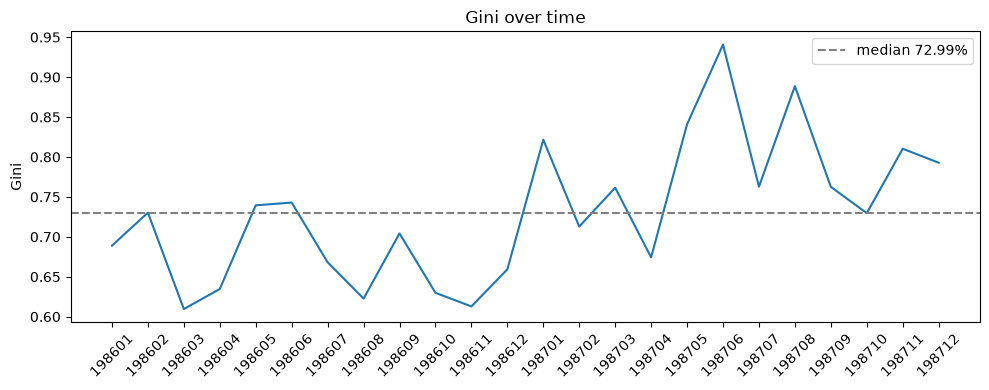

,period,n,bad_rate,gini
2,198603,146,0.136986,0.609524
7,198608,151,0.086093,0.622631
9,198610,144,0.111111,0.629883
10,198611,151,0.112583,0.612818


## Scorecard


,feature,bin,woe,points,points_round
0,act_age_WOE,42.0 <= act_age < 62.0,-0.038543,-1.612085,-2.0
1,act_age_WOE,62.0 <= act_age,0.265540,11.106265,11.0
2,act_age_WOE,act_age < 42.0,-0.793255,-33.178009,-33.0
3,act_cins_cc_WOE,0.5 <= act_cins_cc,-2.317135,-75.196109,-75.0
4,act_cins_cc_WOE,Missing,0.203047,6.589318,7.0
5,act_cins_cc_WOE,act_cins_cc < 0.5,-1.796816,-58.310624,-58.0
6,act_cins_n_statB_WOE,Missing,0.125840,2.217129,2.0
7,act_cins_n_statB_WOE,act_cins_n_statB (all),-0.938916,-16.542435,-17.0
8,app_char_job_code_WOE,Contract,-1.595527,-51.051037,-51.0
9,app_char_job_code_WOE,Owner company,-0.246062,-7.873076,-8.0


## Variable importance


,feature,min_points,max_points,range,importance_pct
1,act_cins_cc_WOE,-75.196109,6.589318,81.785427,0.269402
3,app_char_job_code_WOE,-51.051037,11.506311,62.557348,0.206064
0,act_age_WOE,-33.178009,11.106265,44.284274,0.145873
4,app_char_marital_status_WOE,-36.913434,6.023141,42.936575,0.141433
5,app_number_of_children_WOE,-10.105495,27.726513,37.832008,0.124619
2,act_cins_n_statB_WOE,-16.542435,2.217129,18.759564,0.061794
6,app_spendings_WOE,-11.376991,4.049439,15.426430,0.050815


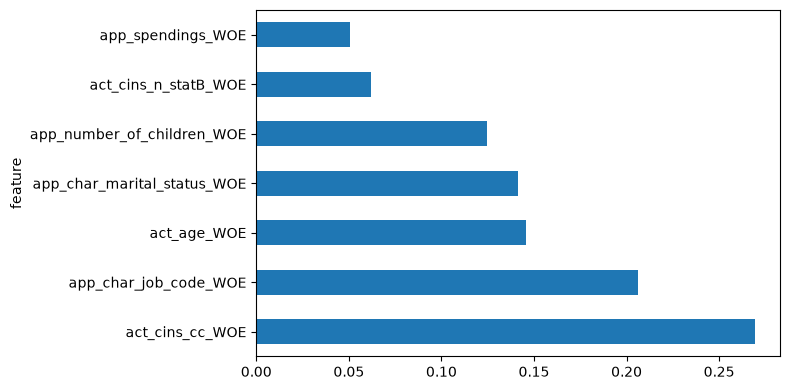

## Calibration


,intercept,coef,target,score_col,decile,n,mean_score,bad_rate
0,23.250221,-0.047389,default12,score,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,"(392.01500000000004, 514.468]",360.0,483.398927,0.550000
2,NaN,NaN,NaN,NaN,"(514.468, 536.043]",394.0,527.366074,0.167513
3,NaN,NaN,NaN,NaN,"(536.043, 543.444]",353.0,539.320413,0.133144
4,NaN,NaN,NaN,NaN,"(543.444, 550.004]",346.0,548.249569,0.040462
5,NaN,NaN,NaN,NaN,"(550.004, 552.712]",330.0,551.565366,0.024242
6,NaN,NaN,NaN,NaN,"(552.712, 561.896]",324.0,557.836370,0.049383
7,NaN,NaN,NaN,NaN,"(561.896, 565.43]",460.0,564.281467,0.015217
8,NaN,NaN,NaN,NaN,"(565.43, 575.857]",225.0,573.877563,0.022222
9,NaN,NaN,NaN,NaN,"(575.857, 592.95]",359.0,586.301384,0.011142


## Gini_vars_final


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique
3,app_char_job_code,0.234986,0.287974,0.225493,0.334795,0.000882,0.019960,0.000000,4
6,app_number_of_children,0.194255,0.206134,0.061147,0.195935,0.000026,0.002969,0.000000,4
8,act_cins_cc,0.179812,0.219259,0.219379,0.420244,0.012189,0.007798,0.949318,924
9,app_char_marital_status,0.179805,0.206582,0.148924,0.179825,0.000480,0.006373,0.000000,4
24,act_age,0.125394,0.119292,0.048662,0.077494,0.009369,0.035568,0.000000,71
25,app_spendings,0.119154,0.175060,0.469193,0.067299,0.000042,0.009061,0.000000,269
27,act_cins_n_statB,0.109899,0.081008,0.262884,0.117016,0.000182,0.002248,0.913655,18


In [73]:
# §6b — Final report reprint
if model_report is None:
    raise RuntimeError("model_report not available — run §6 save cell first")
print("Final model report (reprint):")
display_model_report(model_report)


### Optional: automated Kedro / library regression

Uses `credit_scoring.scorecard.orchestration.run_full_scorecard_pipeline` (forward selection), not this notebook's RFE/`Model_list` path. Suitable after binning policy is stable.


In [74]:
# Optional: automated library regression (forward_select_logit path — not RFE).
# from credit_scoring.scorecard.orchestration import run_full_scorecard_pipeline
# results = run_full_scorecard_pipeline(
#     "../data/04_feature/abt_app.parquet",
#     "../data/04_feature/decisions.parquet",
#     SCORECARD_PARAMS,
#     output_dir="../data/06_models",
# )
